In [2]:
import numpy as np
# pandas is a fast and simple library for data manipulation
# it supports spreadsheet-like data structures, so we can read/write/manipulate csv or excel files easily
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
# use curve_fit for Rosenbluth linear fit
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
# import subprocess
# python version: /usr/local/bin/python3
# optional: use science paper style for plots
# from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import ScalarFormatter



import scienceplots
# plt.style.use('science')
plt.style.use(['science','nature'])


# from PIL import Image
# from reportlab.pdfgen import canvas
# plt.rcParams['font.weight'] = 'bold'  # Applies to all text elements
# plt.rcParams['axes.titleweight'] = 'bold'  # Bold titles
# plt.rcParams['axes.labelweight'] = 'bold'  # Bold axis labels
# plt.rcParams['legend.fontsize'] = 12  # Adjust legend font size
# plt.rcParams['legend.fontweight'] = 'bold'  # Bold legend text
# plt.rcParams['xtick.labelsize'] = 12  # Adjust x-tick labels font size
# plt.rcParams['ytick.labelsize'] = 12  # Adjust y-tick labels font size

# calculate bin-centering correction using Fortran program
import subprocess
import os



In [3]:
#____________________presets____________________
# physical constants
mass_nucleon = 0.938273
mass_C12=11.178
alpha_fine = 1/137.036

# three-momentum bin centers
qvcenters = [0.100, 0.148, 0.167, 0.205, 0.240, 0.300, 0.380, 0.475, 0.570, 0.649, 0.756, 0.991, 1.619, 1.921, 2.213, 2.500, 2.783, 3.500]
# three-momentum edges
qvbins = [0.063, 0.124, 0.158, 0.186, 0.223, 0.270, 0.340, 0.428, 0.523, 0.609, 0.702, 0.878, 1.302, 1.770, 2.067, 2.357, 2.642, 2.923, 4.500]
# four-momentum squared bin names, in string format
qvbin_names = ['[0.063,0.124]', '[0.124,0.158]', '[0.158,0.186]', '[0.186,0.223]', '[0.223,0.270]', '[0.270,0.340]', '[0.340,0.428]', '[0.428,0.523]', '[0.523,0.609]',
                '[0.609,0.702]', '[0.702,0.878]', '[0.878,1.302]', '[1.302,1.770]', '[1.770,2.067]', '[2.067,2.357]', '[2.357,2.642]', '[2.642,2.923]', '[2.923,4.500]']

# four-momentum squared bin centers
Q2centers = [0.010, 0.020, 0.026, 0.040, 0.056, 0.093, 0.120, 0.160, 0.265, 0.380, 0.500, 0.800, 1.250, 1.750, 2.250, 2.750, 3.250, 3.750]
# four-momentum squared bin edges
Q2bins = [0.004, 0.015, 0.025, 0.035, 0.045, 0.070, 0.100, 0.145, 0.206, 0.322, 0.438, 0.650, 1.050, 1.500, 2.000, 2.500, 3.000, 3.500, 4.000]
# four-momentum squared bin names, in string format
Q2bin_names = ['[0.004,0.015]', '[0.015,0.025]', '[0.025,0.035]', '[0.035,0.045]', '[0.045,0.070]', '[0.070,0.100]', '[0.100,0.145]', '[0.145,0.206]', '[0.206,0.322]',
                '[0.322,0.438]', '[0.438,0.650]', '[0.650,1.050]', '[1.050,1.500]', '[1.500,2.000]', '[2.000,2.500]', '[2.500,3.000]', '[3.000,3.500]', '[3.500,4.000]']

# Feb24 2025: map from data set index to data set name (author, year, etc.)
dataSet_to_name = {1:"Barreau:1983ht", 2:"O'Connell:1987", 3:"Sealock:1989nx", 4:"Baran:1988tw", 5:"Bagdasaryan:1988hp", 6:"Dai-HallA:2019da", 
    7:"Arrington:1995hs", 8:"Day:1993md", 9:"Arrington:1998psnoCC", 10:"Gaskell:2008", 11:"Whitney:1974hr", 
    # 12:"AlsamiJan05",
    12:"Alsalmi:2025",
    13:"Vahe:2012", 
    14:"Gomez:1974", 15:"Fomin:2010", 16:"Yamaguchi:1973", 17:"Ryan:1984", 18:"Cyzyk:1963zz", 19:"Bounin:1963", 20:"Photo-Daphne", 
    # 21:"Spamer70", 
    21:"Antony-Spies:1970jjs",22:"Goldemberg:1964", 23:"DeForrest:1965", 24:"Mihovilovic:2024ymj", 25:"CLAS-e4nu:2023",26:"GarinoBates:1992",
    -1:"N/A",
    27:"Ricco:1968", # 25Aug5 added Ricco data to plot
    28:"Zeller:QE-Archive-prelim" # 25Aug7 added Zeller data to plot
    }

# # march 31 from Eric:
# dataSet_to_normalization = {
#     1: 0.95971, 
#     # 1:0.9919, # old barreau
#     2: 0.96416, 3: 1.0744, 4: 0.99482, 5: 0.93381,
#     6: 1.0126, 7: 0.96716, 8: 1.0238, 9: 0.97904, 10: 0.99064,
#     11: 0.98384, 12: 1.0000, 13: 1.0163, 14: 1.0300, 15: 1.0190,
#     16: 0.95853, 17: 1.0174, 18: 1.0168, 19: 1.0794, 20: 1.0000,
#     21: 1.0019, 22: 0.99801, 23: 0.96773, 24: 0.95610,
#     25:0.85, 26:0.94
# }

# dataSet_to_normError = {
#     1: 0.62926E-02, 
#     # 1: 0.0024, # old barreau error
#     2: 0.12908E-01, 3: 0.80983E-02, 4: 0.69809E-02, 5: 0.16758E-01,
#     6: 0.92261E-02, 7: 0.15546E-01, 8: 0.65203E-02, 9: 0.55606E-02, 10: 0.75245E-02,
#     11: 0.25318E-01, 12: 0.0, 13: 0.17632E-02, 14: 0.91993E-02, 15: 0.63181E-02,
#     16: 0.25582E-01, 17: 0.42184E-01, 18: 0.68067E-01, 19: 0.35847E-01, 20: 0.0,
#     21: 0.18356E-01, 22: 0.41475E-01, 23: 0.17317E-01, 24: 0.23120E-01,
#     25:0.02,26:0.02
# }

# old normalization (arXiv)
dataSet_to_normalization = dict(zip(
    # np.arange(1,27,1),
    np.arange(1,29,1),
    [
    # 0.95971, # 3/31 barreau
    0.9919, # old barreau
    0.9787,1.06,0.9924,0.9878,
    1.0108,0.9743,1.0071,0.9888,0.9934,
    1.0149,0.9981,1.0029,1.0125,1.0046,
    1.0019,1.10,1.000,1.150,1.0,
    0.95,1.100,0.9,1.03,0.85,
    0.94,
    1.0, # Ricco
    1.0 # Zeller
    ])
)

dataSet_to_normError = dict(zip(
    # np.arange(1,27,1),
    np.arange(1,29,1),
    [
    # 0.62926E-02, # 3/31 Barreau error
    0.0024, # old barreau error
    0.0086,0.1000,0.0046,0.0083,
    0.0053,0.0133,0.0033,0.0034,0.0051,
    0.0153,0.0067,0.0070,0.0149,0.0031,
    0.0029,0.0130,0.2000,0.2300,0.0,
    0.25,0.1000,0.1000,0.02,0.02,
    0.02,
    0.0, # Ricco
    0.0 # Zeller
    ])
)

# # 2025 July 28
# dataSet_to_normalization = dict(zip(np.arange(1,27,1),    
#     [0.96379,0.96480,1.0759,0.99292,0.93501,
#     1.0135,0.96432,1.0267,0.97631,0.99067,
#     0.99531,1.0000,1.0157,1.0350,1.0215,
#     0.93741,0.98344,1.0236,1.0990,1.0000,
#     1.0107,0.99652,0.99708,1.0376,0.85,
#     0.94])
# )

# dataSet_to_normError = dict(zip(np.arange(1,27,1),
#     [0.60958E-02,0.12764E-01,0.81742E-02,0.68734E-02,0.16789E-01,
#     0.93682E-02,0.15650E-01,0.65467E-02,0.54454E-02,0.74127E-02,
#     0.25405E-01,0.000000000,0.17439E-02,0.93925E-02,0.62054E-02,
#     0.21335E-01,0.37920E-01,0.57897E-01,0.33084E-01,0.000000000,
#     0.18675E-01,0.41121E-01,0.18153E-01,0.24406E-01,0.02,
#     0.02])
# )


# ____________________utility functions____________________

# round to only 3 significant figures (for printing)
def round_sig_3(x):
    return '%s' % float('%.3g' % x)

# append a row to a dataframe
def append_row(df, row):
    return pd.concat([df, pd.DataFrame([row], columns=row.index)]).reset_index(drop=True)

# linear model for Rosenbluth fitting
def linear_model(x, a, b):
    return a * x + b

def Vcoul(A=12,Z=6):
    HBARC  = 0.197327      # in GeV.fm
    ALPHA  = 1.0/137.0
    C_ASTE = 0.775
    R0     = 1.1*A**(1./3.) + 0.86*A**(-1./3.)

    # Coulomb potential at the center of the nucleus
    V0  = (3./2.)*ALPHA*HBARC*(Z-1.)/R0  # in GeV

    # Average potential
    # V  = C_ASTE*V0      # from Eur. Phys. J. A26 (2005) 167

    # use experimentally determined value:
    V = 0.0031
    return V

def quasi_deuteron(ex): # ex in GeV; return GD cross-section: GeV^-2
    ex = ex * 1e3
    def pauli_blocking(ex): # ex in MeV
        if ex <=20:
            return np.exp(-73.3/ex)
        elif 20 < ex <=140: 
            return 8.3714e-2 - 9.8343e-3 * ex + 4.1222e-4 * ex**2 - 3.4762e-6 * ex**3 + 9.3537e-9 * ex**4
        else:
            return np.exp(-24.2/ex)
    N=6
    A=12
    Z=6
    if ex <2.224:
        return 0
    else:    
        sigma = 397.8*(N*Z/A)*((ex-2.224)**(3/2))*(ex**-3)*pauli_blocking(ex) # in mb
        return sigma * 0.1 * 0.1975**-2 # in GeV^-2

def dipole_E(Q2): # Q2 in GeV^2; return dipole form unitless
    # return 1/((1+Q2/0.71)**2)
    return 1/((1+Q2/0.5)**5) # new value 2025 July 18

def QD_suppression(nu,center=0.12,width=0.005): # nu in GeV
    # return 1/(np.exp((nu-center)/width)+1)
    return 1.5/(np.exp((nu-center)/width)+1) # added 25 Sep 23

def RT_quasi_deuteron(nus=[],q2s=[],exs=[]): # RT in MeV^-1, ex in GeV
    # use quasi deuteron RT
    QDs=[]            
    # for ex in ChristyBodekFit['ex']*1e3: # ex in MeV
    for ex in exs: # ex in MeV
        QDs.append(quasi_deuteron(ex))
    QDs = np.array(QDs)
    # GEs = dipole_E(ChristyBodekFit['q2'])
    GEs = dipole_E(q2s)
    GEs = np.array(GEs)
    # ChristyBodekFit['RTQD']=GEs**2 * QDs * ChristyBodekFit['nu']/(2*(np.pi**2)*alpha_fine)
    RTQD = GEs**2 * QDs * nus/(2*(np.pi**2)*alpha_fine)
    RTQD = RTQD * QD_suppression(nu=nus)
    return RTQD*1e-3 # in MeV-1

# # interpolate y1(x1) onto x2, then return ratio r = y2 / y1'(x2)
# def ratio_interpolated(x1, y1, x2, y2, eps=0.0):
#     """
#     Compute r = y2 / y1' on the shared x-range, returning (r, x_grid).
#     x_grid is taken from x2 values that lie inside the overlap.

#     Parameters
#     ----------
#     x1, y1 : array-like
#         Reference curve (same length). Can be unsorted; NaNs are ignored.
#     x2, y2 : array-like
#         Target curve (same length). Can be unsorted; NaNs are ignored.
#     eps : float
#         Small stabilizer added to denominator to avoid divide-by-zero in bins where y1' ~ 0.

#     Returns
#     -------
#     r : np.ndarray
#         Ratio evaluated at x_grid (same shape as x_grid).
#     x_grid : np.ndarray
#         The x2 points within the shared range (monotonic increasing).

#     Raises
#     ------
#     ValueError
#         If the two x-ranges do not overlap.
#     """
#     # to arrays & drop non-finite pairs
#     x1, y1 = map(np.asarray, (x1, y1))
#     x2, y2 = map(np.asarray, (x2, y2))
#     m1 = np.isfinite(x1) & np.isfinite(y1)
#     m2 = np.isfinite(x2) & np.isfinite(y2)
#     x1, y1 = x1[m1], y1[m1]
#     x2, y2 = x2[m2], y2[m2]

#     if x1.size == 0 or x2.size == 0:
#         raise ValueError("Empty x1/x2 after filtering non-finite values.")

#     # sort x1 for interpolation
#     o1 = np.argsort(x1)
#     x1s, y1s = x1[o1], y1[o1]

#     # shared range
#     lo = max(np.min(x1s), np.min(x2))
#     hi = min(np.max(x1s), np.max(x2))
#     if not (lo < hi):
#         raise ValueError("No overlapping x-range between (x1) and (x2).")

#     # choose x-grid from x2 within overlap (sorted)
#     mask_overlap = (x2 >= lo) & (x2 <= hi)
#     x_grid = np.sort(x2[mask_overlap])
#     y2_grid = y2[mask_overlap][np.argsort(x2[mask_overlap])]

#     if x_grid.size == 0:
#         raise ValueError("No x2 points fall inside the overlapping range.")

#     # interpolate y1 -> x_grid (linear; NaN outside prevented by overlap mask)
#     y1_prime = np.interp(x_grid, x1s, y1s)

#     # safe ratio
#     denom = y1_prime + eps
#     r = np.divide(y2_grid, denom, out=np.full_like(y2_grid, np.nan, dtype=float),
#                   where=np.isfinite(denom) & (denom != 0))

#     return r, x_grid



def ratio_interpolated(x1, y1, x2, y2, eps=0.0, shrink=0.98):
    """
    Compute r = y2 / y1' on a shrunken shared x-range. The evaluation grid is taken
    from x2 values inside the shrunken overlap.

    Parameters
    ----------
    x1, y1 : array-like
    x2, y2 : array-like
    eps : float
        Small stabilizer added to denominator.
    shrink : float in (0,1]
        Fraction of the true overlap length to keep (centered). For example,
        0.98 keeps 98% of the overlap, trimming ~1% off each end.

    Returns
    -------
    r : np.ndarray
        Ratio y2 / interp(y1 at x_grid).
    x_grid : np.ndarray
        Monotonic array of x2 points inside the shrunken overlap.

    Raises
    ------
    ValueError if there is no overlap or no x2 points inside the shrunken range.
    """
    # to arrays & drop non-finite pairs
    x1, y1 = map(np.asarray, (x1, y1))
    x2, y2 = map(np.asarray, (x2, y2))
    m1 = np.isfinite(x1) & np.isfinite(y1)
    m2 = np.isfinite(x2) & np.isfinite(y2)
    x1, y1 = x1[m1], y1[m1]
    x2, y2 = x2[m2], y2[m2]

    if x1.size == 0 or x2.size == 0:
        raise ValueError("Empty x1/x2 after filtering non-finite values.")
    if not (0 < shrink <= 1):
        raise ValueError("shrink must be in (0, 1].")

    # sort x1 for interpolation
    o1 = np.argsort(x1)
    x1s, y1s = x1[o1], y1[o1]

    # true overlap
    lo = max(np.min(x1s), np.min(x2))
    hi = min(np.max(x1s), np.max(x2))
    if not (lo < hi):
        raise ValueError("No overlapping x-range between x1 and x2.")

    # shrink overlap symmetrically about its midpoint
    if shrink < 1.0:
        mid = 0.5 * (lo + hi)
        half = 0.5 * (hi - lo) * shrink
        lo_s, hi_s = mid - half, mid + half
    else:
        lo_s, hi_s = lo, hi

    if not (lo_s < hi_s):
        raise ValueError("Shrunken overlap collapsed; try a larger 'shrink'.")

    # choose x-grid from x2 within shrunken overlap (sorted)
    mask = (x2 >= lo_s) & (x2 <= hi_s)
    if not np.any(mask):
        raise ValueError("No x2 points inside the shrunken overlap.")
    order2 = np.argsort(x2[mask])
    x_grid = x2[mask][order2]
    y2_grid = y2[mask][order2]

    # interpolate y1 -> x_grid (linear)
    y1_prime = np.interp(x_grid, x1s, y1s)

    # safe ratio
    denom = y1_prime + eps
    r = np.divide(y2_grid, denom,
                  out=np.full_like(y2_grid, np.nan, dtype=float),
                  where=np.isfinite(denom) & (denom != 0))

    return r, x_grid



In [4]:
# ____________________RLRT extraction, plotting functions____________________
errorbar_setting = {'markersize':0,'capsize':0,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
our_scatter_setting = {'s':10,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':4,'alpha':1}
scatter_setting = {'s':10,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':3,'alpha':1}
photo_scatter_setting = {'s':30,'color':'lime','marker':'^','edgecolors':'black','linewidth':0.5,'zorder':1}
yam_scatter = {'s':4,'marker':'o','edgecolors':'gray','linewidth':0.3,'zorder':3}
baran_scatter_setting = {'s':20,'edgecolors':'gray','linewidth':0.5,'zorder':3,'alpha':1}
Ex_cut=0.03
Ex_cut_lowq=0.1
# susacolor='royalblue'
susacolor='violet'
SuSAExtractColor='lawngreen'
susalw=2
edrmflw=2
# Jordan / our ratio (averaged) correction factors:
# RL            RT    
# 1.057492675				0.918104837
# (valid for q < 1 GeV, Q2 < 0.8 GeV^2)
RL_correction = 1.03
RT_correction = 0.96

def prepare_df(df_data=None,coulomb=None):
    df = df_data.copy()
    # read the csv file:
    # if filepath is not None:
    #     df = pd.read_csv(filepath)
    #     # Z,A,E0,ThetaDeg,nu,cross,error,dataSet
    #     df = df[['Z','A','E0','ThetaDeg','nu','cross','error','dataSet']]
    # elif df_data is not None:
    #     df = df_data.copy()
    # else:
    #     return None

    if 'error' not in df.columns:
        df['error']=0.0

    # calculate normalized cross section:
    if 'dataSet' not in df.columns:
        df['dataSet']=-1
        df['normalization']=1
        df['normError']=0
    else:
        df["normalization"]=df["dataSet"].map(dataSet_to_normalization)
        df["normError"]=df["dataSet"].map(dataSet_to_normError)
    df['normCross'] = df['cross'] * df['normalization']
        
    # system_err = 0.02
    system_err = 0.0

    df['error'] = np.sqrt(df['error']**2 + ((system_err*df['cross'])**2))
    df['normCrossError']=df['normCross']*np.sqrt((df['error']/df['cross'])**2+(df['normError']/df['normalization'])**2)
    df["ThetaRad"]=df["ThetaDeg"]*np.pi/180
    df["sin2(T/2)"]=(np.sin(df["ThetaRad"]/2))**2
    df["cos2(T/2)"]=(np.cos(df["ThetaRad"]/2))**2
    df["tan2(T/2)"]=(np.tan(df["ThetaRad"]/2))**2

    df["Ex"] = df["nu"] - (df["E0"]-df["E0"]/(1+2*df["E0"]*df["sin2(T/2)"]/mass_C12))

    # R = 2.894, Z = 6, A = 12
    # df["R"]=1.1*(df["A"])**(1/3)+0.86/((df["A"])**(1/3))
    
    df["Ep"]=df["E0"]-df["nu"]

    
    if coulomb is not None:
        df["Veff"]=coulomb
    else:
        df["Veff"]=Vcoul(A=12,Z=6)

    # GENIE:
    # df["Veff"]=0.0
    
    df["Ffoc2"]=((df["E0"]+df["Veff"])/df["E0"])**2
    df["E0original"]=df["E0"]
    
    # starting here: effective values only______________________
    df["E0"]=df["E0"]+df["Veff"]
    df["Ep"]=df["Ep"]+df["Veff"]

    df["Q2"]=4*df["E0"]*(df["Ep"])*df["sin2(T/2)"]
    # df["Q2eff"]=4*df["E0eff"]*df["Epeff"]*df["sin2(T/2)"]
    df["qv2"]=df["nu"]**2+df["Q2"]
    df["qv"]=np.sqrt(df["qv2"])

    df["W2"]=mass_nucleon**2+2*mass_nucleon*df["nu"]-df["Q2"]

    # !!!! question June 11
    # df = df.loc[df['W2']>=0]# interesting

    # df["WA2"]=mass_C12**2+2*mass_C12*df["nu"]-df["Q2"]
    df["epsilon"]=1/(1+2*(1+(df["nu"]**2)/df["Q2"])*df["tan2(T/2)"]) 


    df["gamma"]=alpha_fine*df["Ep"]*(df["W2"]-mass_nucleon**2)/((4*((np.pi)**2)*df["Q2"]*mass_nucleon*df["E0"])*(1-df["epsilon"]))
    df["Sig_R"]=df["normCross"]/df["gamma"]
    df["D_sig_R"]=df["error"]/df["gamma"]
    df["Sig_mott"]=4*(alpha_fine**2)*(df["Ep"]**2)*df["cos2(T/2)"]/(df["Q2"]**2)
    df["Sig_mott"]=df["Ffoc2"]*alpha_fine**2 *df["cos2(T/2)"]*(2*df["E0"]*df["sin2(T/2)"])**-2

    # Calculate the Rosenbluth quantity:
    df["Hcc"]= ((df["qv"]**4)/(4*(alpha_fine**2)*(df["Ep"]**2)*(df["cos2(T/2)"]+2*(df["qv2"]/df["Q2"])*df["sin2(T/2)"])))/df["Ffoc2"]
    df["Hcc_Sig(nb)"]=df["Hcc"]*df["normCross"]
    df["Hcc_error(nb)"]=df["Hcc"]*df["normCrossError"]
    df["Hcc_Sig(GeV)"]=df["Hcc_Sig(nb)"]/((0.1973269**2)*10000000)
    df["Hcc_error(GeV)"]=df["Hcc_error(nb)"]/((0.1973269**2)*10000000)


    # RT quasi deuteron added 2025 July 18
    df["RT_QD_data"] = RT_quasi_deuteron(nus=df['nu'],q2s = df['Q2'],exs = df['Ex'])

    # # subdivide the data into bins
    df['qvbin'] = 0
    df['qvcenter'] = 0
    df["qvbin"]=pd.cut(x=df["qv"],bins=qvbins,labels=qvbin_names,right=True)
    df["qvcenter"]=pd.cut(x=df["qv"],bins=qvbins,labels=qvcenters,right=True)
    df['qvcenter']=pd.to_numeric(df['qvcenter'])

    df['Q2bin'] = 0
    df['Q2center'] = 0
    df["Q2bin"]=pd.cut(x=df["Q2"],bins=Q2bins,labels=Q2bin_names,right=True)
    df["Q2center"]=pd.cut(x=df["Q2"],bins=Q2bins,labels=Q2centers,right=True)
    df['Q2center']=pd.to_numeric(df['Q2center'])
    df=df.dropna()

    # W2binsizes = np.array([0.01,0.01,0.01,0.01,0.01,
    #                        0.01,0.01,0.015,0.015,0.05,
    #                        0.1,0.1,0.1,0.1,0.1,
    #                        0.1,0.1,0.1])
    # Exbinsizes = np.array([0.01,0.01,0.01,0.01,0.01,
    #                     0.02,0.02,0.02,0.02,0.02,
    #                     0.02,0.02,0.02,0.02,0.02,
    #                     0.02,0.02,0.02])
    ## bin-centering related:
    df['W2bin_q2']=0.0
    df['W2center_q2']=0.0
    df['nucenter_w2_q2']=0.0
    df['epcenter_w2_q2']=0.0

    df['Exbin_q2']=0.0
    df['Excenter_q2']=0.0
    df['nucenter_ex_q2']=0.0
    df['epcenter_ex_q2']=0.0


    df['W2bin_qv']=0.0
    df['W2center_qv']=0.0
    df['nucenter_w2_qv']=0.0
    df['epcenter_w2_qv']=0.0

    df['Exbin_qv']=0.0
    df['Excenter_qv']=0.0
    df['nucenter_ex_qv']=0.0
    df['epcenter_ex_qv']=0.0


    # W2ns=np.array([20,23,19,26,26,
    #             30,22,23,25,24,
    #             20,22,20,22,20,
    #             19,17,18])
    # July 2
    # W2ns=np.array([20,23,19,26,13,
    #             15,11,12,12,12,
    #             20,22,20,22,20,
    #             19,17,18])
    # July 12
    W2ns=np.array([
                10,10,10,10,25,
                20,20,
                10,# 15,
                10,#15
                15,
                15,15,15,15,15,
                15,15,15])

    def W2edges_epsilon_range(df=None, edges=None, min_range=0.25):
        i = 0
        while i < len(edges) - 2:
            lo, mid, hi = edges[i], edges[i+1], edges[i+2]
            # Calculate y-range in the merged bin [lo, hi)
            sub = df[(df['W2'] >= lo) & (df['W2'] < hi)]
            if not sub.empty and (sub['epsilon'].max() - sub['epsilon'].min()) < min_range:
                # Merge by removing mid-edge
                edges = np.delete(edges, i+1)
                # Step back to re-check previous merge
                if i > 0: i -= 1
            else:
                i += 1
        return edges
    
    def Exedges_epsilon_range(df=None, edges=None, min_range=0.25):
        i = 0
        while i < len(edges) - 2:
            lo, mid, hi = edges[i], edges[i+1], edges[i+2]
            # Calculate y-range in the merged bin [lo, hi)
            sub = df[(df['Ex'] >= lo) & (df['Ex'] < hi)]
            if not sub.empty and (sub['epsilon'].max() - sub['epsilon'].min()) < min_range:
                # Merge by removing mid-edge
                edges = np.delete(edges, i+1)
                # Step back to re-check previous merge
                if i > 0: i -= 1
            else:
                i += 1
        return edges
    
    for i in range(len(Q2centers)):
        Q2center = Q2centers[i]

        ## Ex < 30MeV:
        mask = (df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut)
        if Q2center == 0.01:
            mask = (df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut_lowq)

        if len(df.loc[mask, 'Ex']) > 0:

            n_bins=max(1,len(df.loc[mask, 'Ex']) // 5)
            Exedges = np.quantile(df.loc[mask, 'Ex'], np.linspace(0, 1, n_bins + 1))
            
            Exedges = Exedges_epsilon_range(df=df.loc[mask],edges=Exedges)
            # if Q2center in [0.026,0.04,0.056,0.16]: # good
            #     Exedges = np.delete(Exedges, [1])
            # if Q2center == 0.12: # good
            #     Exedges = np.delete(Exedges, [1,2,3,4])
            # if Q2center == 0.04: # good
            #     Exedges = np.delete(Exedges, [1])
            # Exedges=np.unique(Exedges)
            # Exedges = np.arange(Exmin,Exmax,Exbinsizes[i])
            Excenters = (Exedges[:-1] + Exedges[1:]) / 2

            df.loc[mask, 'Exbin_q2'] = pd.cut(df.loc[mask, 'Ex'], bins=Exedges, labels=False, include_lowest=True,duplicates='drop')
            df.loc[mask, 'Excenter_q2'] = df.loc[mask, 'Exbin_q2'].map(lambda i: Excenters[int(i)] if pd.notnull(i) else np.nan)
            df.loc[mask, 'nucenter_ex_q2']=df.loc[mask, 'Excenter_q2']+Q2center/(2*mass_C12)
            df.loc[mask, 'epcenter_ex_q2']=1/(1+2*(1+(df.loc[mask, 'nucenter_ex_q2']**2)/Q2center)*df.loc[mask, 'tan2(T/2)']) 


        ## Ex >= 30MeV:
        mask = (df['Q2center'] == Q2center) & (df['Ex'] >= Ex_cut)
        if Q2center == 0.01:
            mask = (df['Q2center'] == Q2center) & (df['Ex'] > Ex_cut_lowq)
        if len(df.loc[mask, 'W2']) > 0:
            # W2min = df.loc[mask, 'W2'].min()*0.99
            # W2max = df.loc[mask, 'W2'].max()*1.01
            

            n_bins=max(1,len(df.loc[mask, 'W2']) // W2ns[i])
            # n_bins=max(1,len(df.loc[mask, 'W2']) // 10)

            # W2edges = np.quantile(df.loc[mask, 'W2'], np.linspace(0, 1, n_bins + 1),method='lower')
            W2edges = np.quantile(df.loc[mask, 'W2'], np.linspace(0, 1, n_bins + 1))
            # W2edges = W2edges_epsilon_range(df=df.loc[mask],edges=W2edges)

            # # Bin combining 2025 Sep 14: 
            if Q2center == 0.02: 
                W2edges = np.delete(W2edges,[-10,-11,-12,-13,-14])
            if Q2center == 0.04: 
                W2edges = np.delete(W2edges,[-2])
            if Q2center == 0.056: 
                W2edges = np.delete(W2edges,[-2])
            if Q2center == 0.16: 
                W2edges = np.delete(W2edges,[1])
            if Q2center == 0.265: 
                W2edges = np.delete(W2edges,[-4,-5,-9,-10])
            if Q2center == 0.38: 
                W2edges = np.delete(W2edges,[-6,-9])

            # # Bin combining 2025 July 24: switching back to old binning on arXiv 
            # if Q2center == 0.026: # good
            #     W2edges = np.delete(W2edges, [-2,-3,-8])
            # if Q2center == 0.04: # good
            #     W2edges = np.delete(W2edges, [-3,-4,-5,-6,-8,-10])
            # if Q2center == 0.056: # good
            #     W2edges = np.delete(W2edges, [-7,-8,-3,-4])
            # if Q2center == 0.093: # good
            #     W2edges = np.delete(W2edges, [-4,-20,-22])
            # if Q2center == 0.12: # good
            #     W2edges = np.delete(W2edges, [-3,-4,-5,-6])
            # if Q2center == 0.16: # good
            #     W2edges = np.delete(W2edges, [1,7,-4,-5])
            # if Q2center == 0.265: # good
            #     W2edges = np.delete(W2edges, [-2,-3,-5,-6,-7])
            # if Q2center == 0.38: # good
            #     W2edges = np.delete(W2edges, [-2,-3,-4,-7,-8,-10,-11])
            # # if Q2center == 0.5: # good
            # #     W2edges = np.delete(W2edges, [-2,-6,-8,6,12,14])
            # if Q2center == 0.5: # good
            #     W2edges = np.delete(W2edges, [-2,-6,-8,-9,-10,-12,12])

            W2centers = (W2edges[:-1] + W2edges[1:]) / 2


            df.loc[mask, 'W2bin_q2'] = pd.cut(df.loc[mask, 'W2'], bins=W2edges, labels=False, include_lowest=True,duplicates='drop')

            df.loc[mask, 'W2center_q2'] = df.loc[mask, 'W2bin_q2'].map(lambda i: W2centers[int(i)] if pd.notnull(i) else np.nan)

            df.loc[mask, 'nucenter_w2_q2']=(df.loc[mask, 'W2center_q2']-mass_nucleon**2 + Q2center)/(2*mass_nucleon)
            df.loc[mask, 'epcenter_w2_q2']=1/(1+2*(1+(df.loc[mask, 'nucenter_w2_q2']**2)/Q2center)*df.loc[mask, 'tan2(T/2)']) 


    # W2ns=np.array([30,19,16,14,20,
    #             22,22,21,21,18,
    #             20,21,25,20,18,
    #             18,20,28])

    # July 10 new 
    W2ns=np.array([15,20,15,15,10,
                20, # 24,
                15,12,
                10,#12
                10,
                8, # 8,
                15,15,15,15,
                15,15,15])
    for i in range(len(qvcenters)):
        qvcenter = qvcenters[i]




        ## Ex < 30MeV:
        mask = (df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut)
        if qvcenter == 0.1:
            mask = (df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut_lowq)
        if len(df.loc[mask, 'Ex'])>0:

            n_bins=max(1,len(df.loc[mask, 'Ex']) // 5)

            Exedges = np.quantile(df.loc[mask, 'Ex'], np.linspace(0, 1, n_bins + 1))
            Exedges = Exedges_epsilon_range(df=df.loc[mask],edges=Exedges)


            # Exedges = np.arange(Exmin,Exmax,Exbinsizes[i])        
            Excenters = (Exedges[:-1] + Exedges[1:]) / 2
            
            df.loc[mask, 'Exbin_qv'] = pd.cut(df.loc[mask, 'Ex'], bins=Exedges, labels=False, include_lowest=True,duplicates='drop')
            df.loc[mask, 'Excenter_qv'] = df.loc[mask, 'Exbin_qv'].map(lambda i: Excenters[int(i)] if pd.notnull(i) else np.nan)

            df.loc[mask, 'nucenter_ex_qv'] = np.sqrt(mass_C12**2+qvcenter**2+2*mass_C12*df.loc[mask, 'Excenter_qv'])-mass_C12
            df.loc[mask, 'epcenter_ex_qv']=1/(1+2*(1+(df.loc[mask, 'nucenter_ex_qv']**2)/(qvcenter**2-df.loc[mask, 'nucenter_ex_qv']**2)
                                                   )*df.loc[mask, 'tan2(T/2)']) 


        ## Ex >= 30MeV:
        mask = (df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut)
        if qvcenter == 0.1:
            mask = (df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut_lowq)
        


        # 2025 Sep 16: Jordan's bin:
        if qvcenter in [0.3, 0.38, 0.57]:
            # mask = (df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut)

            # if qvcenter in [-999]:

            # print(f'q = {qvcenter}, len:',len(df.loc[mask]))
            # print(df.loc[mask]['nu'].min(),df.loc[mask]['nu'].max())
            # q = 0.3, len: 516
            # 0.0347 0.2775
            # q = 0.38, len: 449
            # 0.0376 0.3725
            # q = 0.57, len: 311
            # 0.0475 0.565
            if qvcenter == 0.3:
                nuedges = np.arange(0.025,0.295,0.01)
                nuedges = np.delete(nuedges,[-2,-3 ,-4,-5,-6,-7,-8,-9])
            elif qvcenter == 0.38:
                nuedges = np.arange(0.025,0.385,0.01)
                nuedges = np.delete(nuedges,[-2,-3 ,-4,-5,-6,-7])
            elif qvcenter == 0.57:
                nuedges = np.arange(0.035,0.585,0.02)
                # nuedges = np.delete(nuedges,[-2,-3,-4,-5,-6,-7,-9,-10,-11])
                nuedges = np.delete(nuedges,[-2,-3,-4,-5,-6,-7,-8,-9,-10])

            nucenters = (nuedges[:-1] + nuedges[1:]) / 2

            
            df.loc[mask, 'W2bin_qv'] = pd.cut(df.loc[mask, 'nu'], bins=nuedges, labels=False, include_lowest=True)        
            df.loc[mask, 'nucenter_w2_qv'] = df.loc[mask, 'W2bin_qv'].map(lambda i: nucenters[int(i)] if pd.notnull(i) else np.nan)
            df.loc[mask, 'epcenter_w2_qv']=1/(1+2*(1+(df.loc[mask, 'nucenter_w2_qv']**2)/(qvcenter**2-df.loc[mask, 'nucenter_w2_qv']**2)
                                                )*df.loc[mask, 'tan2(T/2)'])
            df.loc[mask, 'W2center_qv'] = mass_nucleon**2 + 2*mass_nucleon*df.loc[mask, 'nucenter_w2_qv'] + df.loc[mask, 'nucenter_w2_qv']**2 - qvcenter**2


            continue

        # if qvcenter > Ex_cut and len(df.loc[mask, 'Ex'])>10:
        if qvcenter > 0.1:


            n_bins=max(1,len(df.loc[mask, 'W2']) // W2ns[i])
            # n_bins=max(1,len(df.loc[mask, 'W2']) // 15)
            W2edges = np.quantile(df.loc[mask, 'W2'], np.linspace(0, 1, n_bins + 1))
                
            # # 2025 July 24:
            # if qvcenter == 0.3: # good
            #     W2edges = np.delete(W2edges,[2,4,6,12,-9])
            # if qvcenter == 0.38: # good
            #     W2edges = np.delete(W2edges,[-2,-3,-4])
            # if qvcenter == 0.475: # good
            #     W2edges = np.delete(W2edges,[-2,-3,-4,-5,-6,-7,-8,-9,-10,-12,-13,-14,-15,-16,-17,-18,-35])
            # if qvcenter == 0.57: # good
            #     W2edges = np.delete(W2edges,[-5,-6,-7,-8,-9,-10,-11,-12,-13,-14,-15,-16,-17,-18,-20,-28,-30,-33,-40])
            # if qvcenter == 0.649: # good
            #     W2edges = np.delete(W2edges,[-3,-4,-5,-6,-7,-8,-9,-10,-11,-12,-14,-15,-16,10])
            # if qvcenter == 0.756: # good
            #     W2edges = np.delete(W2edges,[19,20,22,24,25,26,
            #                                 28,29,30,31
            #                                  ])

            # 2025 Sep 14:
            if qvcenter == 0.24:
                W2edges = np.delete(W2edges,[-14,-15])
            if qvcenter == 0.475:
                W2edges = np.delete(W2edges,[-2,-3,-4])
            if qvcenter == 0.57:
                W2edges = np.delete(W2edges,[-2,-3,-4,-5,-6,-7])
            if qvcenter == 0.649:
                W2edges = np.delete(W2edges,[-2,-3])
            if qvcenter == 0.756:
                W2edges = np.delete(W2edges,[13,14,18,20,21,22,23,24,25,26,27,28,29,30,31])


            
            W2centers = (W2edges[:-1] + W2edges[1:]) / 2
            
            df.loc[mask, 'W2bin_qv'] = pd.cut(df.loc[mask, 'W2'], bins=W2edges, labels=False, include_lowest=True)
            df.loc[mask, 'W2center_qv'] = df.loc[mask, 'W2bin_qv'].map(lambda i: W2centers[int(i)] if pd.notnull(i) else np.nan)

            df.loc[mask, 'nucenter_w2_qv'] = np.sqrt(qvcenter**2+df.loc[mask, 'W2center_qv'])-mass_nucleon
            df.loc[mask, 'epcenter_w2_qv']=1/(1+2*(1+(df.loc[mask, 'nucenter_w2_qv']**2)/(qvcenter**2-df.loc[mask, 'nucenter_w2_qv']**2)
                                            )*df.loc[mask, 'tan2(T/2)'])


    df=df.dropna()
    return df

def calculate_bc(df,noNS=False):
    # response_columns = ['qv','q2','ex','nu','RTTOT','RLTOT','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
    response_columns = ['i','RTTOT','RLTOT','RTnoNS','RLnoNS']
    if noNS:
        response_columns = ['i','RTtrue','RLtrue','RTTOT','RLTOT']

    # calculate bc_q2_w2
    df[['Q2center','W2center_q2']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_q2_w2', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_q2c_w2'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_q2c_w2'] = df.index.map(df_response.set_index('i')['RTTOT']) 
    
    df['RT_q2c_w2'] = df['RT_q2c_w2'] + RT_quasi_deuteron(nus=df['nucenter_w2_q2'],q2s = df['Q2center'],
                                exs = df['nucenter_w2_q2']-df['Q2center']/(2*mass_C12)) # RT quasi deuteron added 2025 July 18


    df[['Q2','W2']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_q2_w2', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_q2d_w2'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_q2d_w2'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_q2d_w2'] = df['RT_q2d_w2'] + df['RT_QD_data'] # RT quasi deuteron added 2025 July 18

    df['bc_q2_w2']=1.0
    for Q2center in Q2centers:
        ## Ex >= 50MeV:
        mask = (df['Q2center'] == Q2center) & (df['Ex'] >= Ex_cut)
        df.loc[mask, 'bc_q2_w2']=(df.loc[mask, 'epcenter_w2_q2']*df.loc[mask, 'RL_q2c_w2']
                                +0.5*((Q2center+df.loc[mask, 'nucenter_w2_q2']**2)/Q2center)*df.loc[mask, 'RT_q2c_w2']
                            )/(df.loc[mask, 'epsilon']*df.loc[mask, 'RL_q2d_w2']
                            +0.5*(df.loc[mask, 'qv2']/df.loc[mask, 'Q2'])*df.loc[mask, 'RT_q2d_w2'])
    print('RL RT bc_q2_w2 done.')




    # calculate bc_q2_ex
    df[['Q2center','Excenter_q2']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_q2_ex', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_q2c_ex'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_q2c_ex'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_q2c_ex'] = df['RT_q2c_ex'] + RT_quasi_deuteron(nus=df['nucenter_ex_q2'],q2s = df['Q2center'],exs = df['Excenter_q2'])# RT quasi deuteron added 2025 July 18


    df[['Q2','Ex']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_q2_ex', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_q2d_ex'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_q2d_ex'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_q2d_ex'] = df['RT_q2d_ex'] + + df['RT_QD_data'] # RT quasi deuteron added 2025 July 18

    df['bc_q2_ex']=1.0
    for Q2center in Q2centers:
        ## Ex < 50MeV:
        mask = (df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut)
        if Q2center == 0.01:
            mask = (df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut_lowq)

        df.loc[mask, 'bc_q2_ex']=(df.loc[mask, 'epcenter_ex_q2']*df.loc[mask, 'RL_q2c_ex']
                                +0.5*((Q2center+df.loc[mask, 'nucenter_ex_q2']**2)/Q2center)*df.loc[mask, 'RT_q2c_ex']
                            )/(df.loc[mask, 'epsilon']*df.loc[mask, 'RL_q2d_ex']
                            +0.5*(df.loc[mask, 'qv2']/df.loc[mask, 'Q2'])*df.loc[mask, 'RT_q2d_ex'])
    print('RL RT bc_q2_ex done.')



    # calculate bc_qv_w2
    df[['qvcenter','W2center_qv']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_qv_w2', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_qvc_w2'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_qvc_w2'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_qvc_w2'] = df['RT_qvc_w2'] + RT_quasi_deuteron(nus=df['nucenter_w2_qv'],q2s = df['qvcenter']**2-df['nucenter_w2_qv']**2,
                                exs = df['nucenter_w2_qv'] - (df['qvcenter']**2-df['nucenter_w2_qv']**2)/(2*mass_C12)) # RT quasi deuteron added 2025 July 18


    df[['qv','W2']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_qv_w2', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_qvd_w2'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_qvd_w2'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_qvd_w2'] = df['RT_qvd_w2'] + df['RT_QD_data'] # RT quasi deuteron added 2025 July 18
    

    df['bc_qv_w2']=1.0
    for qvcenter in qvcenters:
        ## Ex >= 50MeV:
        mask = (df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut)
        df.loc[mask, 'bc_qv_w2']=(df.loc[mask, 'epcenter_w2_qv']*df.loc[mask, 'RL_qvc_w2']
                                +0.5*((qvcenter**2)/(qvcenter**2-df.loc[mask,'nucenter_w2_qv']**2))*df.loc[mask, 'RT_qvc_w2']
                            )/(df.loc[mask, 'epsilon']*df.loc[mask, 'RL_qvd_w2']
                            +0.5*(df.loc[mask, 'qv2']/df.loc[mask, 'Q2'])*df.loc[mask, 'RT_qvd_w2'])
    print('RL RT bc_qv_w2 done.')



    # calculate bc_qv_ex
    df[['qvcenter','Excenter_qv']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_qv_ex', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_qvc_ex'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_qvc_ex'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_qvc_ex'] = df['RT_qvc_ex'] + RT_quasi_deuteron(nus=df['nucenter_ex_qv'],q2s = df['qvcenter']**2-df['nucenter_ex_qv']**2,
                                exs = df['Excenter_qv']) # RT quasi deuteron added 2025 July 18


    df[['qv','Ex']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        subprocess.run(['Carbon/Eric/response-25June10/response_qv_ex', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df_response = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
    df['RL_qvd_ex'] = df.index.map(df_response.set_index('i')['RLTOT'])
    df['RT_qvd_ex'] = df.index.map(df_response.set_index('i')['RTTOT'])

    df['RT_qvd_ex'] = df['RT_qvd_ex'] + df['RT_QD_data'] # RT quasi deuteron added 2025 July 18


    df['bc_qv_ex']=1.0
    for qvcenter in qvcenters:
        ## Ex < 50MeV:
        mask = (df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut)
        if qvcenter == 0.1:
            mask = (df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut_lowq)

        df.loc[mask, 'bc_qv_ex']=(df.loc[mask, 'epcenter_ex_qv']*df.loc[mask, 'RL_qvc_ex']
                                +0.5*((qvcenter**2)/(qvcenter**2-df.loc[mask,'nucenter_ex_qv']**2))*df.loc[mask, 'RT_qvc_ex']
                            )/(df.loc[mask, 'epsilon']*df.loc[mask, 'RL_qvd_ex']
                            +0.5*(df.loc[mask, 'qv2']/df.loc[mask, 'Q2'])*df.loc[mask, 'RT_qvd_ex'])
    print('RL RT bc_q2_ex done.')


    return df

# Q2bins:

def RLRT_extract_q2_ex(df=None,bin_index=0,Rosenbluth_plot=False,bc=True,absolute_sigma=True,min_epsilon_range=True):

    
    Q2center = Q2centers[bin_index]
    ## Ex bins:

    Q2bin_data = df.loc[(df['Q2center']==Q2center) & (df['Ex']<Ex_cut)].copy()
    if Q2center == 0.01:
        Q2bin_data = df.loc[(df['Q2center']==Q2center) & (df['Ex']<Ex_cut_lowq)].copy()
    Q2bin_data = Q2bin_data.dropna()
    # Q2bin_data = df.loc[(df['Q2center']==Q2center) ].copy()

    if bc:
        Q2bin_data['Hbc_Sig(GeV)']=Q2bin_data['Hcc_Sig(GeV)']*Q2bin_data['bc_q2_ex']
        Q2bin_data['Hbc_error(GeV)']=Q2bin_data['Hcc_error(GeV)']*Q2bin_data['bc_q2_ex'] 
    else:
        Q2bin_data['Hbc_Sig(GeV)']=Q2bin_data['Hcc_Sig(GeV)']
        Q2bin_data['Hbc_error(GeV)']=Q2bin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for Excenter in np.sort(Q2bin_data['Excenter_q2'].unique()):
        Exbin_data = Q2bin_data.loc[(Q2bin_data['Excenter_q2']==Excenter)]
        nuc = Excenter + Q2center/(2*mass_C12)
        if nuc < 0:
            continue
        qvc2 = (Q2center+nuc**2)
        W2c = mass_nucleon**2 + 2 * mass_nucleon * nuc - Q2center


        x = np.array(Exbin_data["epsilon"].values)
        # x = np.array(Exbin_data["epcenter_ex_q2"].values)

        y = np.array(Exbin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(Exbin_data["Hbc_error(GeV)"].values)
        if len(y)>=2:
            if min_epsilon_range==True:
                # if (np.max(x)-np.min(x))<0.25:
                if (np.max(x)-np.min(x))<0.3:

                    continue
        
            if len(y)==2:
                x = np.concatenate([x, x])
                y = np.concatenate([y+0.1*y_err, y-0.1*y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])

            if absolute_sigma:
                params, covariance = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=absolute_sigma)
            else:
                params, covariance = curve_fit(linear_model, x, y)

            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y-linear_model(x,a_opt,b_opt))/y_err))
            RL = a_opt/1000
            RLerr = a_err/1000 
            RT = (2*b_opt*Q2center/qvc2)/1000
            RTerr = (2*b_err*Q2center/qvc2)/1000

            new_row = pd.Series({'Q2center':Q2center,'nu':nuc,'W2':W2c,'Ex':Excenter,'RL':RL,'RLerr':RLerr,'RT':RT,'RTerr':RTerr,'Chi2':Chi2,
                    'num_points':len(y)})             
          
            fit = append_row(fit,new_row)
            #____________________________________________________________________________________________________________________
            
            if Rosenbluth_plot:
                fig1 = plt.figure(figsize=(12,6))
                # plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = 'y='+str(round(a_opt,3))
                #         +'*x+'+str(round(b_opt,3))+'\nRL,RT:'+str(round(RL,3))+','+str(round(RT,3)))
                plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                            +f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                            +'\n$\sigma_{RL},\sigma_{RT}:$ '+f'{RLerr:.3},{RTerr:.3}'
                            +'\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ '+f'{(RLerr/RL):.3},{(RTerr/RT):.3}'
                            )
                datasets = Exbin_data['dataSet'].unique()
                plt.title(f'Q2center=:{Q2center}, Ex:{Excenter:.3},W2:{W2c:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y)-2}, '+'$\\frac{\chi^2}{DoF}$:'+f'{(Chi2/(len(y)-2)):.3}')
                            
                # plt.title('$Q^{2}_{center}$:'+str(Q2center)+'   Ex:'+str(round(Ex,3))+'   nu:'+str(round(nu,3))+'    RL,RT error: '+round_sig_3(RLerr)+','+round_sig_3(RTerr)
                #         +'   $\chi^2$:'+str(round(Chi2,1))+'   DoF:'+str(len(y)-2) +'   $\\frac{\chi^2}{DoF}$:'+str(round(Chi2/(len(y)-2),1)))

                for dataset in datasets:
                    picked_dataset = Exbin_data.loc[Exbin_data['dataSet']==dataset]
                    plt.errorbar(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],yerr=picked_dataset['Hbc_error(GeV)'],
                                fmt ='.',capsize=3,markersize='3')
                    plt.scatter(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],s=10, 
                                # label = f'set:{dataset}')
                                label = f'set {dataset} {dataSet_to_name[dataset]}')

                    for x,y,E0,theta,nu in zip(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],
                                                picked_dataset['E0'],picked_dataset['ThetaDeg'],picked_dataset['nu']):
                        plt.text(x,y,f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3}',fontsize=10,ha='right',va='bottom')
                # plt.scatter(x,y,s=1)
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                plt.show()
                # pdf.savefig(fig1)
                plt.close(fig1)
            #____________________________________________________________________________________________________________________

    if len(fit)>0:
        fit = fit.loc[fit['nu']>=0]

    return fit

def RLRT_extract_q2_w2(df=None,bin_index=0,Rosenbluth_plot=False,bc=True,absolute_sigma=True,min_epsilon_range=True):

    Q2center = Q2centers[bin_index]

    ## W2 bins:
    Q2bin_data = df.loc[(df['Q2center']==Q2center) & (df['Ex']>=Ex_cut)].copy()
    if Q2center == 0.01:
        Q2bin_data = df.loc[(df['Q2center']==Q2center) & (df['Ex']>=Ex_cut_lowq)].copy()


    Q2bin_data.replace([np.inf, -np.inf], np.nan, inplace=True)
    Q2bin_data.dropna(inplace=True)

    # Q2bin_data = df.loc[(df['Q2center']==Q2center) ].copy()

    if bc:
        Q2bin_data['Hbc_Sig(GeV)']=Q2bin_data['Hcc_Sig(GeV)']*Q2bin_data['bc_q2_w2']
        Q2bin_data['Hbc_error(GeV)']=Q2bin_data['Hcc_error(GeV)']*Q2bin_data['bc_q2_w2'] 
    else:
        Q2bin_data['Hbc_Sig(GeV)']=Q2bin_data['Hcc_Sig(GeV)']
        Q2bin_data['Hbc_error(GeV)']=Q2bin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for W2center in np.sort(Q2bin_data['W2center_q2'].unique()):
        W2bin_data = Q2bin_data.loc[(Q2bin_data['W2center_q2']==W2center)]
        nuc = (W2center - mass_nucleon**2 + Q2center)/(2*mass_nucleon)
        qvc2 = (Q2center+nuc**2)
        Exc = nuc - Q2center/(2*mass_C12)


        x = np.array(W2bin_data["epsilon"].values)
        # x = np.array(W2bin_data["epcenter_w2_q2"].values)
        
        y = np.array(W2bin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(W2bin_data["Hbc_error(GeV)"].values)
        # if len(y)>=2 and (np.max(x)-np.min(x))>=0.25:
        if len(y)>2:
            if min_epsilon_range==True:
                # if (np.max(x)-np.min(x))<0.25:
                if (np.max(x)-np.min(x))<0.3:

                    continue

        
            if len(y)==2:
                x = np.concatenate([x, x])
                y = np.concatenate([y+0.1*y_err, y-0.1*y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])

            if absolute_sigma:
                params, covariance = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)
            else:
                params, covariance = curve_fit(linear_model, x, y)

            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y-linear_model(x,a_opt,b_opt))/y_err))
            RL = a_opt/1000
            RLerr = a_err/1000 
            RT = (2*b_opt*Q2center/qvc2)/1000
            RTerr = (2*b_err*Q2center/qvc2)/1000

            new_row = pd.Series({'Q2center':Q2center,'nu':nuc,'W2':W2center,'Ex':Exc,'RL':RL,'RLerr':RLerr,'RT':RT,'RTerr':RTerr,'Chi2':Chi2,
                    'num_points':len(y)})             
            # print(new_row)
            # print(Q2center,nuc,W2center)
            fit = append_row(fit,new_row)
            #____________________________________________________________________________________________________________________
            
            if Rosenbluth_plot:
                fig1 = plt.figure(figsize=(12,6))
                # plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = 'y='+str(round(a_opt,3))
                #         +'*x+'+str(round(b_opt,3))+'\nRL,RT:'+str(round(RL,3))+','+str(round(RT,3)))
                plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                            +f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                            +'\n$\sigma_{RL},\sigma_{RT}:$ '+f'{RLerr:.3},{RTerr:.3}'
                            +'\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ '+f'{(RLerr/RL):.3},{(RTerr/RT):.3}'
                            )
                datasets = W2bin_data['dataSet'].unique()
                plt.title(f'Q2center=:{Q2center}, Ex:{Exc:.3},W2:{W2center:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y)-2}, '+'$\\frac{\chi^2}{DoF}$:'+f'{(Chi2/(len(y)-2)):.3}')
                            
                # plt.title('$Q^{2}_{center}$:'+str(Q2center)+'   Ex:'+str(round(Ex,3))+'   nu:'+str(round(nu,3))+'    RL,RT error: '+round_sig_3(RLerr)+','+round_sig_3(RTerr)
                #         +'   $\chi^2$:'+str(round(Chi2,1))+'   DoF:'+str(len(y)-2) +'   $\\frac{\chi^2}{DoF}$:'+str(round(Chi2/(len(y)-2),1)))

                for dataset in datasets:
                    picked_dataset = W2bin_data.loc[W2bin_data['dataSet']==dataset]
                    plt.errorbar(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],yerr=picked_dataset['Hbc_error(GeV)'],
                                fmt ='.',capsize=3,markersize='3')
                    plt.scatter(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],s=10, 
                                # label = f'set:{dataset}')
                                label = f'set {dataset} {dataSet_to_name[dataset]}')

                    for x,y,E0,theta,nu in zip(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],
                                                picked_dataset['E0'],picked_dataset['ThetaDeg'],picked_dataset['nu']):
                        plt.text(x,y,f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3}',fontsize=10,ha='right',va='bottom')
                # plt.scatter(x,y,s=1)
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                plt.show()
                # pdf.savefig(fig1)
                plt.close(fig1)
            #____________________________________________________________________________________________________________________

    # fit = pd.DataFrame({'nu':nus,'RL':RLs,'RLerr':RLerrs,'RT':RTs,'RTerr':RTerrs})
    # fit['Chi2_DoF']=fit['Chi2']/(fit['num_points']-2)



    # fit.to_excel('C12paper_figures/Q2bin/RLRT_Q2_extractions/Q2bin_'+str(Q2center)+'.xlsx',index=False,columns=['nu','Ex','RL','RT','RLerr','RTerr'])
    # if Rosenbluth_plot == True:
    #     pdf.close()

    # if len(fit)>0:
    #     fit = fit.loc[fit['nu']>=0]
    # if Q2center in [0.026,0.04,0.056]:
    if Q2center in [0.02,0.026]:
        fit = fit.loc[fit['nu']<0.35]
    return fit

def RLRT_plot_Q2bin(df=None,df_susa=None,bin_indices = [],bc=True,absolute_sigma=True,kinematic_dashedlines=True,figsize=None,min_epsilon_range=True,
        ChristyBodekFit_plot=True,RLRTthisAnalysis_plot=True,Goldemberg_plot=True,Yamaguchi_plot=True,Baran_plot=True,
        Photo_plot=True,Sheren_plot=False,SuSAv2_plot=False,Susa_drop_negative=False,EDRMF_SuSA2p2h_plot=False,edrmflw=edrmflw,susalw=susalw,
        EDRMF_Tania_plot=False,NuWRo_SF_FSI_plot=False,NuWRo_SF_plot=False,SuSAv2_scaled_to_EDRMF_QE=False,
        subplots_adjust=None):
    QE_left = [0,0,0,0,0,
            0,0,0,0,0.1,
            0.05,0.2,0.4,0.7,0.9,
            1.2,1.4,1.7]
    QE_right = [0.7,0.7,0.7,0.7,0.7,
            0.7,0.7,0.7,0.7,0.67,
            0.8,0.9,1.2,1.5,1.8,
            2.0,2.4,2.7]
    RLQE_top = np.array([20,30,40,500,500,
            20,20, 80, 11,6, 
            5, 2, 0.6,0.2,0.2,
            0.05,0.03,0.02])
    # RTQE_top = np.array([0.013,0.027,0.03,0.035,0.041,
    #         0.044,0.045,0.045,0.049,0.03,
    #         0.03,0.015,0.005,0.003,0.002,
    #         0.001,0.0007,0.00022])*1e3
    RTQE_top = np.array([13,27,30,35,41,
            44,45,45,49,30,
            30,15,5,3,2,
            1,0.7,0.22])
    # RL_plot_heights = np.array([0.08,0.065,0.08,0.10,0.11,
    #         0.06,0.032, 0.022, 0.0140,0.06, 
    #         0.05, 0.03, 0.015,0.012,0.008,   
    #         0.004, 0.003,0.002])*1e3
    RL_plot_heights = np.array([80,65,80,70,60,
            40,32, 22, 100,60, 
            50, 30, 15,12,8,   
            4, 3, 2])
    # RT_plot_heights = np.array([0.02,0.033,0.035,0.035,0.041,
    #         0.044,0.04,0.03,0.03,0.025,
    #         0.025,0.02,0.015,0.009,0.008,  
    #         0.006, 0.004,0.003])*1e3
    RT_plot_heights = np.array([20,
                                
            33,35,35,41,
            40,35,30,30,25,
            25,20,15,9,8,  
            6, 4,3])

    handles = []
    labels = []
    if figsize is None:
        # figsize = (12,12)
        figsize = (10,8)

    fig, axs = plt.subplots(nrows=len(bin_indices), ncols=2, figsize=figsize,dpi=300)
    for i in range(len(bin_indices)):
        bin_index = bin_indices[i]

        Q2center = Q2centers[bin_index]
        if Q2center <= 0.01:
            fit = pd.concat([RLRT_extract_q2_ex(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma,min_epsilon_range=min_epsilon_range),
                         RLRT_extract_q2_w2(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma,min_epsilon_range=min_epsilon_range)])
        else:
            fit = RLRT_extract_q2_w2(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma,min_epsilon_range=min_epsilon_range)

        # save values to file
        fit[['Q2center','nu','W2','Ex','RL','RLerr','RT','RTerr']].rename(columns={'Q2center':'Q^2 (GeV^2)','nu':'nu (GeV)',
                'W2':'W^2 (GeV^2)','Ex':'Ex (GeV)','RL':'RL (GeV^-1)','RLerr':'RL error (GeV^-1)','RT':'RT (GeV^-1)',
                'RTerr':'RT error (GeV^-1)'}).to_csv(f'Carbon/12C_plots/extracted_values/RLRT_Q2_{Q2center}.csv',index=False,float_format='%.5g')
        if Q2center < 0.8:
            fit['RL'] = fit['RL']*RL_correction
            fit['RLerr'] = fit['RLerr']*RL_correction
            fit['RT'] = fit['RT']*RT_correction
            fit['RTerr'] = fit['RTerr']*RT_correction

        # photo-production:
        if Q2center == 0.01 and Photo_plot:
            Photon_plotting = pd.read_excel("Carbon/12C_other_extractions/photo-production/Photon_plotting.xlsx")
            Photon_plotting = Photon_plotting.sort_values(by=['nu'])
            Photon_plotting = Photon_plotting.reset_index(drop=True)
            Photon_plotting['RT'] = Photon_plotting['RT']*1e3

            # axs[i,1].plot(Photon_plotting['nu'],Photon_plotting["RT"],color='gray',lw=1, zorder=-2)
            axs[i,1].scatter(Photon_plotting['nu'],Photon_plotting["RT"],label="$R_T$ Photo-production ($Q^2$ = 0 GeV$^2$)",
                             s=10,color='lime',marker='^',edgecolors='gray',linewidth=0.5,zorder=1)


            # # plot low low Q2 (removed now)
            # ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Q2edges/'+f'Q2edge_{0.001}.csv',index_col = False)
            # ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']

            # # use quasi deuteron RT
            # QDs=[]            
            # for ex in ChristyBodekFit['ex']*1e3: # ex in MeV
            #     QDs.append(quasi_deuteron(ex))
            # QDs = np.array(QDs)
            # GEs = dipole_E(ChristyBodekFit['q2'])
            # GEs = np.array(GEs)
            # ChristyBodekFit['RTQD']=GEs**2 * QDs * ChristyBodekFit['nu']/(2*(np.pi**2)*alpha_fine)
            # # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"])*1e3+ChristyBodekFit["RTQD"],color='tomato',label="RT+Quasi-Deuteron CB Fit", linestyle='dashdot',lw=1.5,)

            # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"])*1e3
            #               +ChristyBodekFit["RTQD"],
            #               color='gold',
            #               label="$R_T$(total) Christy-Bodek Fit ($Q^2=0.001 \ GeV^2$)", linestyle='--',zorder=1,lw=0.8)
            
            axs[i,1].legend(frameon=True,fontsize=4.5)

        # Goldemberger:
        if Q2center == 0.01 and Goldemberg_plot: 
            Goldem_data = pd.read_csv('Carbon/12C_other_extractions/Goldemberger/Goldemberger_180.csv')
            Goldem_data['RT'] = Goldem_data['RT']*1e3
            Goldem_data['error'] = Goldem_data['error']*1e3
            axs[i,1].errorbar(Goldem_data['nu'],Goldem_data["RT"], yerr = Goldem_data["error"], ecolor='blue',**errorbar_setting)
            axs[i,1].scatter(Goldem_data['nu'],Goldem_data["RT"],color='blue',label="$R_T$ Goldemberg",**scatter_setting,marker='d')

        # Yamaguchi:
        Yama_qvcenter = qvcenters[bin_index]
        if Yama_qvcenter in [0.148,0.167,0.205,0.24,0.3] and Yamaguchi_plot:
            # Yamaguchi RL
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            axs[i,0].scatter(Yam_data['nu_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[i,0].plot(Yam_data['nu_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-1)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            axs[i,1].scatter(Yam_data['nu_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[i,1].plot(Yam_data['nu_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-1)
            fit = fit.loc[fit['nu']>=Yam_data['nu_RL'].max()]

        # Baran:
        if Q2center==0.093 and Baran_plot:

            axs[i,0].axhline(y=0, color='grey', linestyle='-')
            Baran = pd.read_csv('Carbon/12C_other_extractions/Baran/BaranRLRT.txt',sep='\s+')
            Baran['RL'] = Baran['RL']
            Baran['RLerr'] = Baran['RLerr']
            Baran['RT'] = Baran['RT']
            Baran['RTerr'] = Baran['RTerr']

            axs[i,0].scatter(Baran['nuRL'], Baran['RL'],color='orange',label='$R_L$, $R_T$ Baran ($Q^2$ = 0.1 GeV$^2$)',**baran_scatter_setting)
            axs[i,0].errorbar(Baran['nuRL'], Baran['RL'], yerr = Baran['RLerr'], ecolor='gray', **errorbar_setting)
            axs[i,1].scatter(Baran['nuRT'], Baran['RT'],color='orange',**baran_scatter_setting)
            axs[i,1].errorbar(Baran['nuRT'], Baran['RT'], yerr = Baran['RTerr'], ecolor='gray', **errorbar_setting)
        
        # Sheren:
        if Q2center in [0.5,0.8,1.25,1.75,2.25,2.75,3.25,3.75] and Sheren_plot:
            # Sheren = pd.read_excel('Carbon/12C_other_extractions/Sheren/Sheren_plotting.xlsx')
            
            # Sheren = Sheren.loc[Sheren['Q2']==Q2center]
            # Sheren['RL'] = Sheren['RL']*1e3
            # Sheren['RLerr'] = Sheren['RLerr']*1e3
            # Sheren['RT'] = Sheren['RT']*1e3
            # Sheren['RTerr'] = Sheren['RTerr']*1e3
            
            # July 14 2025: 
            # Sheren's columns: W2 << Q2 << RL(T) << err (pt-pt) << err_th << err_rad
            Sheren = pd.read_csv('Carbon/12C_other_extractions/Sheren/2025June/RLc.dat',sep='\s+',header=None)
            Sheren.columns=['W2','Q2','RL','RLerr','err_th', 'err_rad']
            Sheren = Sheren.loc[Sheren['Q2']==Q2center]
            Sheren['nu']=(Sheren['W2'] - mass_nucleon**2 + Sheren['Q2'])/(2*mass_nucleon)
            axs[i,0].scatter(Sheren['nu'], Sheren['RL']*12,color='deepskyblue',label="$R_L$, $R_T$ Alsalmi:2025",**scatter_setting)# old label: "$R_L$, $R_T$ JLab e04-001"
            axs[i,0].errorbar(Sheren['nu'], Sheren['RL']*12, yerr = Sheren['RLerr']*12, **errorbar_setting,ecolor='deepskyblue')

            Sheren = pd.read_csv('Carbon/12C_other_extractions/Sheren/2025June/RTc.dat',sep='\s+',header=None)
            Sheren.columns=['W2','Q2','RT','RTerr','err_th', 'err_rad']
            Sheren = Sheren.loc[Sheren['Q2']==Q2center]
            Sheren['nu']=(Sheren['W2'] - mass_nucleon**2 + Sheren['Q2'])/(2*mass_nucleon)
            axs[i,1].scatter(Sheren['nu'], Sheren['RT']*12,color='deepskyblue',**scatter_setting)
            axs[i,1].errorbar(Sheren['nu'], Sheren['RT']*12, yerr = Sheren['RTerr']*12, **errorbar_setting,ecolor='deepskyblue')
            
        # Tania ED RMF
        if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and EDRMF_Tania_plot:
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']

            axs[i,0].plot(df_Tania['nu']*1e-3,df_Tania['RL_1b2b']*1e3, label = '$R_L$(QE), $R_T$(QE) ED-RMF',color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
            axs[i,1].plot(df_Tania['nu']*1e-3,df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)

        # SuSAv2 QE scaled to EDRMF 2p2h
        if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and SuSAv2_scaled_to_EDRMF_QE:
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
            # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
            df_Tania['nu'] = df_Tania['nu']*1e-3
            df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
            df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
            # susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

            area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
            area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
            
            area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
            area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
            

            # fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
            axs[i,0].plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$(QE), $R_T$(QE) SuSAv2',
                color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,0].plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$(QE), $R_T$(QE) ED-RMF',
                color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
            scaleRL = area_edrmfRL/area_susaRL
            axs[i,0].plot(susaq['omega'],susaq['RLQE']*scaleRL,
                label=f'$R_L$(QE), $R_T$(QE) SuSAv2 scaled',
                color='orange',linestyle='-',lw=susalw,zorder=0)

            axs[i,1].plot(susaq['omega'],susaq['RTQE'],
                color=susacolor,linestyle='--',lw=susalw,zorder=0
                #   label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}'
            )
            axs[i,1].plot(df_Tania['nu'],df_Tania['RT_1b2b'],
                color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1
                #   label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}'
            )
            scaleRT = area_edrmfRT/area_susaRT
            axs[i,1].plot(susaq['omega'],susaq['RTQE']*scaleRT,
                color='orange',linestyle='-',lw=susalw,zorder=0
                # label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}'
            )

        # NuWRo SF-FSI
        if Q2center in [0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38] and NuWRo_SF_FSI_plot:
            # df_SF = pd.read_csv(f'nuwro/Resp_FSI_12C_Q2/Resp_FSI_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF_FSI = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Q2/Resp_FSI_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF_FSI.columns = ['nu','RL','RT']
            df_SF_FSI['RL'] = df_SF_FSI['RL']*1e3
            df_SF_FSI['RT'] = df_SF_FSI['RT']*1e3
            axs[i,0].plot(df_SF_FSI['nu']/1000,df_SF_FSI['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF-FSI',color='green',linestyle='-',linewidth=susalw,zorder=-2)
            axs[i,1].plot(df_SF_FSI['nu']/1000,df_SF_FSI['RT'],color='green',linestyle='-',linewidth=susalw,zorder=-2)
            
        # NuWRo SF
        if NuWRo_SF_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_SF_12C_Q2/Resp_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF.columns = ['nu','RL','RT']
            df_SF['RL'] = df_SF['RL']*1e3
            df_SF['RT'] = df_SF['RT']*1e3
            axs[i,0].plot(df_SF['nu']/1000,df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF',color='violet',linestyle='-',linewidth=susalw,zorder=-2)
            axs[i,1].plot(df_SF['nu']/1000,df_SF['RT'],color='violet',linestyle='-',linewidth=susalw,zorder=-2)

        # SuSAv2 theory
        if SuSAv2_plot:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']

            if Susa_drop_negative == True:
                susaq[susaq<0] = 0

            susaq['RLtotal'] = susaq['RLQE']+susaq['RL2p2h']+susaq['RLinelastic']
            susaq['RTtotal'] = susaq['RTQE']+susaq['RT2p2h']+susaq['RTinelastic']
            # plt.plot(susaq['omega'],susaq['RLQE'],label='RL QE')
            # plt.plot(susaq['omega'],susaq['RL2p2h'],label='RL 2p2h')
            # plt.plot(susaq['omega'],susaq['RLinelastic'],label='RL inelastic')
            # susacolor='slateblue'

            axs[i,0].plot(susaq['omega'],susaq['RLQE'],label='$R_L$, $R_T$ SuSAv2(QE)',color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,0].plot(susaq['omega'],susaq['RLQE']+susaq['RL2p2h'],label='$R_L$, $R_T$ SuSAv2(QE+2p2h)',color=susacolor,linestyle='-',lw=susalw,zorder=0)
            # axs[i,0].plot(susaq['omega'],susaq['RLtotal'],label='$R_L$, $R_T$ (total) SuSAv2',color='purple',linestyle='dashdot',lw=susalw,zorder=1)

            # axs[i,0].plot(susaq['omega'],susaq['RLinelastic'],label='RL(inelastic), RT(inelastic) SuSAv2',color=susacolor,linestyle='--',lw=susalw,zorder=0)
            # axs[i,0].plot(susaq['omega'],susaq['RLtotal'],label='RL(total) SuSAv2',color=susacolor,linestyle='-',lw=susalw,zorder=0)
            axs[i,1].plot(susaq['omega'],susaq['RTQE'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,1].plot(susaq['omega'],susaq['RTQE']+susaq['RT2p2h'],color=susacolor,linestyle='-',lw=susalw,zorder=0)
            # axs[i,1].plot(susaq['omega'],susaq['RTtotal'],color='purple',linestyle='dashdot',lw=susalw,zorder=1)

            # axs[i,1].plot(susaq['omega'],susaq['RT2p2h'],color=susacolor,linestyle='dotted',lw=susalw,zorder=0)
            # axs[i,1].plot(susaq['omega'],susaq['RTinelastic'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
            # axs[i,1].plot(susaq['omega'],susaq['RTtotal'],color=susacolor,linestyle='-',lw=susalw,zorder=0)

        # EDRMF + SuSA 2p2h
        if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and EDRMF_SuSA2p2h_plot:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
            df_Tania['nu'] = df_Tania['nu']*1e-3
            df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
            df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3
            # nu_common = np.linspace(min(susaq['omega'].min(), df_Tania['nu'].min()), max(df_Tania['nu']), 500)
            nu_common = np.linspace(min(susaq['omega'].min(), df_Tania['nu'].min()), df_Tania['nu'].max(), 500)


            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h']+susaq['RLinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h']+susaq['RTinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            # for inelastic:
            # axs[i,0].plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='orange', linestyle='-', lw=1.5, label='RL, RT EDRMF(QE)+SuSAv2(2p2h,inelastic)',zorder=-1)
            # axs[i,1].plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='orange', linestyle='-', lw=1.5, zorder=-1)


            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            # axs[i,0].plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='lime', linestyle='-', lw=susalw, zorder=-1)
            axs[i,1].plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='limegreen', linestyle='-', lw=susalw, label='$R_T$ EDRMF(QE)+SuSAv2(2p2h)',zorder=-1)
            # axs[i,0].plot(RL_STA['nu'],RL_STA['RL']*1e3, label = 'RL, RT STA-QMC',color = 'lime', linestyle='solid',lw=3,zorder=-2)
            # axs[i,1].plot(RT_STA['nu'],RT_STA['RT']*1e3,color = 'lime', linestyle='solid',lw=3,zorder=-2)

        # Christy-Bodek Fit:
        if ChristyBodekFit_plot:
            ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Q2edges/'+f'Q2edge_{Q2center}.csv',index_col = False)
            ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
            # RLRT total
            axs[i,0].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RLQE"]+ChristyBodekFit["RLIE"]+ChristyBodekFit["RLE"]+ChristyBodekFit["RLNS"])*1e3,color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',zorder=0,lw=0.8)
            # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"])*1e3,color='black', linestyle='solid',zorder=0,lw=0.8)
            # 2025 July 18 RT quasi deuteron added
            axs[i,1].plot(ChristyBodekFit['nu'],
                        (ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"]+
                                RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']))*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)
            # RLRT QE
            axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"]*1e3,color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dotted',zorder=0,lw=0.8) 
            axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"])*1e3,color='black', linestyle='dotted',zorder=0,lw=0.8)

        # This analysis:
        if len(fit)>0 and RLRTthisAnalysis_plot:

            fit['RL']=fit['RL']*1e3
            fit['RLerr']=fit['RLerr']*1e3
            fit['RT']=fit['RT']*1e3
            fit['RTerr']=fit['RTerr']*1e3
            axs[i,0].scatter(fit['nu'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
            axs[i,0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting)




            # axs[idx,0].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,0].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,0].set_xlabel("$\\nu$ $(GeV)$")
            # axs[i,0].set_ylabel("$R_L$ $(GeV^{-1})$")

            # RT this analysis
            axs[i,1].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
            axs[i,1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], ecolor='red',  **errorbar_setting)
            # axs[idx,1].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,1].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,1].set_xlabel("$\\nu$ $(GeV)$")

            # # plot Ex<Ex_cut green
            # fitEx = fit.loc[fit['Ex']<Ex_cut]
            # axs[i,0].scatter(fitEx['nu'], fitEx['RL'],color='lime',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
            # axs[i,0].errorbar(fitEx['nu'], fitEx['RL'], yerr = fitEx['RLerr'], color='lime', **errorbar_setting)
            # axs[i,1].scatter(fitEx['nu'], fitEx['RT'],color='lime',**our_scatter_setting)
            # axs[i,1].errorbar(fitEx['nu'], fitEx['RT'], yerr = fitEx['RTerr'], ecolor='lime',  **errorbar_setting)

        # SuSAv2 extract
        if df_susa is not None:
            fit_susa = pd.concat([RLRT_extract_q2_ex(df_susa,bin_index=bin_index,bc=bc,absolute_sigma=False),
                         RLRT_extract_q2_w2(df_susa,bin_index=bin_index,bc=bc,absolute_sigma=False)])
            if len(fit_susa>0):
                fit_susa['RL']=fit_susa['RL']*1e3
                fit_susa['RLerr']=fit_susa['RLerr']*1e3
                fit_susa['RT']=fit_susa['RT']*1e3
                fit_susa['RTerr']=fit_susa['RTerr']*1e3
                axs[i,0].scatter(fit_susa['nu'], fit_susa['RL'],color=SuSAExtractColor,label='$R_L$, $R_T$ SuSAv2 Extraction',**our_scatter_setting)
                axs[i,0].errorbar(fit_susa['nu'], fit_susa['RL'], yerr = fit_susa['RLerr'], color=SuSAExtractColor, **errorbar_setting)

                # RT this analysis
                axs[i,1].scatter(fit_susa['nu'], fit_susa['RT'],color=SuSAExtractColor,**our_scatter_setting)
                axs[i,1].errorbar(fit_susa['nu'], fit_susa['RT'], yerr = fit_susa['RTerr'], ecolor=SuSAExtractColor,  **errorbar_setting)

        # kinematic region dashed lines:
        if kinematic_dashedlines:
            W_peaks = np.array([0.93,1.07,1.23]) 
            W_colors = ['darkorange','turquoise','slateblue']
            W_locations = 0.025 + (W_peaks**2+Q2center-mass_nucleon**2)/(2*mass_nucleon)
            for k in range(len(W_peaks)):
                location = W_locations[k]
                axs[i,0].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1,label=f'$W={W_peaks[k]}$ GeV')
                axs[i,1].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)

        if Q2center >=0.256:
            ax_inset0 = inset_axes(axs[i,0], width="50%", height="50%", loc='upper left')
            ax_inset1 = inset_axes(axs[i,1], width="50%", height="50%", loc='upper left')
            ax_inset0.yaxis.tick_right()
            ax_inset1.yaxis.tick_right()
            # ax_inset0.set_xlim(W_locations[0]*0.7,W_locations[2]*1.2)
            ax_inset0.set_xlim(QE_left[bin_index],QE_right[bin_index])
            ax_inset0.set_ylim(0,RLQE_top[bin_index])
            ax_inset1.set_xlim(QE_left[bin_index],QE_right[bin_index])
            ax_inset1.set_ylim(0,RTQE_top[bin_index])

            # Christy-Bodek Fit:
            if ChristyBodekFit_plot:
                ax_inset0.plot(ChristyBodekFit['nu'],ChristyBodekFit["RL"]*1e3,color='black', linestyle='solid',lw=0.8)
                ax_inset0.plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"]*1e3,color='black', linestyle='dotted',lw=0.8)
                # ax_inset1.plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"]*1e3,color='black', linestyle='solid',lw=0.8)
                # 2025 July 18 RT quasi deuteron added
                ax_inset1.plot(ChristyBodekFit['nu'],
                        (ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"]+
                                RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']))*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)

                ax_inset1.plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"])*1e3,color='black', linestyle='dotted',lw=0.8)

            # this analysis:
            if RLRTthisAnalysis_plot:
                ax_inset0.scatter(fit['nu'], fit['RL'],color='red',**our_scatter_setting)
                ax_inset0.errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], **errorbar_setting,ecolor='red')
                ax_inset1.scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
                ax_inset1.errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], **errorbar_setting,ecolor='red')
            
            # Sheren:
            if Q2center in [0.5,0.8,1.25,1.75,2.25,2.75,3.25,3.75] and Sheren_plot:
                Sheren = pd.read_csv('Carbon/12C_other_extractions/Sheren/2025June/RLc.dat',sep='\s+',header=None)
                Sheren.columns=['W2','Q2','RL','RLerr','err_th', 'err_rad']
                Sheren = Sheren.loc[Sheren['Q2']==Q2center]
                Sheren['nu']=(Sheren['W2'] - mass_nucleon**2 + Sheren['Q2'])/(2*mass_nucleon)
                ax_inset0.scatter(Sheren['nu'], Sheren['RL']*12,color='deepskyblue',**scatter_setting)
                ax_inset0.errorbar(Sheren['nu'], Sheren['RL']*12, yerr = Sheren['RLerr']*12, **errorbar_setting,ecolor='deepskyblue')


                Sheren = pd.read_csv('Carbon/12C_other_extractions/Sheren/2025June/RTc.dat',sep='\s+',header=None)
                Sheren.columns=['W2','Q2','RT','RTerr','err_th', 'err_rad']
                Sheren = Sheren.loc[Sheren['Q2']==Q2center]
                Sheren['nu']=(Sheren['W2'] - mass_nucleon**2 + Sheren['Q2'])/(2*mass_nucleon)
                ax_inset1.scatter(Sheren['nu'], Sheren['RT']*12,color='deepskyblue',**scatter_setting)
                ax_inset1.errorbar(Sheren['nu'], Sheren['RT']*12, yerr = Sheren['RTerr']*12, **errorbar_setting,ecolor='deepskyblue')

            # NuWRo SF_FSI:
            if Q2center in [0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38] and NuWRo_SF_FSI_plot:
                ax_inset0.plot(df_SF_FSI['nu']/1000,df_SF_FSI['RL'],color='green',linestyle='-',linewidth=susalw,zorder=0)
                ax_inset1.plot(df_SF_FSI['nu']/1000,df_SF_FSI['RT'],color='green',linestyle='-',linewidth=susalw,zorder=0)

            # NuWRo SF:
            if NuWRo_SF_plot:
                df_SF.columns = ['nu','RL','RT']
                ax_inset0.plot(df_SF['nu']/1000,df_SF['RL'],color='violet',linestyle='-',linewidth=susalw,zorder=0)
                ax_inset1.plot(df_SF['nu']/1000,df_SF['RT'],color='violet',linestyle='-',linewidth=susalw,zorder=0)

            # Tania ED RMF
            if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and EDRMF_Tania_plot:
                df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
                df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
                ax_inset0.plot(df_Tania['nu']*1e-3,df_Tania['RL_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)
                ax_inset1.plot(df_Tania['nu']*1e-3,df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)

            # SuSAv2 theory
            if SuSAv2_plot:
                susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
                susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']

                if Susa_drop_negative == True:
                    susaq[susaq<0] = 0

                susaq['RLtotal'] = susaq['RLQE']+susaq['RL2p2h']+susaq['RLinelastic']
                susaq['RTtotal'] = susaq['RTQE']+susaq['RT2p2h']+susaq['RTinelastic']
                # plt.plot(susaq['omega'],susaq['RLQE'],label='RL QE')
                # plt.plot(susaq['omega'],susaq['RL2p2h'],label='RL 2p2h')
                # plt.plot(susaq['omega'],susaq['RLinelastic'],label='RL inelastic')
                # susacolor='slateblue'

                ax_inset0.plot(susaq['omega'],susaq['RLQE'],label='$R_L$, $R_T$ SuSAv2(QE)',color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset0.plot(susaq['omega'],susaq['RLQE']+susaq['RL2p2h'],label='$R_L$, $R_T$ SuSAv2(QE+2p2h)',color=susacolor,linestyle='-',lw=susalw,zorder=0)
                # axs[i,0].plot(susaq['omega'],susaq['RLtotal'],label='$R_L$, $R_T$ (QE+2p2h+inelastic) SuSAv2',color=susacolor,linestyle='-',lw=susalw,zorder=0)

                # axs[i,0].plot(susaq['omega'],susaq['RLinelastic'],label='RL(inelastic), RT(inelastic) SuSAv2',color=susacolor,linestyle='--',lw=susalw,zorder=0)
                # axs[i,0].plot(susaq['omega'],susaq['RLtotal'],label='RL(total) SuSAv2',color=susacolor,linestyle='-',lw=susalw,zorder=0)
                ax_inset1.plot(susaq['omega'],susaq['RTQE'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset1.plot(susaq['omega'],susaq['RTQE']+susaq['RT2p2h'],color=susacolor,linestyle='-',lw=susalw,zorder=0)
                # axs[i,1].plot(susaq['omega'],susaq['RTtotal'],color=susacolor,linestyle='-',lw=susalw,zorder=0)

                # axs[i,1].plot(susaq['omega'],susaq['RT2p2h'],color=susacolor,linestyle='dotted',lw=susalw,zorder=0)
                # axs[i,1].plot(susaq['omega'],susaq['RTinelastic'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
                # axs[i,1].plot(susaq['omega'],susaq['RTtotal'],color=susacolor,linestyle='-',lw=susalw,zorder=0)
        
            # SuSAv2 QE scaled to EDRMF 2p2h
            if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and SuSAv2_scaled_to_EDRMF_QE:
                df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
                # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
                df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
                df_Tania['nu'] = df_Tania['nu']*1e-3
                df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
                df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

                susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
                # susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
                susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
                susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

                area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
                area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
                
                area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
                area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
                

                # fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
                ax_inset0.plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$(QE), $R_T$(QE) SuSAv2',
                    color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset0.plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$(QE), $R_T$(QE) ED-RMF',
                    color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
                scaleRL = area_edrmfRL/area_susaRL
                ax_inset0.plot(susaq['omega'],susaq['RLQE']*scaleRL,
                    label=f'$R_L$(QE), $R_T$(QE) SuSAv2 scaled',
                    color='orange',linestyle='-',lw=susalw,zorder=0)

                ax_inset1.plot(susaq['omega'],susaq['RTQE'],
                    color=susacolor,linestyle='--',lw=susalw,zorder=0
                    #   label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}'
                )
                ax_inset1.plot(df_Tania['nu'],df_Tania['RT_1b2b'],
                    color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1
                    #   label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}'
                )
                scaleRT = area_edrmfRT/area_susaRT
                ax_inset1.plot(susaq['omega'],susaq['RTQE']*scaleRT,
                    color='orange',linestyle='-',lw=susalw,zorder=0
                    # label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}'
                )


            if kinematic_dashedlines:
                for k in range(len(W_peaks)):
                    location = W_locations[k]
                    ax_inset0.axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)
                    ax_inset1.axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)


            if Q2center < 2.75: # hide it for RT plot
                ax_inset1.set_visible(False)

        # plot labeling
        axs[i,0].text(0.95, 0.95,f'$R_L$ ($Q^2$ = {Q2center} GeV$^2$)',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,f'$R_T$ ($Q^2$ = {Q2center} GeV$^2$)',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')
        axs[i,0].set_ylabel('$R_L$ (GeV$^{-1}$)')
        axs[i,1].set_ylabel('$R_T$ (GeV$^{-1}$)')

        if i == len(bin_indices)-1:
            axs[i,0].set_xlabel('$\\nu$ (GeV)')
            axs[i,1].set_xlabel('$\\nu$ (GeV)')

        if len(fit)>0 and fit['nu'].max() > W_locations[2]:
            xmax = fit['nu'].max()*1.1
            # if len(Sheren)>0 and Sheren['nu'].max() > xmax:
            #     xmax = Sheren['nu'].max()*1.05
            axs[i,0].set_xlim(0.0, xmax)
            axs[i,1].set_xlim(0.0, xmax)
        else:
            axs[i,0].set_xlim(0.0, W_locations[2]*1.1)
            axs[i,1].set_xlim(0.0, W_locations[2]*1.1)

        if fit.loc[fit['Ex']>=Ex_cut]['RL'].min() < 0:
            axs[i,0].set_ylim(fit.loc[fit['Ex']>=Ex_cut]['RL'].min()*1.2,RL_plot_heights[bin_index])
            axs[i,1].set_ylim(0,RT_plot_heights[bin_index])
        else:
            axs[i,0].set_ylim(0,RL_plot_heights[bin_index])
            axs[i,1].set_ylim(0,RT_plot_heights[bin_index])

        # if Q2center == 0.093:
        #     axs[i,0].set_ylim(-10,RL_plot_heights[bin_index])

        # axs[i,0].set_ylim(fit['RL'].min(),fit['RL'].max())
        # axs[i,1].set_ylim(fit['RT'].min(),fit['RT'].max())
        # axs[i,0].set_ylim(np.min([fit['RL'].min(),0]),fit['RL'].max())
        # axs[i,1].set_ylim(np.min([fit['RT'].min(),0]),fit['RT'].max())






        # collect handles and labels:
        h, l = axs[i,0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i,1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique_handles = []
    unique_labels = []
    for label in labels:
        if label == '$R_T$(total) Christy-Bodek-2024 ($Q^2$ = 0.001 GeV$^2$)':
            continue
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])
    

    if subplots_adjust is None:
        subplots_adjust = 0.025*(int(len(unique_handles)/3))
    plt.subplots_adjust(bottom=subplots_adjust)

    fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4,frameon=False)
    





    # plt.tight_layout()
    
    # plt.show()
    return fig

# qvbins:

def photon_locator(qvcenter):
    # Photon_plotting = pd.read_csv("Carbon/12C_other_extractions/photo-production/Photon_plotting.csv")
    Photon_plotting = pd.read_excel("Carbon/12C_other_extractions/photo-production/Photon_plotting.xlsx")
    Photon_plotting = Photon_plotting.sort_values(by=['nu'])
    Photon_plotting = Photon_plotting.reset_index(drop=True)
    # photo_data = Photon_plotting.loc[(Photon_plotting['nu']>=qvcenter-0.1) & (Photon_plotting['nu']<=qvcenter+0.1)]
    photon_index = (Photon_plotting['nu'] - qvcenter).abs().idxmin()
    interpolation_rows = Photon_plotting.iloc[photon_index-5:photon_index+6]
    photon_nu = np.array(interpolation_rows['nu'])
    photon_RT = np.array(interpolation_rows['RT'])
    photon_err = np.array(interpolation_rows['error'])
    params, covariance = curve_fit(linear_model, photon_nu, photon_RT,sigma=photon_err, absolute_sigma=True)
    a, b = params
    a_err, b_err = np.sqrt(np.diag(covariance))

    qvcenter_RT = linear_model(qvcenter, a, b)
    yerr = np.sqrt((a_err*qvcenter)**2 + b_err**2)
    # xerr = np.max(photon_nu) - np.min(photon_nu)
    return qvcenter_RT, yerr

def RLRT_extract_qv_ex(df=None,bin_index=0,Rosenbluth_plot=False,bc=True,absolute_sigma=True):

    
    qvcenter = qvcenters[bin_index]
    ## Ex bins:
    qvbin_data = df.loc[(df['qvcenter']==qvcenter) & (df['Ex']<Ex_cut)].copy()
    if qvcenter == 0.1:
        qvbin_data = df.loc[(df['qvcenter']==qvcenter) & (df['Ex']<Ex_cut_lowq)].copy()



    if bc:
        qvbin_data['Hbc_Sig(GeV)']=qvbin_data['Hcc_Sig(GeV)']*qvbin_data['bc_qv_ex']
        qvbin_data['Hbc_error(GeV)']=qvbin_data['Hcc_error(GeV)']*qvbin_data['bc_qv_ex'] 
    else:
        qvbin_data['Hbc_Sig(GeV)']=qvbin_data['Hcc_Sig(GeV)']
        qvbin_data['Hbc_error(GeV)']=qvbin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for Excenter in qvbin_data['Excenter_qv'].unique():
        Exbin_data = qvbin_data.loc[(qvbin_data['Excenter_qv']==Excenter)]
        # nuc = Excenter + Q2center/(2*mass_C12)
        # qvc2 = (Q2center+nuc**2)
        nuc = np.sqrt(mass_C12**2+qvcenter**2+2*mass_C12*Excenter)-mass_C12
        qvc2 = qvcenter**2
        Q2center = qvc2 - nuc**2
        W2c = mass_nucleon**2 + 2 * mass_nucleon * nuc - Q2center



        x = np.array(Exbin_data["epsilon"].values)
        # x = np.array(Exbin_data["epcenter_ex_qv"].values)

        y = np.array(Exbin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(Exbin_data["Hbc_error(GeV)"].values)
        if len(y)>=2 and (np.max(x)-np.min(x))>=0.25:
        
            if len(y)==2:
                x = np.concatenate([x, x])
                y = np.concatenate([y+0.1*y_err, y-0.1*y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])

            if absolute_sigma:
                params, covariance = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=absolute_sigma)
            else:
                params, covariance = curve_fit(linear_model, x, y)

            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            Chi2 = np.sum(np.square((y-linear_model(x,a_opt,b_opt))/y_err))
            RL = a_opt/1000
            RLerr = a_err/1000 
            RT = (2*b_opt*Q2center/qvc2)/1000
            RTerr = (2*b_err*Q2center/qvc2)/1000

            new_row = pd.Series({'qvcenter':qvcenter,'nu':nuc,'W2':W2c,'Ex':Excenter,'RL':RL,'RLerr':RLerr,'RT':RT,'RTerr':RTerr,'Chi2':Chi2,
                    'num_points':len(y)})             
            if RLerr >=0 and RTerr >=0:
                fit = append_row(fit,new_row)
            #____________________________________________________________________________________________________________________
            
            if Rosenbluth_plot:
                fig1 = plt.figure(figsize=(12,6))
                # plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = 'y='+str(round(a_opt,3))
                #         +'*x+'+str(round(b_opt,3))+'\nRL,RT:'+str(round(RL,3))+','+str(round(RT,3)))
                plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         +f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         +'\n$\sigma_{RL},\sigma_{RT}:$ '+f'{RLerr:.3},{RTerr:.3}'
                         +'\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ '+f'{(RLerr/RL):.3},{(RTerr/RT):.3}'
                         )
                datasets = Exbin_data['dataSet'].unique()
                plt.title(f'qvcenter=:{qvcenter}, Ex:{Excenter:.3},W2:{W2c:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y)-2}, '+'$\\frac{\chi^2}{DoF}$:'+f'{(Chi2/(len(y)-2)):.3}')
                            
                # plt.title('$Q^{2}_{center}$:'+str(Q2center)+'   Ex:'+str(round(Ex,3))+'   nu:'+str(round(nu,3))+'    RL,RT error: '+round_sig_3(RLerr)+','+round_sig_3(RTerr)
                #         +'   $\chi^2$:'+str(round(Chi2,1))+'   DoF:'+str(len(y)-2) +'   $\\frac{\chi^2}{DoF}$:'+str(round(Chi2/(len(y)-2),1)))

                for dataset in datasets:
                    picked_dataset = Exbin_data.loc[Exbin_data['dataSet']==dataset]
                    plt.errorbar(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],yerr=picked_dataset['Hbc_error(GeV)'],
                                fmt ='.',capsize=3,markersize='3')
                    plt.scatter(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],s=10, 
                                # label = f'set:{dataset}')
                                label = f'set {dataset} {dataSet_to_name[dataset]}')

                    for x,y,E0,theta,nu,cross in zip(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],
                                               picked_dataset['E0'],picked_dataset['ThetaDeg'],picked_dataset['nu'],picked_dataset['normCross']):
                        plt.text(x,y,f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3},\n $\sigma$={cross}',fontsize=10,ha='right',va='bottom')
                # plt.scatter(x,y,s=1)
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                plt.show()
                # pdf.savefig(fig1)
                plt.close(fig1)
            #____________________________________________________________________________________________________________________


    if len(fit) > 0:
        fit = fit.loc[fit['nu']>=0]

    return fit

def RLRT_extract_qv_w2(df=None,bin_index=0,Rosenbluth_plot=False,bc=True,absolute_sigma=True, min_epsilon_range=True):

    
    qvcenter = qvcenters[bin_index]

    ## W2 bins:
    qvbin_data = df.loc[(df['qvcenter']==qvcenter) & (df['Ex']>=Ex_cut)].copy()
    if qvcenter == 0.1:
        qvbin_data = df.loc[(df['qvcenter']==qvcenter) & (df['Ex']>=Ex_cut_lowq)].copy()

    if bc:
        qvbin_data['Hbc_Sig(GeV)']=qvbin_data['Hcc_Sig(GeV)']*qvbin_data['bc_qv_w2']
        qvbin_data['Hbc_error(GeV)']=qvbin_data['Hcc_error(GeV)']*qvbin_data['bc_qv_w2'] 
    else:
        qvbin_data['Hbc_Sig(GeV)']=qvbin_data['Hcc_Sig(GeV)']
        qvbin_data['Hbc_error(GeV)']=qvbin_data['Hcc_error(GeV)']
    fit = pd.DataFrame()
    for W2center in np.sort(qvbin_data['W2center_qv'].unique()):

        W2bin_data = qvbin_data.loc[(qvbin_data['W2center_qv']==W2center)]
        # nuc = (W2center - mass_nucleon**2 + Q2center)/(2*mass_nucleon)
        # qvc2 = (Q2center+nuc**2)
        nuc = np.sqrt(qvcenter**2+W2center)-mass_nucleon
        qvc2 = qvcenter**2
        Q2center = qvc2-nuc**2
        Exc = nuc - Q2center/(2*mass_C12)

        # print('W2c, nuc, len:',f'{W2center:.4}',f'{nuc:.4}',len(W2bin_data))

        x = np.array(W2bin_data["epsilon"].values)
        # x = np.array(W2bin_data["epcenter_w2_qv"].values)

        y = np.array(W2bin_data["Hbc_Sig(GeV)"].values)
        y_err = np.array(W2bin_data["Hbc_error(GeV)"].values)
        # if len(y)>=2 and (np.max(x)-np.min(x))>=0.25:
        if len(y)>=2 :
            if min_epsilon_range==True:
                # if (np.max(x)-np.min(x))<0.25:
                if (np.max(x)-np.min(x))<0.3:

                    continue
        
            if len(y)==2:
                x = np.concatenate([x, x])
                y = np.concatenate([y+0.1*y_err, y-0.1*y_err])
                y_err = y_err * 1.414
                y_err = np.concatenate([y_err, y_err])

            if absolute_sigma:
                params, covariance = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=absolute_sigma)
            else:
                params, covariance = curve_fit(linear_model, x, y)

            a_opt, b_opt = params
            a_err, b_err = np.sqrt(np.diag(covariance))
            
            Chi2 = np.sum(np.square((y-linear_model(x,a_opt,b_opt))/y_err))
            RL = a_opt/1000
            RLerr = a_err/1000 
            RT = (2*b_opt*Q2center/qvc2)/1000
            RTerr = (2*b_err*Q2center/qvc2)/1000

            new_row = pd.Series({'qvcenter':qvcenter,'nu':nuc,'W2':W2center,'Ex':Exc,'RL':RL,'RLerr':RLerr,'RT':RT,'RTerr':RTerr,'Chi2':Chi2,
                    'num_points':len(y)})             
            fit = append_row(fit,new_row)

            #____________________________________________________________________________________________________________________
            
            if Rosenbluth_plot:
                fig1 = plt.figure(figsize=(12,6))
                # plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = 'y='+str(round(a_opt,3))
                #         +'*x+'+str(round(b_opt,3))+'\nRL,RT:'+str(round(RL,3))+','+str(round(RT,3)))
                plt.plot(x,linear_model(x,a_opt,b_opt),color='gray',label = f'$y=${a_opt:.3}$\cdot x+${b_opt:.3}'
                         +f'\n$R_L,R_T:$ {RL:.3},{RT:.3}'
                         +'\n$\sigma_{RL},\sigma_{RT}:$ '+f'{RLerr:.3},{RTerr:.3}'
                         +'\n$\\frac{\sigma_{RL}}{R_L},\\frac{\sigma_{RT}}{R_T}:$ '+f'{(RLerr/RL):.3},{(RTerr/RT):.3}'
                         )
                datasets = W2bin_data['dataSet'].unique()
                plt.title(f'qvcenter=:{qvcenter}, Ex:{Exc:.3},W2:{W2center:.3}, $\\nu$:{nuc:.3}, $\chi^2$:{Chi2:.3}, DoF:{len(y)-2}, '+'$\\frac{\chi^2}{DoF}$:'+f'{(Chi2/(len(y)-2)):.3}')
                            
                # plt.title('$Q^{2}_{center}$:'+str(Q2center)+'   Ex:'+str(round(Ex,3))+'   nu:'+str(round(nu,3))+'    RL,RT error: '+round_sig_3(RLerr)+','+round_sig_3(RTerr)
                #         +'   $\chi^2$:'+str(round(Chi2,1))+'   DoF:'+str(len(y)-2) +'   $\\frac{\chi^2}{DoF}$:'+str(round(Chi2/(len(y)-2),1)))

                for dataset in datasets:
                    picked_dataset = W2bin_data.loc[W2bin_data['dataSet']==dataset]
                    plt.errorbar(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],yerr=picked_dataset['Hbc_error(GeV)'],
                                fmt ='.',capsize=3,markersize='3')
                    plt.scatter(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],s=10, 
                                # label = f'set:{dataset}')
                                label = f'set {dataset} {dataSet_to_name[dataset]}')

                    for x,y,E0,theta,nu in zip(picked_dataset['epsilon'],picked_dataset['Hbc_Sig(GeV)'],
                                               picked_dataset['E0original'],picked_dataset['ThetaDeg'],picked_dataset['nu']):
                        plt.text(x,y,f'$E_0$={E0:.3},$\\theta$={theta},$\\nu$={nu:.3}',fontsize=10,ha='right',va='bottom')
                # plt.scatter(x,y,s=1)
                plt.xlabel('epsilon')
                plt.ylabel('Hbc')
                plt.legend()
                plt.show()
                # pdf.savefig(fig1)
                plt.close(fig1)
            #____________________________________________________________________________________________________________________


    # if len(fit)>0:
    #     fit = fit.loc[fit['nu']>=0]
    # if qvcenter in [0.57]:
    #     fit = fit.loc[fit['nu']<0.5]

    return fit

def RLRT_plot_qvbin(df=None,df_susa=None,bin_indices = [],bc=True,absolute_sigma=True,kinematic_dashedlines=True,min_epsilon_range=True,
        figsize=None,RLRTthisAnalysis_plot=True,ChristyBodekFit_plot=True,Photo_plot=True,susalw=susalw,
        Goldemberg_plot=True,Yamaguchi_plot=True,Buki_plot=False,Jourdan_plot=False,Barreau_plot=False, 
        GFMC_plot=False,STA_plot=False,EDRMF_Tania_plot=False,SuSAv2_plot=False,Susa_drop_negative=False,edrmflw=edrmflw,
        NuWRo_SF_FSI_plot=False,NuWRo_SF_plot=False,ACHILLES_plot=False,CFG_plot=False,EDRMF_SuSA2p2h_plot=False,SuSAv2_scaled_to_EDRMF_QE=False, 
        subplots_adjust=None):

    # RL_plot_heights = np.array([0.05,0.09,0.08,0.10,0.11,
    #     0.05,0.0440, 0.0175, 0.0150,0.01, 
    #     0.01, 0.010,0.1,0.12,0.08,
    #     0.05,0.04,0.0125])*1e3
    RL_plot_heights = np.array([50,90,80,80,60,
        50,30, 17.5, 10,10, 
        10, 10,100,120,80,
        50,40,12.5])
    RT_plot_heights = np.array([12,27,30,35,41,
        44,35,45,35,40,
        42,25,45,35,35,
        26,15,12])
    RLQE_top = np.array([20,30,40,500,500,
                    20,20, 80, 7,3, 
                    1, 5,0.6,0.3,0.15,
                    0.1,0.06,0.013])
    RTQE_top = np.array([13,27,30,35,41,
                    44,45,45,49,40,
                    50,20,2.5,1.3,0.8,
                    0.5,0.3,0.07])
    # RT_plot_heights = np.array([0.012,0.027,0.03,0.035,0.041,
    #     0.044,0.045,0.045,0.049,0.04,
    #     0.042,0.025,0.045,0.035,0.035,
    #     0.026,0.015,0.012])*1e3
    # RLQE_top = np.array([0.02,0.03,0.04,0.5,0.5,
    #                 0.02,0.02, 0.08, 0.007,0.003, 
    #                 0.001, 0.005,0.0006,0.0003,0.00015,
    #                 0.0001,0.00006,0.000013])*1e3
    # RTQE_top = np.array([0.013,0.027,0.03,0.035,0.041,
    #                 0.044,0.045,0.045,0.049,0.04,
    #                 0.05,0.02,0.0025,0.0013,0.0008,
    #                 0.0005,0.0003,0.00007])*1e3

    handles = []
    labels = []
    if figsize is None:
        # figsize = (10,12)
        figsize = (10,8)


    fig, axs = plt.subplots(nrows=len(bin_indices), ncols=2, figsize=figsize,dpi=300)

    for i in range(len(bin_indices)):
        bin_index = bin_indices[i]

        qvcenter = qvcenters[bin_index]
        # if qvcenter <= 0.3:
        if qvcenter <= 0.3:

            fit = pd.concat([RLRT_extract_qv_ex(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma),
                         RLRT_extract_qv_w2(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma,min_epsilon_range=min_epsilon_range)])
        else:
            fit = RLRT_extract_qv_w2(df,bin_index=bin_index,bc=bc,absolute_sigma=absolute_sigma,min_epsilon_range=min_epsilon_range)
        fit[['qvcenter','nu','W2','Ex','RL','RLerr','RT','RTerr']].rename(columns={'qvcenter':'q (GeV)','nu':'nu (GeV)',
            'W2':'W^2 (GeV^2)','Ex':'Ex (GeV)','RL':'RL (GeV^-1)','RLerr':'RL error (GeV^-1)','RT':'RT (GeV^-1)',
            'RTerr':'RT error (GeV^-1)'}).to_csv(f'Carbon/12C_plots/extracted_values/RLRT_q_{qvcenter}.csv',index=False,float_format='%.5g')
        if qvcenter < 1:
            fit['RL'] = fit['RL']*RL_correction
            fit['RLerr'] = fit['RLerr']*RL_correction
            fit['RT'] = fit['RT']*RT_correction
            fit['RTerr'] = fit['RTerr']*RT_correction
            
        # Yamaguchi:
        if qvcenter in [0.148,0.167,0.205,0.24,0.3] and Yamaguchi_plot:
            # Yamaguchi RL

            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            axs[i,0].scatter(Yam_data['nu_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[i,0].plot(Yam_data['nu_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-2)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            axs[i,1].scatter(Yam_data['nu_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[i,1].plot(Yam_data['nu_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-2)
            nu_Yamaguchi = Yam_data['nu_RL'].max()
            if len(fit)>0:
                fit = fit.loc[fit['nu']>nu_Yamaguchi+0.002]

        # Goldemberg:
        if qvcenter == 0.1 and Goldemberg_plot: 
            Goldem_data = pd.read_csv('Carbon/12C_other_extractions/Goldemberger/Goldemberger_180.csv')
            Goldem_data['RT'] = Goldem_data['RT']*1e3
            Goldem_data['error'] = Goldem_data['error']*1e3
            axs[i,1].errorbar(Goldem_data['nu'],Goldem_data["RT"], yerr = Goldem_data["error"], color='skyblue',**errorbar_setting,ecolor='blue')
            axs[i,1].scatter(Goldem_data['nu'],Goldem_data["RT"],color='blue',label="$R_T$ Goldemberg",**scatter_setting,marker='d')

        # Jourdan
        if qvcenter in [0.3,0.38,0.57] and Jourdan_plot:
            Jourdan_data = pd.read_excel('Carbon/12C_other_extractions/Jourdan/Jourdan_RL_RT_plots.xlsx')
            Jourdan_data = Jourdan_data.loc[Jourdan_data['Q']==qvcenter]
            Jourdan_data['RL'] = Jourdan_data['RL']*1e3
            Jourdan_data['RT'] = Jourdan_data['RT']*1e3
            Jourdan_data['Error(RL)'] = Jourdan_data['Error(RL)']*1e3
            Jourdan_data['Error(RT)'] = Jourdan_data['Error(RT)']*1e3
            axs[i,0].scatter(Jourdan_data['nu'],Jourdan_data["RL"],color='limegreen',label="$R_L$, $R_T$ Jourdan", **scatter_setting,marker='v')
            axs[i,0].errorbar(Jourdan_data['nu'],Jourdan_data["RL"], yerr = Jourdan_data["Error(RL)"], color='limegreen', **errorbar_setting)
            axs[i,1].scatter(Jourdan_data['nu'],Jourdan_data["RT"],color='limegreen', **scatter_setting,marker='v')
            axs[i,1].errorbar(Jourdan_data['nu'],Jourdan_data["RT"], yerr = Jourdan_data["Error(RT)"], color='limegreen', **errorbar_setting)

        # Theory GFMC:
        if qvcenter in [0.3,0.38,0.57] and GFMC_plot:
            theory_gfmc = pd.read_excel('Carbon/12C_theory_predictions/GFMC/GFMC_RL_RT_GEP_Dipole.xlsx')
            axs[i,0].plot(theory_gfmc['RL_nu_'+str(qvcenter)],theory_gfmc['RL_GFMC_'+str(qvcenter)]*1e3, label = '$R_L$, $R_T$ GFMC',color = 'violet', linestyle='solid',lw=susalw,zorder=-2)
            axs[i,1].plot(theory_gfmc['RT_nu_'+str(qvcenter)],theory_gfmc['RT_GFMC_'+str(qvcenter)]*1e3,color = 'violet', linestyle='solid',lw=susalw,zorder=-2)

        # Barreau
        if qvcenter in [0.3,0.38,0.57] and Barreau_plot:
            
            Bar_RL = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RL_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RT = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RT_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RL['RLbc'] = Bar_RL['RLbc']*1e3
            Bar_RL['RLerr_bc'] = Bar_RL['RLerr_bc']*1e3
            Bar_RT['RTbc'] = Bar_RT['RTbc']*1e3
            Bar_RT['RTerr_bc'] = Bar_RT['RTerr_bc']*1e3
            axs[i,0].scatter(Bar_RL['nu'],Bar_RL["RLbc"],color='yellow',label="$R_L$, $R_T$ Barreau", **scatter_setting,marker='H')
            axs[i,0].errorbar(Bar_RL['nu'],Bar_RL["RLbc"], yerr = Bar_RL["RLerr_bc"], color='black', **errorbar_setting)
            axs[i,1].scatter(Bar_RT['nu'],Bar_RT["RTbc"],color='yellow', **scatter_setting,marker='H')
            axs[i,1].errorbar(Bar_RT['nu'],Bar_RT["RTbc"], yerr = Bar_RT["RTerr_bc"], color='black', **errorbar_setting)

        # STA:
        if qvcenter in [0.3,0.38,0.475,0.57,0.649,0.756] and STA_plot:
            # RL_STA = pd.read_csv(f'STA/STA_{int(qvcenter*1e3)}_longitudinal.csv',sep='\s+',header=None)
            RL_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RL.csv')
            # RL_STA.columns = ['nu','RL']
            # RT_STA = pd.read_csv(f'STA/STA_{int(qvcenter*1e3)}_transverse.csv',sep='\s+',header=None)
            RT_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RT.csv')
            # RT_STA.columns = ['nu','RT']
            axs[i,0].plot(RL_STA['nu'],RL_STA['RL']*1e3, label = '$R_L$, $R_T$ STA-QMC',color = 'lime', linestyle='solid',lw=susalw,zorder=-2)
            axs[i,1].plot(RT_STA['nu'],RT_STA['RT']*1e3,color = 'lime', linestyle='solid',lw=susalw,zorder=-2)

        # Buki:
        if  qvcenter == 0.3 and Buki_plot:
            df_Buki = pd.read_csv('Carbon/12C_other_extractions/Buki/Buki.csv')
            df_Buki['RL'] = df_Buki['RL']*1e3
            df_Buki['RT'] = df_Buki['RT']*1e3
            df_Buki['RLerr'] = df_Buki['RLerr']*1e3
            df_Buki['RTerr'] = df_Buki['RTerr']*1e3
            axs[i,0].errorbar(df_Buki['nu_RL'],df_Buki['RL'],yerr=df_Buki['RLerr'],color='blue',**errorbar_setting)
            axs[i,0].scatter(df_Buki['nu_RL'],df_Buki['RL'],color='blue',label="$R_L$, $R_T$ Buki",**scatter_setting,marker='P')
            axs[i,1].errorbar(df_Buki['nu_RT'],df_Buki['RT'],yerr=df_Buki['RTerr'],color='blue',**errorbar_setting)
            axs[i,1].scatter(df_Buki['nu_RT'],df_Buki['RT'],color='blue',**scatter_setting,marker='P')

        # CFG:
        if qvcenter in [0.1  , 0.148, 0.167, 0.205, 0.24 , 0.3  , 0.38 , 0.4  , 0.475, 0.55 , 0.57 , 0.649, 0.756, 0.991] and CFG_plot:
            df_Gil = pd.read_csv('Carbon/12C_MC_predictions/CFG/CFG_Response_Data_Bhubanjyoti_Sam_Erez_Gil.dat', sep='\s+')
            df_Gil.columns = ['qvcenter','nu','RL','RLerr','RT','RTerr']
            df_Gil = df_Gil.loc[df_Gil['qvcenter']==qvcenter]
            axs[i,0].plot(df_Gil['nu'],df_Gil['RL'],color='brown',label="$R_L$, $R_T$ Correlated-Fermi-Gas",linestyle='-',lw=susalw,zorder=0)
            axs[i,1].plot(df_Gil['nu'],df_Gil['RT'],color='brown',linestyle='-',lw=susalw,zorder=0)

        # NuWRo SF-FSI:
        if  qvcenter in [0.148,0.167,0.205,0.24,0.3,0.307,0.38,0.475,0.57,0.649,0.756] and NuWRo_SF_FSI_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Qv/Resp_FSI_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
            df_SF.columns = ['nu','RL','RT']
            df_SF['nu']=df_SF['nu']*1e-3
            df_SF['RL']=df_SF['RL']*1e3
            df_SF['RT']=df_SF['RT']*1e3

            axs[i,0].plot(df_SF['nu'],df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF-FSI',color='green',lw=susalw,linestyle='-', zorder=0)
            axs[i,1].plot(df_SF['nu'],df_SF['RT'],color='green',lw=susalw,linestyle='-',zorder=0)
        
        # NuWRo SF:
        if qvcenter in [0.3, 0.24, 0.38, 0.57, 0.148, 0.167, 0.205, 0.307, 0.475, 0.649, 0.756, 0.878, 0.991, 1.168, 1.619, 1.921, 2.5, 2.213, 2.783] and NuWRo_SF_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_SF_12C_Qv/Resp_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
            
            df_SF.columns = ['nu','RL','RT']
            df_SF['nu']=df_SF['nu']*1e-3
            df_SF['RL']=df_SF['RL']*1e3
            df_SF['RT']=df_SF['RT']*1e3
            axs[i,0].plot(df_SF['nu'],df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF',color='violet',linestyle='-',lw=susalw,zorder=0)
            axs[i,1].plot(df_SF['nu'],df_SF['RT'],color='violet',linestyle='-',lw=susalw,zorder=0)

        # SuSAv2:
        if SuSAv2_plot:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            if Susa_drop_negative == True:
                susaq[susaq<0] = 0
            susaq['RLtotal'] = susaq['RLQE'] + susaq['RL2p2h'] + susaq['RLinelastic']
            susaq['RTtotal'] = susaq['RTQE'] + susaq['RT2p2h'] + susaq['RTinelastic']
            
            axs[i,0].plot(susaq['omega'],susaq['RLQE'],label='$R_L$, $R_T$ (QE) SuSAv2',color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,0].plot(susaq['omega'],susaq['RL2p2h']+susaq['RLQE'],label='$R_L$, $R_T$ (QE+2p2h) SuSAv2',color=susacolor,linestyle='-',lw=susalw,zorder=0)
            axs[i,1].plot(susaq['omega'],susaq['RTQE'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,1].plot(susaq['omega'],susaq['RT2p2h']+susaq['RTQE'],color=susacolor,linestyle='-',lw=susalw,zorder=0)

        # EDRMF+SuSA2p2h
        if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and EDRMF_SuSA2p2h_plot:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b', 'RT_1b2b']
            df_Tania['nu'] = df_Tania['nu']*1e-3
            df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
            df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3
            nu_common = np.linspace(min(susaq['omega'].min(), df_Tania['nu'].min()), df_Tania['nu'].max(), 500)

            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h']+susaq['RLinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h']+susaq['RTinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            # for inelastic:
            # axs[i,0].plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='orange', linestyle='-', lw=1.5, label='RL, RT EDRMF(QE)+SuSAv2(2p2h,inelastic)',zorder=-1)
            # axs[i,1].plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='orange', linestyle='-', lw=1.5, zorder=-1)

            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            # axs[i,0].plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='lime', linestyle='-', lw=susalw, zorder=-0.5)
            axs[i,1].plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='lime', linestyle='-', lw=susalw, label='$R_T$ EDRMF(QE)+SuSAv2(2p2h)', zorder=-0.5)

        # ACHILLES:
        if qvcenter in [0.57, 0.649, 0.756, 0.991, 1.619] and ACHILLES_plot:
            df_ACHILLES = pd.read_csv(f'Carbon/12C_MC_predictions/ACHILLES/C12_FSI_EM_QMC_q{qvcenter}.out',header=None, sep='\s+')
            df_ACHILLES.columns = ['nu','RL','RT']
            df_ACHILLES['nu']=df_ACHILLES['nu']*1e-3
            df_ACHILLES['RL']=df_ACHILLES['RL']*1e3
            df_ACHILLES['RT']=df_ACHILLES['RT']*1e3
            # if qvcenter == 1.619:
            #     label_ACHILLES = 'RL(QE), RT(QE) ACHILLES $\mathbf{q}=1.659$'
            # else:
            label_ACHILLES = '$R_L$(QE), $R_T$(QE) ACHILLES SF-FSI'
            axs[i,0].plot(df_ACHILLES['nu'],df_ACHILLES['RL'],label=label_ACHILLES,color='blue',linestyle='dotted',lw=2.5,zorder=0)
            
            axs[i,1].plot(df_ACHILLES['nu'],df_ACHILLES['RT'],color='blue',linestyle='dotted',lw=2.5,zorder=0)        

        # Tania ED RMF
        if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and EDRMF_Tania_plot:
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']

            axs[i,0].plot(df_Tania['nu']*1e-3,df_Tania['RL_1b2b']*1e3, label = '$R_L$(QE), $R_T$(QE) ED-RMF',color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
            axs[i,1].plot(df_Tania['nu']*1e-3,df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)

        # SuSAv2 QE scaled to EDRMF 2p2h
        if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and SuSAv2_scaled_to_EDRMF_QE:
            # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
            df_Tania['nu'] = df_Tania['nu']*1e-3
            df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
            df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

            # susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

            area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
            area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
            
            area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
            area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
            

            # fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
            axs[i,0].plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$(QE), $R_T$(QE) SuSAv2',
                color=susacolor,linestyle='--',lw=susalw,zorder=0)
            axs[i,0].plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$(QE), $R_T$(QE) ED-RMF',
                color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
            scaleRL = area_edrmfRL/area_susaRL
            axs[i,0].plot(susaq['omega'],susaq['RLQE']*scaleRL,
                label=f'$R_L$(QE), $R_T$(QE) SuSAv2 scaled',
                color='orange',linestyle='-',lw=susalw,zorder=0)

            axs[i,1].plot(susaq['omega'],susaq['RTQE'],
                color=susacolor,linestyle='--',lw=susalw,zorder=0
                #   label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}'
            )
            axs[i,1].plot(df_Tania['nu'],df_Tania['RT_1b2b'],
                color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1
                #   label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}'
            )
            scaleRT = area_edrmfRT/area_susaRT
            axs[i,1].plot(susaq['omega'],susaq['RTQE']*scaleRT,
                color='orange',linestyle='-',lw=susalw,zorder=0
                # label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}'
            )

        # Photo-production:
        if Photo_plot:
            photon_data, photon_data_err = photon_locator(qvcenter)
            axs[i,1].scatter(np.array(qvcenter),np.array(photon_data)*1e3,label="$R_T$ Photo-production ($Q^2$ = 0 GeV$^2$)",**photo_scatter_setting)
            axs[i,1].errorbar(np.array(qvcenter),np.array(photon_data)*1e3,yerr = np.array(photon_data_err),**errorbar_setting)

        # Christy-Bodek Fit:
        if ChristyBodekFit_plot:
            ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)
            ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']

            # total
            axs[i,0].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RLQE"]+ChristyBodekFit["RLIE"]+ChristyBodekFit["RLE"]+ChristyBodekFit["RLNS"])*1e3,color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',zorder=0,lw=0.8)
            # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"])*1e3,color='black', linestyle='solid',zorder=0,lw=0.8)
            # 2025 July 18 RT quasi deuteron added
            axs[i,1].plot(ChristyBodekFit['nu'],
                        (ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"]+
                                RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']))*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)


            # QE only
            axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"]*1e3,color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dotted',zorder=0,lw=0.8) 
            axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"])*1e3,color='black', linestyle='dotted',zorder=0,lw=0.8)

            # # use quasi deuteron RT
            # QDs=[]            
            # for ex in ChristyBodekFit['ex']*1e3: # ex in MeV
            #     QDs.append(quasi_deuteron(ex))
            # QDs = np.array(QDs)
            # GEs = dipole_E(ChristyBodekFit['q2'])
            # GEs = np.array(GEs)
            # ChristyBodekFit['RTQD']=GEs**2 * QDs * ChristyBodekFit['nu']/(2*(np.pi**2)*alpha_fine)
            # # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RT"]+ChristyBodekFit["RTQD"]),color='tomato',label="RT+Quasi-Deuteron CB Fit", linestyle='dashdot',lw=1.5,)
            # axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"]
            #                                      +RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']))*1e3,color='tomato',label="RT+Quasi-Deuteron CB Fit", linestyle='dashdot',lw=1.5,)

        # RL RT this extraction:
        if len(fit)>0 and RLRTthisAnalysis_plot:
            fit['RL']=fit['RL']*1e3
            fit['RLerr']=fit['RLerr']*1e3
            fit['RT']=fit['RT']*1e3
            fit['RTerr']=fit['RTerr']*1e3
            axs[i,0].scatter(fit['nu'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
            axs[i,0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting)
            # axs[idx,0].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,0].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,0].set_xlabel("$\\nu$ $(GeV)$")
            # axs[i,0].set_ylabel("$R_L$ $(GeV^{-1})$")

            # RT this analysis
            axs[i,1].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
            axs[i,1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], ecolor='red',  **errorbar_setting)
            # axs[idx,1].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,1].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,1].set_xlabel("$\\nu$ $(GeV)$")

        # SuSA extract
        if df_susa is not None:
            fit_susa = pd.concat([RLRT_extract_qv_ex(df_susa,bin_index=bin_index,bc=bc,absolute_sigma=False),
                         RLRT_extract_qv_w2(df_susa,bin_index=bin_index,bc=bc,absolute_sigma=False)])
            if len(fit_susa>0):

                fit_susa['RL']=fit_susa['RL']*1e3
                fit_susa['RLerr']=fit_susa['RLerr']*1e3
                fit_susa['RT']=fit_susa['RT']*1e3
                fit_susa['RTerr']=fit_susa['RTerr']*1e3
                axs[i,0].scatter(fit_susa['nu'], fit_susa['RL'],color=SuSAExtractColor,label='$R_L$, $R_T$ SuSAv2 Extraction',**our_scatter_setting)
                axs[i,0].errorbar(fit_susa['nu'], fit_susa['RL'], yerr = fit_susa['RLerr'], color=SuSAExtractColor, **errorbar_setting)

                # RT this analysis
                axs[i,1].scatter(fit_susa['nu'], fit_susa['RT'],color=SuSAExtractColor,**our_scatter_setting)
                axs[i,1].errorbar(fit_susa['nu'], fit_susa['RT'], yerr = fit_susa['RTerr'], ecolor=SuSAExtractColor,  **errorbar_setting)

        # kinematic region dashed lines:
        if kinematic_dashedlines:
            # W:
            W_peaks = np.array([0.93,1.07,1.23]) 
            W_colors = ['darkorange','turquoise','slateblue']
            W_locations = 0.025-mass_nucleon+np.sqrt(qvcenter**2+W_peaks**2)
            for k in range(len(W_peaks)):
                location = W_locations[k]
                if location < qvcenter:
                    axs[i,0].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1,label=f'$W={W_peaks[k]}$ GeV')
                    axs[i,1].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)

            # Q2=0 dashed line:
            axs[i,0].axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1,label=f'$Q^2$ = 0 GeV$^2$')
            axs[i,1].axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1)

        # insert plot
        if qvcenter > 0.991:
            ax_inset0 = inset_axes(axs[i,0], width="45%", height="50%", loc='upper left')
            ax_inset1 = inset_axes(axs[i,1], width="45%", height="50%", loc='upper left')
            ax_inset0.yaxis.tick_right()
            ax_inset1.yaxis.tick_right()


            if ChristyBodekFit_plot:
                ax_inset0.plot(ChristyBodekFit['nu'],ChristyBodekFit["RL"]*1e3,color='black', linestyle='solid',lw=0.8)
                # ax_inset1.plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"]*1e3,color='black', linestyle='solid',lw=0.8)
                # 2025 July 18 RT quasi deuteron added
                ax_inset1.plot(ChristyBodekFit['nu'],
                        (ChristyBodekFit["RTQE"]+ChristyBodekFit["RTIE"]+ChristyBodekFit["RTE"]+ChristyBodekFit["RTNS"]+
                                RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']))*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)

                ax_inset0.plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"]*1e3,color='black', linestyle='dashed',lw=0.8)
                ax_inset1.plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"])*1e3,color='black', linestyle='dashed',lw=0.8)

                # ax_inset0.plot(ChristyBodekFit['nu'],ChristyBodekFit["RLNS"]+ChristyBodekFit["RLQE"],color='black', linestyle='dotted')
                # ax_inset1.plot(ChristyBodekFit['nu'],ChristyBodekFit["RTNS"]+ChristyBodekFit["RTQE"],color='black', linestyle='dotted')

            if RLRTthisAnalysis_plot:
                ax_inset0.scatter(fit['nu'], fit['RL'],color='red',**our_scatter_setting)
                ax_inset0.errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting, ecolor='red')
                ax_inset1.scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
                ax_inset1.errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color='red', **errorbar_setting,ecolor='red')

            # NuWRo SF-FSI
            if  qvcenter in [0.148,0.167,0.205,0.24,0.3,0.307,0.38,0.475,0.57,0.649,0.756] and NuWRo_SF_FSI_plot:
                ax_inset0.plot(df_SF['nu'],df_SF['RL'],color='green',lw=susalw,linestyle='-', zorder=0)
                ax_inset1.plot(df_SF['nu'],df_SF['RT'],color='green',lw=susalw,linestyle='-',zorder=0)
                
            # NuWRo SF
            if qvcenter in [0.3, 0.24, 0.38, 0.57, 0.148, 0.167, 0.205, 0.307, 0.475, 0.649, 0.756, 0.878, 0.991, 1.168, 1.619, 1.921, 2.5, 2.213, 2.783] and NuWRo_SF_plot:
                ax_inset0.plot(df_SF['nu'],df_SF['RL'],color='violet',linestyle='-',lw=susalw,zorder=0)
                ax_inset1.plot(df_SF['nu'],df_SF['RT'],color='violet',linestyle='-',lw=susalw,zorder=0)

            # ACHILLES
            if qvcenter in [0.57, 0.649, 0.756, 0.991, 1.619] and ACHILLES_plot:
                ax_inset0.plot(df_ACHILLES['nu'],df_ACHILLES['RL'],color='blue',linestyle='dotted',lw=2.5,zorder=1)
                ax_inset1.plot(df_ACHILLES['nu'],df_ACHILLES['RT'],color='blue',linestyle='dotted',lw=2.5,zorder=1)


            # Tania ED RMF
            if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and EDRMF_Tania_plot:
                # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/ED_RMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
                df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']

                ax_inset0.plot(df_Tania['nu']*1e-3,df_Tania['RL_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=susalw,zorder=-2)
                ax_inset1.plot(df_Tania['nu']*1e-3,df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=susalw,zorder=-2)
            
            # CFG
            if qvcenter in [0.1  , 0.148, 0.167, 0.205, 0.24 , 0.3  , 0.38 , 0.4  , 0.475, 0.55 , 0.57 , 0.649, 0.756, 0.991] and CFG_plot:
                # df_Gil = pd.read_csv('Carbon/12C_MC_predictions/CFG/CFG_Response_Data_Bhubanjyoti_Sam_Erez_Gil.dat', sep='\s+')
                df_Gil.columns = ['qvcenter','nu','RL','RLerr','RT','RTerr']
                df_Gil = df_Gil.loc[df_Gil['qvcenter']==qvcenter]
                ax_inset0.plot(df_Gil['nu'],df_Gil['RL'],color='brown',label="RL, RT Correlated-Fermi-Gas",linestyle='-',lw=3,zorder=0)
                ax_inset1.plot(df_Gil['nu'],df_Gil['RT'],color='brown',linestyle='-',lw=3,zorder=0)

            # SuSAv2 theory
            if SuSAv2_plot:
                ax_inset0.plot(susaq['omega'],susaq['RLQE'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset0.plot(susaq['omega'],susaq['RL2p2h']+susaq['RLQE'],color=susacolor,linestyle='-',lw=susalw,zorder=0)
                ax_inset1.plot(susaq['omega'],susaq['RTQE'],color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset1.plot(susaq['omega'],susaq['RT2p2h']+susaq['RTQE'],color=susacolor,linestyle='-',lw=susalw,zorder=0)

            # SuSA 2p2h + EDRMF QE
            if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and EDRMF_SuSA2p2h_plot:
                # ax_inset0.plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='limegreen', linestyle='-', lw=4, zorder=-1.2)
                ax_inset1.plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='limegreen', linestyle='-', lw=4, zorder=-1.2)

            # SuSAv2 QE scaled to EDRMF 2p2h
            if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and SuSAv2_scaled_to_EDRMF_QE:
                # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
                df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
                df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
                df_Tania['nu'] = df_Tania['nu']*1e-3
                df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
                df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

                # susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
                susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
                susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
                susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

                area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
                area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
                
                area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
                area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
                

                # fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
                ax_inset0.plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$(QE), $R_T$(QE) SuSAv2',
                    color=susacolor,linestyle='--',lw=susalw,zorder=0)
                ax_inset0.plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$(QE), $R_T$(QE) ED-RMF',
                    color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1)
                scaleRL = area_edrmfRL/area_susaRL
                ax_inset0.plot(susaq['omega'],susaq['RLQE']*scaleRL,
                    label=f'$R_L$(QE), $R_T$(QE) SuSAv2 scaled',
                    color='orange',linestyle='-',lw=susalw,zorder=0)

                ax_inset1.plot(susaq['omega'],susaq['RTQE'],
                    color=susacolor,linestyle='--',lw=susalw,zorder=0
                    #   label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}'
                )
                ax_inset1.plot(df_Tania['nu'],df_Tania['RT_1b2b'],
                    color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-1
                    #   label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}'
                )
                scaleRT = area_edrmfRT/area_susaRT
                ax_inset1.plot(susaq['omega'],susaq['RTQE']*scaleRT,
                    color='orange',linestyle='-',lw=susalw,zorder=0
                    # label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}'
                )



            ax_inset0.set_xlim(W_locations[0]*0.9,W_locations[2]*1.1)
            ax_inset1.set_xlim(W_locations[0]*0.9,W_locations[2]*1.1)
            ax_inset0.set_ylim(0,RLQE_top[bin_index])
            ax_inset1.set_ylim(0,RTQE_top[bin_index])

            for k in range(len(W_peaks)):
                location = W_locations[k]

                if location < qvcenter:
                    ax_inset0.axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1,label=f'$W={W_peaks[k]}$ GeV')
                    ax_inset1.axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)

            h, l = ax_inset0.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
            h, l = ax_inset1.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)



        # plot labeling:
        axs[i,0].text(0.95, 0.95,'$R_L$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,'$R_T$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')
            
        axs[i,0].set_ylabel('$R_L$  (GeV$^{-1}$)')
        axs[i,1].set_ylabel('$R_T$  (GeV$^{-1}$)')

        if i == len(bin_indices)-1:
            axs[i,0].set_xlabel('$\\nu$ (GeV)')
            axs[i,1].set_xlabel('$\\nu$ (GeV)')

        axs[i,0].set_xlim(0,qvcenter*1.05)
        axs[i,1].set_xlim(0,qvcenter*1.05)


        if fit.loc[fit['Ex']>=Ex_cut]['RL'].min() < 0:
            axs[i,0].set_ylim(fit.loc[fit['Ex']>=Ex_cut]['RL'].min()*1.2,RL_plot_heights[bin_index])
            axs[i,1].set_ylim(0,RT_plot_heights[bin_index])
        else:
            axs[i,0].set_ylim(0,RL_plot_heights[bin_index])
            axs[i,1].set_ylim(0,RT_plot_heights[bin_index])

        # axs[i,0].set_ylim(np.min([fit['RL'].min(),0]),fit['RL'].max())
        # axs[i,1].set_ylim(np.min([fit['RT'].min(),0]),np.max([fit['RT'].max(),photon_data*1e3]))





        # collect handles and labels:
        h, l = axs[i,0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i,1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])
    

    if subplots_adjust is None:
        subplots_adjust = 0.035*(int(len(unique_handles)/3))

    plt.subplots_adjust(bottom=subplots_adjust)

    fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4,frameon=False)


    # plt.tight_layout()

    # plt.show()
    return fig

# Ex region

def RLRT_plot_qvbin_ex(df=None,bin_indices=[0,1,2,3], subplots_adjust=None, Rosenbluth_plot=False, RLRTthisAnalysis_plot=True, STA_plot=False,
                    bc=True,figsize=None,CFG_plot=False,
                    ChristyBodekFit_plot = True,Yamaguchi_plot=True, GFMC_plot = False, EDRMF_Tania_plot=False,
                    Goldemberg_plot=True, Jourdan_plot=False, Barreau_plot=False, 
                    Buki_plot=False, NuWRo_SF_FSI_plot=False, NuWRo_SF_plot=False,  ACHILLES_plot=False):
    RL_plot_heights = np.array([0.08,0.09,0.08,0.10,0.11,
        0.065,0.018, 0.0175, 0.0008,
        0.01, 
        0.01, 0.015,0.1,0.12,0.08,
        0.05,0.04,0.0125])*1e3
    RT_plot_heights = np.array([0.012,0.027,0.03,0.035,0.041,
        0.044,0.035,0.045,0.0035,
        0.04,
        0.042,0.045,0.045,0.035,0.035,
        0.026,0.015,0.012])*1e3
    
    handles = []
    labels = []


    if figsize is None:
        figsize = (10,8)
    fig, axs = plt.subplots(nrows=(len(bin_indices)+1)//2, ncols=4, figsize=figsize,dpi=300)


    subplot_pos = []
    for i in range((len(bin_indices)+1)//2):
        for j in range(2):
            subplot_pos.append(((i, j*2), (i, j*2 + 1)))

    for i in range(len(bin_indices)):
        bin_index = bin_indices[i]
        pos = subplot_pos[i]

        qvcenter = qvcenters[bin_index]
        if qvcenter <= 0.3:
            fit = pd.concat([RLRT_extract_qv_ex(df=df,bin_index=bin_index,Rosenbluth_plot=Rosenbluth_plot,bc=bc),
                         RLRT_extract_qv_w2(df=df,bin_index=bin_index,Rosenbluth_plot=Rosenbluth_plot,bc=bc)])
        else:
            fit = RLRT_extract_qv_w2(df=df,bin_index=bin_index,Rosenbluth_plot=Rosenbluth_plot,bc=bc)
        if qvcenter < 1:
            fit['RL'] = fit['RL']*RL_correction
            fit['RLerr'] = fit['RLerr']*RL_correction
            fit['RT'] = fit['RT']*RT_correction
            fit['RTerr'] = fit['RTerr']*RT_correction
        # Christy-Bodek fit RLRT total
        if ChristyBodekFit_plot:        
            # Christy-Bodek fit RLRT total
            ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)
            ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']    
            ChristyBodekFit['RL'] = ChristyBodekFit['RL']*1e3
            ChristyBodekFit['RLQE'] = ChristyBodekFit['RLQE']*1e3
            ChristyBodekFit['RT'] = ChristyBodekFit['RT']*1e3
            ChristyBodekFit['RTQE'] = ChristyBodekFit['RTQE']*1e3
            ChristyBodekFit['RTE'] = ChristyBodekFit['RTE']*1e3
            ChristyBodekFit['RLIE'] = ChristyBodekFit['RLIE']*1e3
            ChristyBodekFit['RTIE'] = ChristyBodekFit['RTIE']*1e3
            ChristyBodekFit['RLNS'] = ChristyBodekFit['RLNS']*1e3
            ChristyBodekFit['RTNS'] = ChristyBodekFit['RTNS']*1e3
            axs[pos[0]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RL"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',lw=0.8)
            # axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RT"],color='black', linestyle='solid',lw=0.8)
            # 2025 July 18 RT quasi deuteron added
            axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit['RT']+RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex'])*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)

            # Christy-Bodek fit RLRT QE only
            axs[pos[0]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RLQE"],color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dashed',lw=0.8) 
            axs[pos[1]].plot(ChristyBodekFit['ex'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"]),color='black', linestyle='dashed',lw=0.8)

            # # Christy-Bodek fit RLRT no delta (NS + QE)
            # axs[pos[0]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RLNS"]+ChristyBodekFit["RLQE"],color='black',label="RL(QE+NS), RT(QE+NS) Christy-Bodek-2024", linestyle='dotted')
            # axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RTNS"]+ChristyBodekFit["RTQE"],color='black', linestyle='dotted')
                
        # Yamaguchi:
        if qvcenter in [0.148,0.167,0.205,0.24,0.3] and Yamaguchi_plot:
            # Yamaguchi RL
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            axs[pos[0]].scatter(Yam_data['EX_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[pos[0]].plot(Yam_data['EX_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-2)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            axs[pos[1]].scatter(Yam_data['EX_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[pos[1]].plot(Yam_data['EX_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-2)
            nu_Yamaguchi = Yam_data['nu_RL'].max()
            fit = fit.loc[fit['nu']>nu_Yamaguchi+0.002]

        # Goldemberg:
        if qvcenter == 0.1 and Goldemberg_plot: 
            Goldem_data = pd.read_csv('Carbon/12C_other_extractions/Goldemberger/Goldemberger_180.csv')
            Goldem_data['RT'] = Goldem_data['RT']*1e3
            Goldem_data['error'] = Goldem_data['error']*1e3
            Goldem_data['q2']=qvcenter**2-Goldem_data['nu']**2
            Goldem_data['nuel'] = Goldem_data['q2']/2/(0.931494*12)
            Goldem_data['ex']=Goldem_data['nu']-Goldem_data['nuel']

            axs[pos[1]].errorbar(Goldem_data['ex'],Goldem_data["RT"], yerr = Goldem_data["error"], color='skyblue',**errorbar_setting,ecolor='blue')
            axs[pos[1]].scatter(Goldem_data['ex'],Goldem_data["RT"],color='blue',label="$R_T$ Goldemberg",**scatter_setting,marker='d')

        # Jourdan
        if qvcenter in [0.3,0.38,0.57] and Jourdan_plot:
            Jourdan_data = pd.read_excel('Jourdan_RL_RT_plots.xlsx')
            Jourdan_data = Jourdan_data.loc[Jourdan_data['Q']==qvcenter]
            Jourdan_data['RL'] = Jourdan_data['RL']*1e3
            Jourdan_data['RT'] = Jourdan_data['RT']*1e3
            Jourdan_data['Error(RL)'] = Jourdan_data['Error(RL)']*1e3
            Jourdan_data['Error(RT)'] = Jourdan_data['Error(RT)']*1e3
            axs[pos[0]].scatter(Jourdan_data['nu'],Jourdan_data["RL"],color='limegreen',label="$R_L$, $R_T$ Jourdan", **scatter_setting,marker='v')
            axs[pos[0]].errorbar(Jourdan_data['nu'],Jourdan_data["RL"], yerr = Jourdan_data["Error(RL)"], color='limegreen', **errorbar_setting)
            axs[pos[1]].scatter(Jourdan_data['nu'],Jourdan_data["RT"],color='limegreen', **scatter_setting,marker='v')
            axs[pos[1]].errorbar(Jourdan_data['nu'],Jourdan_data["RT"], yerr = Jourdan_data["Error(RT)"], color='limegreen', **errorbar_setting)

        # Theory GFMC:
        if qvcenter in [0.3,0.38,0.57] and GFMC_plot:
            theory_gfmc = pd.read_excel('Carbon/12C_theory_predictions/GFMC/GFMC_RL_RT_GEP_Dipole.xlsx')
            theory_gfmc['q2']=qvcenter**2-theory_gfmc[f'RL_nu_{qvcenter}']**2
            theory_gfmc['nuel'] = theory_gfmc['q2']/2/(0.931494*12)
            theory_gfmc['ex']=theory_gfmc[f'RL_nu_{qvcenter}']-theory_gfmc['nuel']

            axs[pos[0]].plot(theory_gfmc['ex'],theory_gfmc['RL_GFMC_'+str(qvcenter)]*1e3, label = '$R_L$, $R_T$ GFMC',color = 'violet', linestyle='solid',lw=2,zorder=-2)
            axs[pos[1]].plot(theory_gfmc['ex'],theory_gfmc['RT_GFMC_'+str(qvcenter)]*1e3,color = 'violet', linestyle='solid',lw=2,zorder=-2)

        # Barreau
        if qvcenter in [0.3,0.38,0.57] and Barreau_plot:
            
            Bar_RL = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RL_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RT = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RT_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RL['RLbc'] = Bar_RL['RLbc']*1e3
            Bar_RL['RLerr_bc'] = Bar_RL['RLerr_bc']*1e3
            Bar_RT['RTbc'] = Bar_RT['RTbc']*1e3
            Bar_RT['RTerr_bc'] = Bar_RT['RTerr_bc']*1e3
            axs[pos[0]].scatter(Bar_RL['nu'],Bar_RL["RLbc"],color='yellow',label="$R_L$, $R_T$ Barreau", **scatter_setting,marker='H')
            axs[pos[0]].errorbar(Bar_RL['nu'],Bar_RL["RLbc"], yerr = Bar_RL["RLerr_bc"], color='black', **errorbar_setting)
            axs[pos[1]].scatter(Bar_RT['nu'],Bar_RT["RTbc"],color='yellow', **scatter_setting,marker='H')
            axs[pos[1]].errorbar(Bar_RT['nu'],Bar_RT["RTbc"], yerr = Bar_RT["RTerr_bc"], color='black', **errorbar_setting)

        # STA:
        if qvcenter in [0.3,0.38,0.475,0.57,0.649,0.756] and STA_plot:

            RL_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RL.csv')
            RL_STA['q2']=qvcenter**2-RL_STA['nu']**2
            RL_STA['nuel'] = RL_STA['q2']/2/(0.931494*12)
            RL_STA['ex']=RL_STA['nu']-RL_STA['nuel']

            RT_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RT.csv')
            RT_STA['q2']=qvcenter**2-RT_STA['nu']**2
            RT_STA['nuel'] = RT_STA['q2']/2/(0.931494*12)
            RT_STA['ex']=RT_STA['nu']-RT_STA['nuel']
            
            axs[pos[0]].plot(RL_STA['ex'],RL_STA['RL']*1e3, label = '$R_L$, $R_T$ STA',color = 'lime', linestyle='solid',lw=2,zorder=-2)
            axs[pos[1]].plot(RT_STA['ex'],RT_STA['RT']*1e3,color = 'lime', linestyle='solid',lw=2,zorder=-2)
        
        # Buki:
        if  qvcenter == 0.3 and Buki_plot:
            df_Buki = pd.read_csv('Carbon/12C_other_extractions/Buki/Buki.csv')
            df_Buki['RL'] = df_Buki['RL']*1e3
            df_Buki['RT'] = df_Buki['RT']*1e3
            df_Buki['RLerr'] = df_Buki['RLerr']*1e3
            df_Buki['RTerr'] = df_Buki['RTerr']*1e3
            axs[pos[0]].errorbar(df_Buki['nu_RL'],df_Buki['RL'],yerr=df_Buki['RLerr'],color='blue',**errorbar_setting)
            axs[pos[0]].scatter(df_Buki['nu_RL'],df_Buki['RL'],color='blue',label="$R_L$, $R_T$ Buki",**scatter_setting,marker='P')
            axs[pos[1]].errorbar(df_Buki['nu_RT'],df_Buki['RT'],yerr=df_Buki['RTerr'],color='blue',**errorbar_setting)
            axs[pos[1]].scatter(df_Buki['nu_RT'],df_Buki['RT'],color='blue',**scatter_setting,marker='P')

        # CFG:
        if qvcenter in [0.1  , 0.148, 0.167, 0.205, 0.24 , 0.3  , 0.38 , 0.4  , 0.475, 0.55 , 0.57 , 0.649, 0.756, 0.991] and CFG_plot:
            df_Gil = pd.read_csv('Carbon/12C_MC_predictions/CFG/CFG_Response_Data_Bhubanjyoti_Sam_Erez_Gil.dat', sep='\s+')
            df_Gil.columns = ['qvcenter','nu','RL','RLerr','RT','RTerr']
            df_Gil = df_Gil.loc[df_Gil['qvcenter']==qvcenter]
            axs[pos[0]].plot(df_Gil['nu'],df_Gil['RL'],color='brown',label="$R_L$, $R_T$ Correlated-Fermi-Gas",linestyle='-',lw=susalw,zorder=0)
            axs[pos[1]].plot(df_Gil['nu'],df_Gil['RT'],color='brown',linestyle='-',lw=susalw,zorder=0)

        # NuWRo SF-FSI:
        if  qvcenter in [0.148,0.167,0.205,0.24,0.3,0.307,0.38,0.475,0.57,0.649,0.756] and NuWRo_SF_FSI_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Qv/Resp_FSI_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
            df_SF.columns = ['nu','RL','RT']
            df_SF['nu']=df_SF['nu']*1e-3
            df_SF['RL']=df_SF['RL']*1e3
            df_SF['RT']=df_SF['RT']*1e3

            axs[pos[0]].plot(df_SF['nu'],df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF-FSI',color='green',lw=susalw,linestyle='-', zorder=0)
            axs[pos[1]].plot(df_SF['nu'],df_SF['RT'],color='green',lw=susalw,linestyle='-',zorder=0)
        
        # NuWRo SF:
        if qvcenter in [0.3, 0.24, 0.38, 0.57, 0.148, 0.167, 0.205, 0.307, 0.475, 0.649, 0.756, 0.878, 0.991, 1.168, 1.619, 1.921, 2.5, 2.213, 2.783] and NuWRo_SF_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_SF_12C_Qv/Resp_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
            
            df_SF.columns = ['nu','RL','RT']
            df_SF['nu']=df_SF['nu']*1e-3
            df_SF['RL']=df_SF['RL']*1e3
            df_SF['RT']=df_SF['RT']*1e3
            axs[pos[0]].plot(df_SF['nu'],df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF',color='violet',linestyle='-',lw=susalw,zorder=0)
            axs[pos[1]].plot(df_SF['nu'],df_SF['RT'],color='violet',linestyle='-',lw=susalw,zorder=0)
  
        # ACHILLES:
        if qvcenter in [0.57, 0.649, 0.756, 0.991, 1.619] and ACHILLES_plot:
            df_ACHILLES = pd.read_csv(f'Carbon/12C_MC_predictions/ACHILLES/C12_FSI_EM_QMC_q{qvcenter}.out',header=None, sep='\s+')
            df_ACHILLES.columns = ['nu','RL','RT']
            df_ACHILLES['nu']=df_ACHILLES['nu']*1e-3
            df_ACHILLES['RL']=df_ACHILLES['RL']*1e3
            df_ACHILLES['RT']=df_ACHILLES['RT']*1e3
            # if qvcenter == 1.619:
            #     label_ACHILLES = 'RL(QE), RT(QE) ACHILLES $\mathbf{q}=1.659$'
            # else:
            label_ACHILLES = '$R_L$(QE), $R_T$(QE) ACHILLES SF-FSI'
            axs[pos[0]].plot(df_ACHILLES['nu'],df_ACHILLES['RL'],label=label_ACHILLES,color='blue',linestyle='dotted',lw=susalw,zorder=0)
            
            axs[pos[1]].plot(df_ACHILLES['nu'],df_ACHILLES['RT'],color='blue',linestyle='dotted',lw=susalw,zorder=0)        

        # Tania ED RMF
        if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991] and EDRMF_Tania_plot:
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
            df_Tania['nu']=df_Tania['nu']*1e-3
            df_Tania['q2']=qvcenter**2-df_Tania['nu']**2
            df_Tania['nuel'] = df_Tania['q2']/2/(0.931494*12)
            df_Tania['ex']=df_Tania['nu']-df_Tania['nuel']
            axs[pos[0]].plot(df_Tania['ex'],df_Tania['RL_1b2b']*1e3, label = '$R_L$, $R_T$ ED-RMF',color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)
            axs[pos[1]].plot(df_Tania['ex'],df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)
        
        # RL RT this extraction:
        if len(fit)>0 and RLRTthisAnalysis_plot:
            fit['RL']=fit['RL']*1e3
            fit['RLerr']=fit['RLerr']*1e3
            fit['RT']=fit['RT']*1e3
            fit['RTerr']=fit['RTerr']*1e3
            axs[pos[0]].scatter(fit['nu'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
            axs[pos[0]].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting)
            # axs[idx,0].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,0].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,0].set_xlabel("$\\nu$ $(GeV)$")
            # axs[i,0].set_ylabel("$R_L$ $(GeV^{-1})$")

            # RT this analysis
            axs[pos[1]].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
            axs[pos[1]].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], ecolor='red',  **errorbar_setting)
            # axs[idx,1].set_title("$\mathbf{q}=$"+str(qvcenter)+'  bin:'+qvbin_name)
            # axs[i,1].set_title(f"$Q^2={str(Q2center)}$ $GeV^2$")
            # axs[i,1].set_xlabel("$\\nu$ $(GeV)$")


        # # plot labeling:
        axs[pos[0]].text(0.95, 0.95,'$R_L$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[pos[0]].transAxes,ha='right',va='top',color='gray')
        axs[pos[1]].text(0.95, 0.95,'$R_T$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[pos[1]].transAxes,ha='right',va='top',color='gray')

        axs[pos[0]].set_ylabel('$R_L$ (GeV$^{-1}$)')
        axs[pos[1]].set_ylabel('$R_T$ (GeV$^{-1}$)')
        # if i == len(bin_indices)-1:
        if pos[0][0] == (len(bin_indices)+1)//2-1:

            axs[pos[0]].set_xlabel('$E_x$ (GeV)')
            axs[pos[1]].set_xlabel('$E_x$ (GeV)')

        axs[pos[0]].set_xlim(-0.005, 0.06)
        axs[pos[1]].set_xlim(-0.005, 0.06)
        axs[pos[0]].set_ylim(0,RL_plot_heights[bin_index])
        axs[pos[1]].set_ylim(0,RT_plot_heights[bin_index])

        h, l = axs[pos[0]].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[pos[1]].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])
    
    if subplots_adjust is None:
        subplots_adjust = 0.04*(int(len(unique_handles)/3))
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=subplots_adjust)
    fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4,frameon=False)

    plt.show()


    return fig

def RLRT_plot_Q2bin_ex(df=None, RLRTthisAnalysis_plot=True, figsize=None, bin_indices=[0,1,2,3], subplots_adjust=None, ChristyBodekFit_plot=True,
                       Rosenbluth_plot=False, Yamaguchi_plot=True, Goldemberg_plot=True, EDRMF_Tania_plot=False, Photon_plot=False,
                        Sheren_plot=False, NuWRo_SF_FSI_plot=False, NuWRo_SF_plot=False,bc=True):

    RL_plot_heights = np.array([0.08,0.08,0.08,0.10,0.11,
                    0.06,0.032, 0.012, 0.0140,0.08, 
                    0.07, 0.04, 0.019,0.012,0.01,   
                    0.007, 0.005,0.0025])*1e3
    RT_plot_heights = np.array([0.015,0.027,0.03,0.035,0.041,
                    0.044,0.04,0.025,0.03,0.05,
                    0.05,0.04,0.025,0.015,0.016,  
                    0.01, 0.007,0.004])*1e3

    handles=[]
    labels=[]
    if figsize is None:
        # figsize = (12,10)
        figsize = (10,8)

    fig, axs = plt.subplots(nrows=(len(bin_indices)+1)//2, ncols=4, figsize=figsize,dpi=300)


    subplot_pos = []
    for i in range((len(bin_indices)+1)//2):
        for j in range(2):
            subplot_pos.append(((i, j*2), (i, j*2 + 1)))

    for i in range(len(bin_indices)):
        bin_index=bin_indices[i]
        pos=subplot_pos[i]

        Q2center = Q2centers[bin_index]
        if Q2center <= 0.1:
            fit = pd.concat([RLRT_extract_q2_ex(df,bin_index=bin_index),RLRT_extract_q2_w2(df,bin_index=bin_index)])
        else:
            fit = RLRT_extract_q2_w2(df,bin_index=bin_index)
        if Q2center < 0.8:
            fit['RL'] = fit['RL']*RL_correction
            fit['RLerr'] = fit['RLerr']*RL_correction
            fit['RT'] = fit['RT']*RT_correction
            fit['RTerr'] = fit['RTerr']*RT_correction
        if ChristyBodekFit_plot:
            ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Q2edges/'+f'Q2edge_{Q2center}.csv',index_col = False)
            ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
            ChristyBodekFit['RL'] = ChristyBodekFit['RL']*1e3
            ChristyBodekFit['RLQE'] = ChristyBodekFit['RLQE']*1e3
            ChristyBodekFit['RT'] = ChristyBodekFit['RT']*1e3
            ChristyBodekFit['RTQE'] = ChristyBodekFit['RTQE']*1e3
            ChristyBodekFit['RTE'] = ChristyBodekFit['RTE']*1e3
            # RLRT total
            axs[pos[0]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RL"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',zorder=0)
            # axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RT"],color='black', linestyle='solid',zorder=0)
            axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit['RT']+RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex'])*1e3,
                    color='black', linestyle='-',zorder=0,lw=0.8)

            # RLRT QE
            axs[pos[0]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RLQE"],color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dotted',zorder=0) 
            axs[pos[1]].plot(ChristyBodekFit['ex'],ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"],color='black', linestyle='dotted',zorder=0)
        

        # Goldemberg, photo RT
        if Goldemberg_plot and Q2center == 0.01: 
            Goldem_data = pd.read_csv('Carbon/12C_other_extractions/Goldemberger/Goldemberger_180.csv')
            Goldem_data['RT'] = Goldem_data['RT']*1e3
            Goldem_data['error'] = Goldem_data['error']*1e3
            # fit['Ex']=fit['nu']-Q2center/2/(0.931494*12)
            Goldem_data['Ex']=Goldem_data['nu']-Q2center/2/(0.931494*12)
            axs[pos[1]].errorbar(Goldem_data['Ex'],Goldem_data["RT"], yerr = Goldem_data["error"], ecolor='blue',**errorbar_setting)
            axs[pos[1]].scatter(Goldem_data['Ex'],Goldem_data["RT"],color='blue',label="$R_T$ Goldemberg",**scatter_setting,marker='d')

        if Photon_plot and Q2center == 0.01:
            Photon_plotting = pd.read_excel("Carbon/12C_other_extractions/photo-production/Photon_plotting.xlsx")

            Photon_plotting = Photon_plotting.sort_values(by=['nu'])
            Photon_plotting = Photon_plotting.reset_index(drop=True)
            Photon_plotting['RT'] = Photon_plotting['RT']*1e3
            Photon_plotting['Ex'] = Photon_plotting['nu']-Q2center/2/(0.931494*12)
            axs[pos[1]].plot(Photon_plotting['Ex'],Photon_plotting["RT"],color='gray',lw=1, zorder=-2)
            axs[pos[1]].scatter(Photon_plotting['Ex'],Photon_plotting["RT"],label="$R_T$ Photo-production ($Q^2$ = 0 GeV$^2$)",**photo_scatter_setting)

        # Sheren
        Sheren = []
        if Sheren_plot and Q2center in [0.5,0.8,1.25,1.75,2.25,2.75,3.25,3.75]:
            Sheren = pd.read_excel('Carbon/12C_other_extractions/Sheren/Sheren_plotting.xlsx')

            Sheren = Sheren.loc[Sheren['Q2']==Q2center]
            Sheren['RL'] = Sheren['RL']*1e3
            Sheren['RLerr'] = Sheren['RLerr']*1e3
            Sheren['RT'] = Sheren['RT']*1e3
            Sheren['RTerr'] = Sheren['RTerr']*1e3

            Sheren['Ex']=Sheren['nu']-Q2center/2/(0.931494*12)
            axs[pos[0]].scatter(Sheren['Ex'], Sheren['RL']*12,color='deepskyblue',label="$R_L$, $R_T$ JLab e04-001",**scatter_setting)

            axs[pos[0]].errorbar(Sheren['Ex'], Sheren['RL']*12, yerr = Sheren['RLerr']*12, **errorbar_setting,ecolor='deepskyblue')
            axs[pos[1]].scatter(Sheren['Ex'], Sheren['RT']*12,color='deepskyblue',**scatter_setting)
            axs[pos[1]].errorbar(Sheren['Ex'], Sheren['RT']*12, yerr = Sheren['RTerr']*12, **errorbar_setting,ecolor='deepskyblue')
            
        # Tania ED RMF
        if Q2center in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25] and EDRMF_Tania_plot:
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
            df_Tania['nu']=df_Tania['nu']*1e-3
            df_Tania['Ex']=df_Tania['nu']-Q2center/2/(0.931494*12)
            axs[pos[0]].plot(df_Tania['Ex'],df_Tania['RL_1b2b']*1e3, label = '$R_L$(QE), $R_T$(QE) ED-RMF',color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)
            axs[pos[1]].plot(df_Tania['Ex'],df_Tania['RT_1b2b']*1e3,color = 'cornflowerblue', linestyle='solid',lw=edrmflw,zorder=-2)
        
        # # put a horizontal line at y=0
        # if horizontal_plot:
        #     axs[pos[0]].axhline(y=0, color='silver', linestyle='-')
        #     axs[pos[1]].axhline(y=0, color='silver', linestyle='-')

        # Yamaguchi
        Yama_qvcenter = qvcenters[bin_index]
        
        if Yamaguchi_plot and Yama_qvcenter in [0.148,0.167,0.205,0.24,0.3]:
            # Yamaguchi RL
            yam_scatter = {'s':6,'marker':'o','edgecolors':'black','linewidth':0.5,'zorder':3}
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            # Yam_data['Ex_RL']=Yam_data['nu_RL']-Q2center/2/(0.931494*12)
            axs[pos[0]].scatter(Yam_data['EX_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[pos[0]].plot(Yam_data['EX_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-1)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            # Yam_data['Ex_RT']=Yam_data['nu_RT']-Q2center/2/(0.931494*12)
            axs[pos[1]].scatter(Yam_data['EX_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[pos[1]].plot(Yam_data['EX_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-1)
            fit = fit.loc[fit['Ex']>=Yam_data['EX_RL'].max()]

        # RL this analysis
        if RLRTthisAnalysis_plot:
            fit['RL']=fit['RL']*1e3
            fit['RLerr']=fit['RLerr']*1e3
            fit['RT']=fit['RT']*1e3
            fit['RTerr']=fit['RTerr']*1e3
            axs[pos[0]].scatter(fit['Ex'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
            axs[pos[0]].errorbar(fit['Ex'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting)

            # RT this analysis
            axs[pos[1]].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
            axs[pos[1]].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], ecolor='red',  **errorbar_setting)

        # NuWRo SF-FSI
        if Q2center in [0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38] and NuWRo_SF_FSI_plot:
            # df_SF = pd.read_csv(f'nuwro/Resp_FSI_12C_Q2/Resp_FSI_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF_FSI = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Q2/Resp_FSI_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF_FSI.columns = ['nu','RL','RT']
            df_SF_FSI['RL'] = df_SF_FSI['RL']*1e3
            df_SF_FSI['RT'] = df_SF_FSI['RT']*1e3
            df_SF_FSI['nu'] = df_SF_FSI['nu']*1e-3
            df_SF_FSI['Ex']=df_SF_FSI['nu']-Q2center/2/(0.931494*12)
            axs[pos[0]].plot(df_SF_FSI['Ex'],df_SF_FSI['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF-FSI',color='green',linestyle='-',linewidth=susalw,zorder=-2)
            axs[pos[1]].plot(df_SF_FSI['Ex'],df_SF_FSI['RT'],color='green',linestyle='-',linewidth=susalw,zorder=-2)
            
        # NuWRo SF
        if NuWRo_SF_plot:
            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_SF_12C_Q2/Resp_12C_{Q2center}_Q2_SF_oldPB.txt',sep='\s+',header=None)
            df_SF.columns = ['nu','RL','RT']
            df_SF['RL'] = df_SF['RL']*1e3
            df_SF['RT'] = df_SF['RT']*1e3
            df_SF['nu'] = df_SF['nu']*1e-3
            df_SF['Ex']=df_SF['nu']-Q2center/2/(0.931494*12)
            axs[pos[0]].plot(df_SF['Ex'],df_SF['RL'],label='$R_L$(QE), $R_T$(QE) NuWRo-SF',color='violet',linestyle='-',linewidth=susalw,zorder=-2)
            axs[pos[1]].plot(df_SF['Ex'],df_SF['RT'],color='violet',linestyle='-',linewidth=susalw,zorder=-2)



        # # plot labeling:
        axs[pos[0]].text(0.95, 0.95,'$R_L$ ($Q^2$ = '+f'{Q2center} GeV$^2$)',transform=axs[pos[0]].transAxes,ha='right',va='top',color='gray')
        axs[pos[1]].text(0.95, 0.95,'$R_T$ ($Q^2$ = '+f'{Q2center} GeV$^2$)',transform=axs[pos[1]].transAxes,ha='right',va='top',color='gray')

        axs[pos[0]].set_ylabel('$R_L$ (GeV$^{-1}$)')
        axs[pos[1]].set_ylabel('$R_T$ (GeV$^{-1}$)')
        # if i == len(bin_indices)-1:
        if pos[0][0] == (len(bin_indices)+1)//2-1:

            axs[pos[0]].set_xlabel('$E_x$ (GeV)')
            axs[pos[1]].set_xlabel('$E_x$ (GeV)')

        axs[pos[0]].set_xlim(-0.005, 0.06)
        axs[pos[1]].set_xlim(-0.005, 0.06)
        axs[pos[0]].set_ylim(0,RL_plot_heights[bin_index])
        axs[pos[1]].set_ylim(0,RT_plot_heights[bin_index])

        h, l = axs[pos[0]].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[pos[1]].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])
    
    fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4, frameon=False)
    if subplots_adjust is None:
        subplots_adjust = 0.04*(int(len(unique_handles)/3))
    plt.tight_layout()
    plt.subplots_adjust(bottom=subplots_adjust)

    plt.show()



    return fig

# bin_index=8

##

In [ ]:
# load 12C df from raw data
df = pd.read_csv('Carbon/12C_data_raw/12C-25Sep14.csv')
# df = pd.read_csv('Carbon/12C_data_raw/12C-25July6.csv')
# df = pd.read_csv('Carbon/12C_data_raw/12C-24April30.csv')
# df = df.drop(df[(df["dataSet"] == 12) & (df["E0"] == 1.2044)].index)


# df = pd.read_csv('Carbon/12C_data_raw/12C-25June11.csv')
# df = pd.read_csv('Carbon/12C_data_raw/12C-25May23.csv')[['A','Z','nu','E0','ThetaDeg','cross','error','dataSet']]
# df = df.loc[df['dataSet']!=2] # drop OConnel
df = df.loc[df['dataSet']!=6] # drop Dai
df = df.loc[df['dataSet']!=25] # drop e4nu 

df = prepare_df(df_data=df)
# test individual bins

# df = df.loc[(df['qvcenter']==qvcenters[0]) | (df['qvcenter']==qvcenters[bin_index])]
# df = df.loc[(df['Q2center']==Q2centers[0]) | (df['Q2center']==Q2centers[bin_index])]


print(len(df.loc[df['Ex']>=Ex_cut]))

df = calculate_bc(df)

df=df.dropna()
df

# update to github:
# git add .
# git commit -m "Update"
# git push -u origin main

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


480
RL RT bc_q2_w2 done.
RL RT bc_q2_ex done.
RL RT bc_qv_w2 done.
RL RT bc_q2_ex done.


,Z,A,E0,ThetaDeg,nu,cross,error,dataSet,normalization,normError,...,RL_qvc_w2,RT_qvc_w2,RL_qvd_w2,RT_qvd_w2,bc_qv_w2,RL_qvc_ex,RT_qvc_ex,RL_qvd_ex,RT_qvd_ex,bc_qv_ex
35,6,12,0.1631,36.0,0.01250,410600.0,183200.0,1,0.9919,0.0024,...,0.000000,0.000000,0.001398,0.000030,1.000000,1.929223e-03,3.277440e-05,0.001360,0.000030,1.413666
36,6,12,0.1631,36.0,0.01750,409000.0,147500.0,1,0.9919,0.0024,...,0.000000,0.000000,0.006532,0.001032,1.000000,7.032007e-03,1.116796e-03,0.006515,0.001027,1.080294
37,6,12,0.1631,36.0,0.02250,790800.0,146500.0,1,0.9919,0.0024,...,0.000000,0.000000,0.030128,0.007638,1.000000,3.322287e-02,8.234394e-03,0.029988,0.007575,1.105042
38,6,12,0.1631,36.0,0.02750,542100.0,123000.0,1,0.9919,0.0024,...,0.000000,0.000000,0.022101,0.008350,1.000000,2.486890e-02,8.956396e-03,0.022324,0.008392,1.104258
87,6,12,0.2031,36.0,0.01750,435600.0,78200.0,1,0.9919,0.0024,...,0.000000,0.000000,0.010216,0.002014,1.000000,7.992924e-03,1.429135e-03,0.010719,0.002200,0.734383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11444,6,12,0.7826,50.4,0.29939,2183.9,88.6,26,0.9400,0.0200,...,0.003764,0.012763,0.003797,0.011713,1.108405,4.028565e-10,5.149213e-13,0.003959,0.011761,1.000000
11445,6,12,0.7826,50.4,0.30742,2211.5,88.6,26,0.9400,0.0200,...,0.003764,0.012763,0.003669,0.011855,1.093523,4.028565e-10,5.149213e-13,0.003827,0.011734,1.000000
11446,6,12,0.7826,50.4,0.31582,2121.0,88.6,26,0.9400,0.0200,...,0.003543,0.014961,0.003555,0.012201,1.246722,4.028565e-10,5.149213e-13,0.003709,0.011894,1.000000
11447,6,12,0.7826,50.4,0.32345,2148.6,88.6,26,0.9400,0.0200,...,0.003543,0.014961,0.003484,0.012683,1.198003,4.028565e-10,5.149213e-13,0.003550,0.012201,1.000000


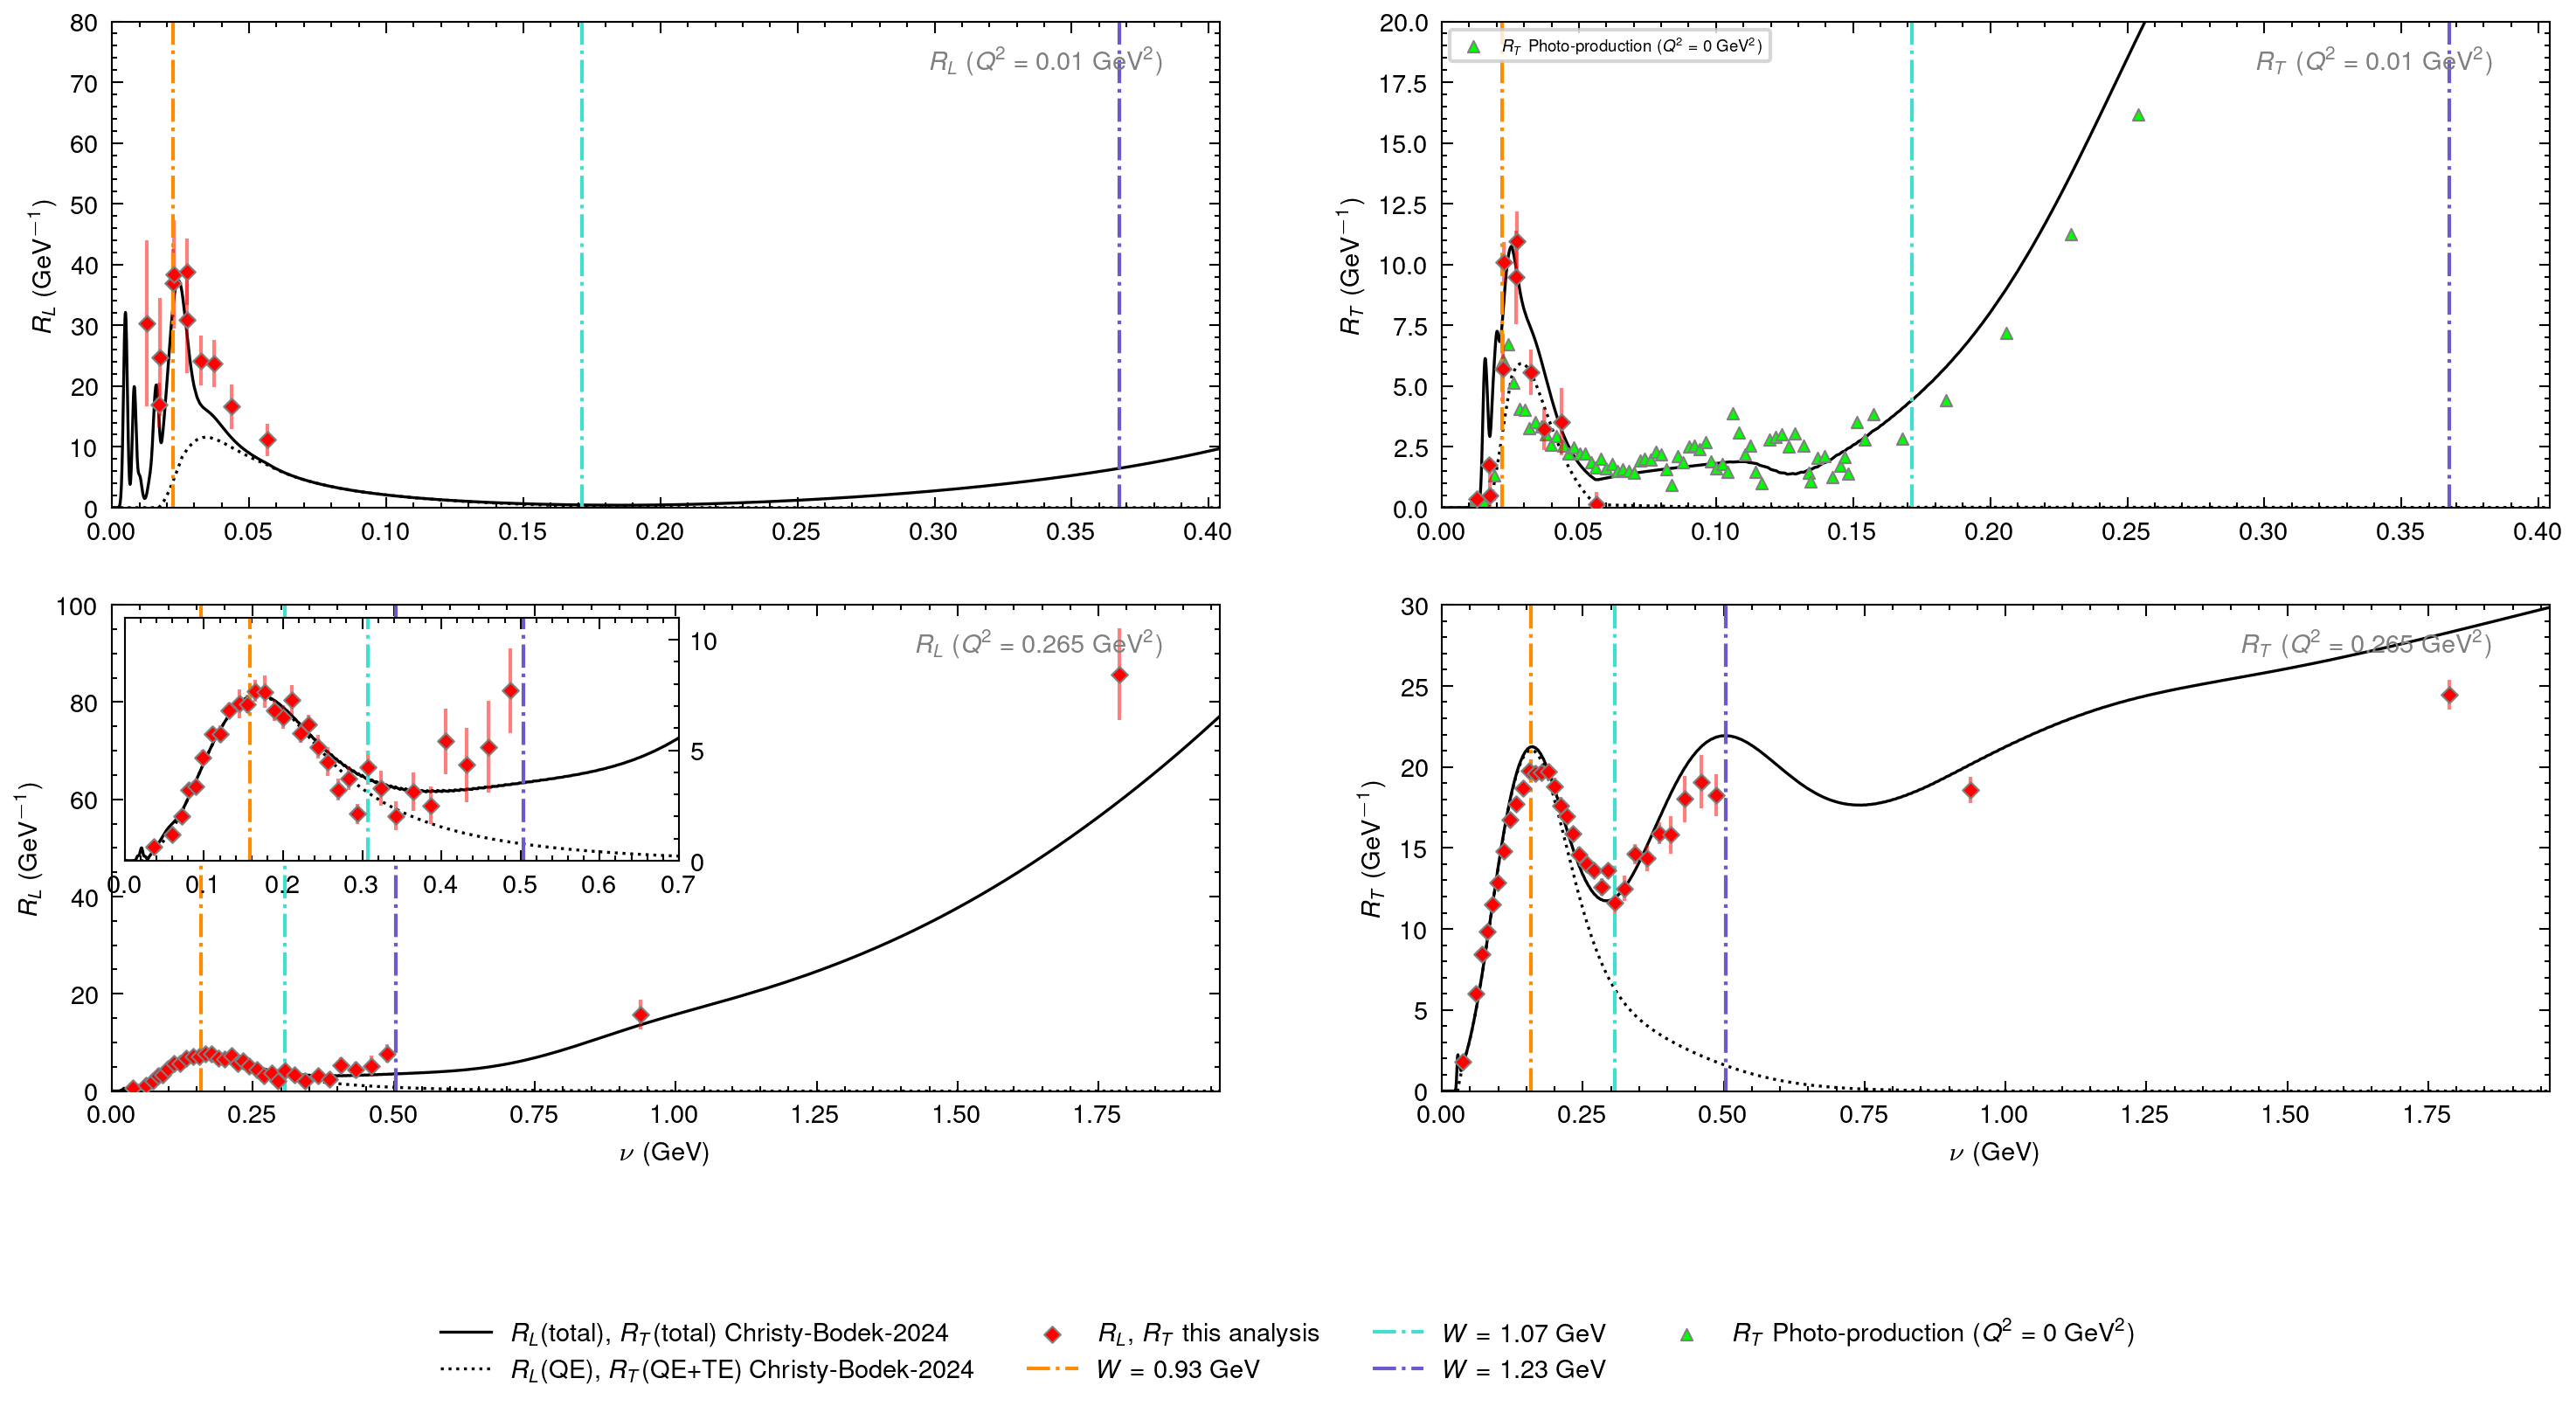

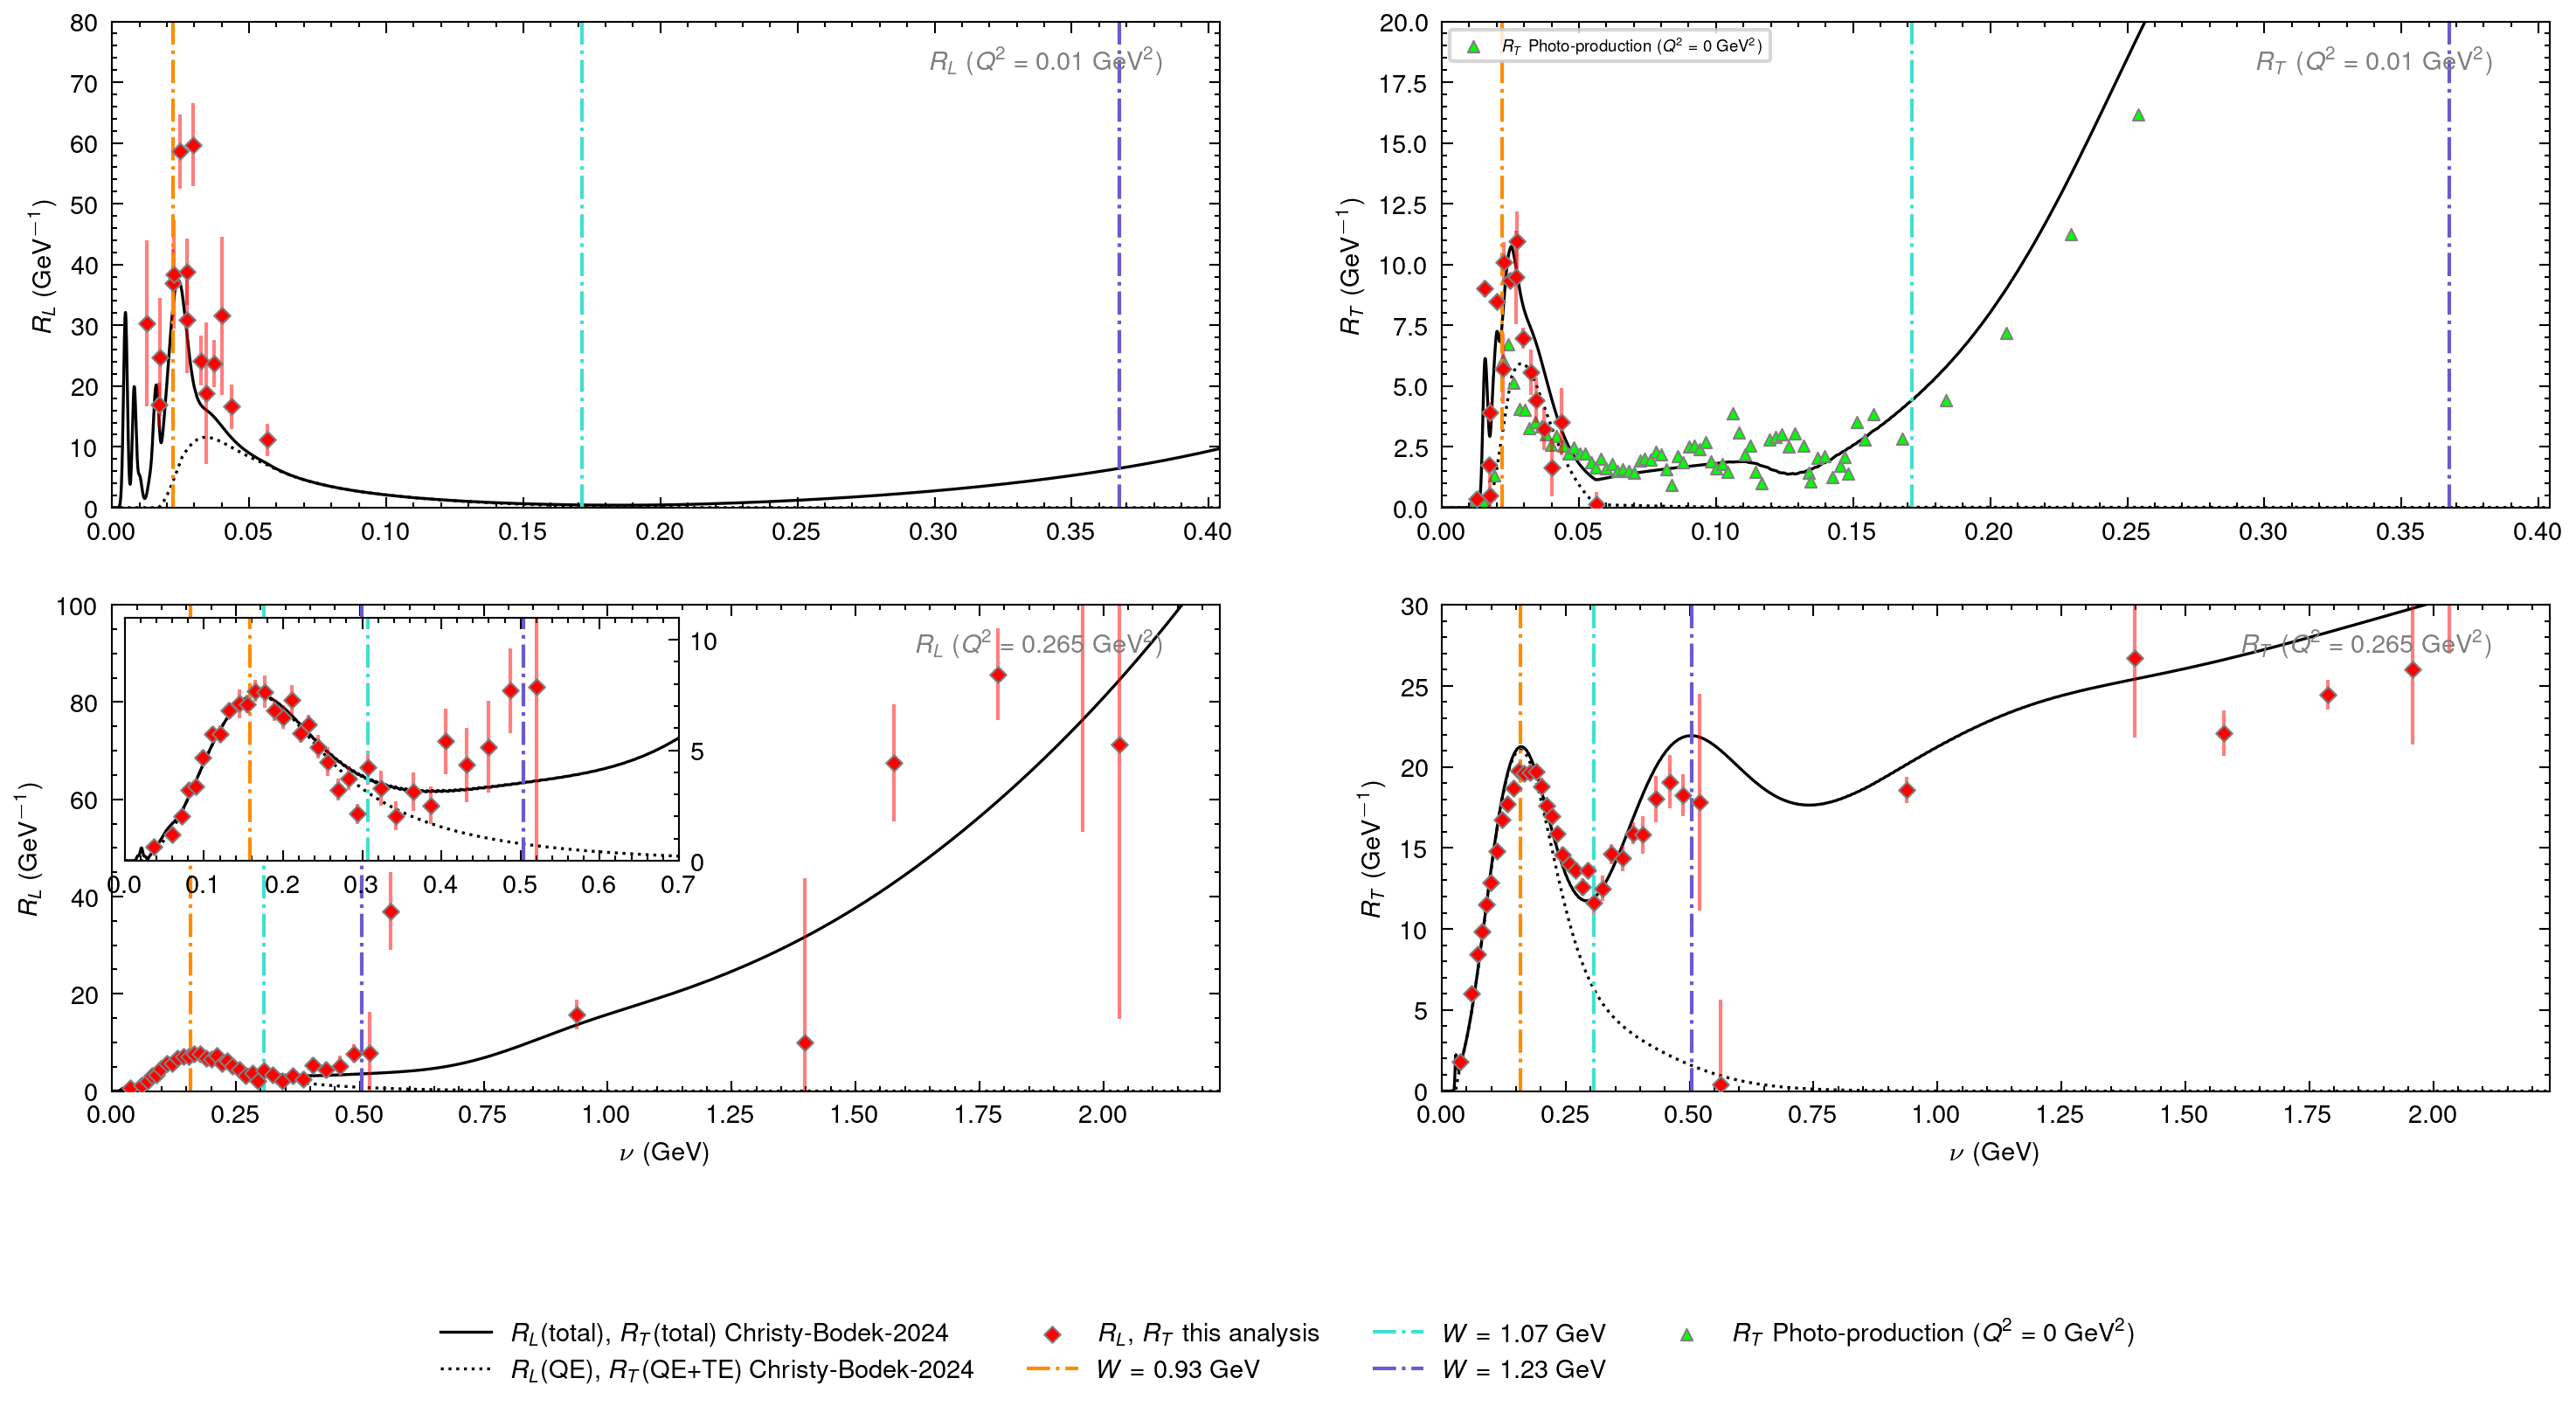

In [ ]:
# (uncomment when use) test plot a bin
# _=RLRT_plot_qvbin(df=df,bin_indices=[0,bin_index],Yamaguchi_plot=False,Goldemberg_plot=False,figsize=(12,6),subplots_adjust=0.2,min_epsilon_range=False)
# _=RLRT_plot_qvbin(df=df,bin_indices=[0,bin_index],Yamaguchi_plot=True,Goldemberg_plot=False,figsize=(12,6),subplots_adjust=0.2,min_epsilon_range=True,
#     Jourdan_plot=True,Barreau_plot=True,EDRMF_Tania_plot=True,bc=True)
# _=RLRT_plot_qvbin(df=df,bin_indices=[0,bin_index],Yamaguchi_plot=False,Goldemberg_plot=False,figsize=(12,6),subplots_adjust=0.2,min_epsilon_range=False,
#     Jourdan_plot=True,Barreau_plot=True,EDRMF_Tania_plot=True,bc=True)
# just plot the targeted bin
# _=RLRT_plot_Q2bin(df=df,bin_indices=[0,bin_index],Yamaguchi_plot=True,Goldemberg_plot=False,figsize=(12,6),subplots_adjust=0.2,min_epsilon_range=True)
# _=RLRT_plot_Q2bin(df=df,bin_indices=[0,bin_index],Yamaguchi_plot=False,Goldemberg_plot=False,figsize=(12,6),subplots_adjust=0.2,min_epsilon_range=False)
# plot Rosenbluth
# _=RLRT_extract_qv_w2(df=df,bin_index=bin_index,Rosenbluth_plot=False,bc=True,min_epsilon_range=False)
# _=RLRT_extract_q2_w2(df=df,bin_index=bin_index,Rosenbluth_plot=True,min_epsilon_range=False)
# _=RLRT_extract_q2_ex(df=df,bin_index=bin_index,Rosenbluth_plot=True,min_epsilon_range=False)


In [ ]:
# # plot Q2bins, qvbins to pdf (df data)

# with PdfPages('Carbon/12C_plots/data_Q2bin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig = RLRT_plot_Q2bin(df=df,bin_indices=bin_indices,Yamaguchi_plot=True,Goldemberg_plot=True,Sheren_plot=True)
#         pdf.savefig(fig)


# with PdfPages('Carbon/12C_plots/data_qvbin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig = RLRT_plot_qvbin(df=df,bin_indices=bin_indices,Yamaguchi_plot=True,Goldemberg_plot=True)
#         pdf.savefig(fig)

# ## print W2center, Excenter length
# # for Q2center in Q2centers:
# #     print(Q2center,'Ex len:',len(df.loc[(df['Q2center'] == Q2center) & (df['Ex'] < Ex_cut),'Ex']),
# #           'W2 len:',len(df.loc[(df['Q2center'] == Q2center) & (df['Ex'] >= Ex_cut),'W2']))
# # print()
# # for qvcenter in qvcenters:
# #     print(qvcenter,'Ex len:',len(df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] < Ex_cut),'Ex']),
# #           'W2 len:',len(df.loc[(df['qvcenter'] == qvcenter) & (df['Ex'] >= Ex_cut),'W2']))



In [ ]:
# fig 7: qvbin with previous experiment comparison; fig 8,9,10: qvbin with theory comparison; fig 11: qvbin ex region

# fig7 6/30/2025 
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig7.pdf') as pdf:

    handles = []
    labels = []
    fig, axs = plt.subplots(nrows=4, ncols=2, figsize=(10,8),dpi=300)


    RL_plot_heights = np.array([0.05,0.09,0.08,0.10,0.11, 
        0.05,0.0440, 0.0175, 0.0150,0.01, 
        0.01, 0.015,0.1,0.12,0.08,
        0.05,0.04,0.0125])*1e3
    RT_plot_heights = np.array([0.012,0.027,0.03,0.035,0.041,
        0.044,0.045,0.045,0.049,0.04,
        0.042,0.045,0.045,0.035,0.035,
        0.026,0.015,0.012])*1e3
    QE_left = [0,0,0,0,0,
            0,0,0,0,0,
            0.2,0.2,0.7,1.0,1.2,
            1.5,1.8,2.4]
    QE_right = [0.7,0.7,0.7,0.7,0.7,
                0.7,0.7,0.7,0.7,0.7,
                3,0.9,1.5,1.8,2.0,
                2.3,2.6,3.3]
    RLQE_top = np.array([0.02,0.03,0.04,0.5,0.5,
                    0.02,0.02, 0.08, 0.007,0.003, 
                    0.001, 0.005,0.0012,0.0006,0.0006,
                    0.0003,0.0003,0.0003])*1e3
    RTQE_top = np.array([0.013,0.027,0.03,0.035,0.041,
                    0.044,0.045,0.045,0.049,0.04,
                    0.05,0.02,0.005,0.0025,0.002,
                    0.0015,0.001,0.0008])*1e3



    bin_indices = [5,6,8]

    for i in range(3):
        bin_index = bin_indices[i]
        qvcenter = qvcenters[bin_index]
        if qvcenter in [0.3,0.38,0.475,0.57,0.649,0.756]:
            # fit = pd.read_excel('C12paper_figures/qvbin/RLRT_qv_extractions/qvbin_'+str(qvcenter)+' final.xlsx')        
            # fit = pd.concat([RLRT_extract_qv_ex(df,bin_index=bin_index),
            #                 RLRT_extract_qv_w2(df,bin_index=bin_index)])
            fit = RLRT_extract_qv_w2(df,bin_index=bin_index)
        fit['RL'] = fit['RL']*RL_correction
        fit['RLerr'] = fit['RLerr']*RL_correction
        fit['RT'] = fit['RT']*RT_correction
        fit['RTerr'] = fit['RTerr']*RT_correction

        # if qvcenter >= 0.31:
        #     fit = fit.loc[fit['Ex']>=0.03]
        # Christy-Bodek fit RLRT total
        ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)

        ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']    
        ChristyBodekFit['RL'] = ChristyBodekFit['RL']*1e3
        ChristyBodekFit['RLQE'] = ChristyBodekFit['RLQE']*1e3
        ChristyBodekFit['RT'] = ChristyBodekFit['RT']*1e3
        ChristyBodekFit['RTQE'] = ChristyBodekFit['RTQE']*1e3
        ChristyBodekFit['RTE'] = ChristyBodekFit['RTE']*1e3
        ChristyBodekFit['RLIE'] = ChristyBodekFit['RLIE']*1e3
        ChristyBodekFit['RTIE'] = ChristyBodekFit['RTIE']*1e3
        ChristyBodekFit['RLNS'] = ChristyBodekFit['RLNS']*1e3
        ChristyBodekFit['RTNS'] = ChristyBodekFit['RTNS']*1e3

        # Christy-Bodek fit RLRT total
        axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RL"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',lw=0.8)
        axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"],color='black', linestyle='solid',lw=0.8)
        # 2025 July 18 RT quasi deuteron added
        axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"]+RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']),
                    color='black', linestyle='-',zorder=0,lw=0.8)

        # Christy-Bodek fit RLRT QE only

        axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"],color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dashed',lw=0.8) 
        axs[i,1].plot(ChristyBodekFit['nu'],(ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"]),color='black', linestyle='dashed',lw=0.8)

        # # Christy-Bodek fit RLRT no delta (NS + QE)
        # axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RLNS"]+ChristyBodekFit["RLQE"],color='black',label="$R_L$(QE+NS), $R_T$(QE+NS) Christy-Bodek-2024", linestyle='dotted')
        # axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RTNS"]+ChristyBodekFit["RTQE"],color='black', linestyle='dotted')
                
        # Yamaguchi    
        if qvcenter in [0.148,0.167,0.205,0.24,0.3] :
            # Yamaguchi RL
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            axs[i,0].scatter(Yam_data['nu_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[i,0].plot(Yam_data['nu_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-2)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            axs[i,1].scatter(Yam_data['nu_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[i,1].plot(Yam_data['nu_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-2)
            nu_Yamaguchi = Yam_data['nu_RL'].max()
            fit = fit.loc[fit['nu']>nu_Yamaguchi+0.002]

        # Jourdan
        if qvcenter in [0.3,0.38,0.57] :
            Jourdan_data = pd.read_excel('Carbon/12C_other_extractions/Jourdan/Jourdan_RL_RT_plots.xlsx')
            Jourdan_data = Jourdan_data.loc[Jourdan_data['Q']==qvcenter]
            Jourdan_data['RL'] = Jourdan_data['RL']*1e3
            Jourdan_data['RT'] = Jourdan_data['RT']*1e3
            Jourdan_data['Error(RL)'] = Jourdan_data['Error(RL)']*1e3
            Jourdan_data['Error(RT)'] = Jourdan_data['Error(RT)']*1e3
            axs[i,0].scatter(Jourdan_data['nu'],Jourdan_data["RL"],color='limegreen',label="$R_L$, $R_T$ Jourdan", **scatter_setting,marker='v')
            axs[i,0].errorbar(Jourdan_data['nu'],Jourdan_data["RL"], yerr = Jourdan_data["Error(RL)"], color='limegreen', **errorbar_setting)
            axs[i,1].scatter(Jourdan_data['nu'],Jourdan_data["RT"],color='limegreen', **scatter_setting,marker='v')
            axs[i,1].errorbar(Jourdan_data['nu'],Jourdan_data["RT"], yerr = Jourdan_data["Error(RT)"], color='limegreen', **errorbar_setting)

        # Barreau
        if qvcenter in [0.3,0.38,0.57] :
            
            Bar_RL = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RL_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RT = pd.read_csv('Carbon/12C_other_extractions/Barreau/Barreau_RT_qvcenter_'+str(qvcenter)+'.csv')
            Bar_RL['RLbc'] = Bar_RL['RLbc']*1e3
            Bar_RL['RLerr_bc'] = Bar_RL['RLerr_bc']*1e3
            Bar_RT['RTbc'] = Bar_RT['RTbc']*1e3
            Bar_RT['RTerr_bc'] = Bar_RT['RTerr_bc']*1e3
            axs[i,0].scatter(Bar_RL['nu'],Bar_RL["RLbc"],color='yellow',label="$R_L$, $R_T$ Barreau", **scatter_setting,marker='H')
            axs[i,0].errorbar(Bar_RL['nu'],Bar_RL["RLbc"], yerr = Bar_RL["RLerr_bc"], color='black', **errorbar_setting)
            axs[i,1].scatter(Bar_RT['nu'],Bar_RT["RTbc"],color='yellow', **scatter_setting,marker='H')
            axs[i,1].errorbar(Bar_RT['nu'],Bar_RT["RTbc"], yerr = Bar_RT["RTerr_bc"], color='black', **errorbar_setting)

        # Buki
        if  qvcenter == 0.3 :
            df_Buki = pd.read_csv('Carbon/12C_other_extractions/Buki/Buki.csv')
            df_Buki['RL'] = df_Buki['RL']*1e3
            df_Buki['RT'] = df_Buki['RT']*1e3
            df_Buki['RLerr'] = df_Buki['RLerr']*1e3
            df_Buki['RTerr'] = df_Buki['RTerr']*1e3
            axs[i,0].errorbar(df_Buki['nu_RL'],df_Buki['RL'],yerr=df_Buki['RLerr'],color='blue',**errorbar_setting)
            axs[i,0].scatter(df_Buki['nu_RL'],df_Buki['RL'],color='blue',label="$R_L$, $R_T$ Buki",**scatter_setting,marker='P')
            axs[i,1].errorbar(df_Buki['nu_RT'],df_Buki['RT'],yerr=df_Buki['RTerr'],color='blue',**errorbar_setting)
            axs[i,1].scatter(df_Buki['nu_RT'],df_Buki['RT'],color='blue',**scatter_setting,marker='P')


        # RL RT this analysis


        fit['RL']=fit['RL']*1e3
        fit['RLerr']=fit['RLerr']*1e3
        
        axs[i,0].scatter(fit['nu'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
        axs[i,0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting, ecolor='red')

        fit['RT']=fit['RT']*1e3
        fit['RTerr']=fit['RTerr']*1e3
        axs[i,1].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
        axs[i,1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], color='red', **errorbar_setting,ecolor='red')
    




        # Photo-production:
        photon_data, photon_data_err = photon_locator(qvcenter)
        axs[i,1].scatter(np.array(qvcenter),np.array(photon_data)*1e3,label="$R_T$ Photo-production",**photo_scatter_setting)
        axs[i,1].errorbar(np.array(qvcenter),np.array(photon_data)*1e3,yerr = np.array(photon_data_err),**errorbar_setting)

        # _________________________

        # These W (final state invariant mass) are put on plot for kinematic reference
        W_peaks = np.array([0.93,1.07,1.23]) 
        W_colors = ['darkorange','turquoise','slateblue']
        W_locations = 0.025-mass_nucleon+np.sqrt(qvcenter**2+W_peaks**2)
        # text_offset=0.1*W_locations[0]
        W_labels = ['','','']
        # RL_plot_height = RL_plot_heights[bin_index]
        # RT_plot_height = RT_plot_heights[bin_index]
        
        for k in range(len(W_peaks)):
            location = W_locations[k]
            if location < qvcenter:
                axs[i,0].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1,label=f'$W={W_peaks[k]}$ GeV '+W_labels[k])
                axs[i,1].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)
        
        axs[i,0].axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1,label=f'$Q^2=0$ GeV$^2$')
        axs[i,1].axvline(x=qvcenter, color = 'brown', linestyle='dashdot',lw=1)
        axs[i,0].set_xlim(0.0, qvcenter*1.05)
        axs[i,1].set_xlim(0.0, qvcenter*1.05)
        # _________________________

        
        axs[i,0].set_ylim(0,RL_plot_heights[bin_index])
        axs[i,1].set_ylim(0,RT_plot_heights[bin_index])

        # plt.tight_layout()

        h, l = axs[i,0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i,1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)


        # plot labeling:
        axs[i,0].text(0.95, 0.95,'$R_L$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,'$R_T$ ($|\mathbf{q}|$ = '+f'{qvcenter} GeV)',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')
        
        axs[i,0].set_ylabel('$R_L$ (GeV$^{-1}$)')
        axs[i,1].set_ylabel('$R_T$ (GeV$^{-1}$)')
        # axs[i,0].set_xlabel('$\\nu \ (GeV)$')
        # axs[i,1].set_xlabel('$\\nu \ (GeV)$')


    W_labels=['','','']

    QE_left = [0,0,0,0,0,
            0,0,0,0,0.1,
            0.05,0.2,0.4,0.7,0.9,
            1.2,1.4,1.7]
    QE_right = [0.7,0.7,0.7,0.7,0.7,
            0.7,0.7,0.7,0.7,0.67,
            0.8,0.9,1.2,1.5,1.8,
            2.0,2.4,2.7]
    RLQE_top = np.array([0.02,0.03,0.04,0.5,0.5,
            0.02,0.02, 0.08, 0.007,0.008, 
            0.005, 0.003,0.0012,0.0006,0.0006,
            0.0003,0.0001,0.00006])*1e3
    RTQE_top = np.array([0.013,0.027,0.03,0.035,0.041,
            0.044,0.045,0.045,0.049,0.03,
            0.03,0.015,0.005,0.003,0.002,
            0.001,0.0007,0.00022])*1e3
    RL_plot_heights = np.array([0.08,0.065,0.08,0.10,0.11,
            0.06,0.032, 0.022, 0.0140,0.08, 
            0.07, 0.04, 0.019,0.012,0.01,   
            0.007, 0.005,0.0025])*1e3
    RT_plot_heights = np.array([0.035,0.033,0.035,0.035,0.041,
            0.044,0.04,0.03,0.03,0.05,
            0.05,0.04,0.025,0.015,0.016,  
            0.01, 0.007,0.004])*1e3

    RL_lower_bounds = np.array([0,-10,-100,-60,-60,-20,-20,
            -10,-6,-6,-6,-6,
            0,0,0,0,0,
            0,0,0])
    RT_lower_bounds = np.array([0,-6,-6,-6,-6,
            -6,-6,-2,-2,
            0,0,0,0,0,
            0,0,0])

    for i in [3]:
        # bin_index = bin_indices[i]
        bin_index = 5

        Q2center = Q2centers[bin_index]
        if Q2center in [0.093,0.265,0.38,0.5]:
            # fit = pd.read_excel('C12paper_figures/Q2bin/RLRT_Q2_extractions/Q2bin_'+str(Q2center)+' final.xlsx')
            fit = pd.concat([RLRT_extract_q2_ex(df,bin_index=bin_index),
                            RLRT_extract_q2_w2(df,bin_index=bin_index)])


        ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Q2edges/'+f'Q2edge_{Q2center}.csv',index_col = False)
        ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
        ChristyBodekFit['RL'] = ChristyBodekFit['RL']*1e3
        ChristyBodekFit['RLQE'] = ChristyBodekFit['RLQE']*1e3
        ChristyBodekFit['RT'] = ChristyBodekFit['RT']*1e3
        ChristyBodekFit['RTQE'] = ChristyBodekFit['RTQE']*1e3
        ChristyBodekFit['RTE'] = ChristyBodekFit['RTE']*1e3
        # RLRT total
        axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RL"],color='black',label="$R_L$(total), $R_T$(total) Christy-Bodek-2024", linestyle='solid',zorder=0,lw=0.8)
        # axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"],color='black', linestyle='solid',zorder=0,lw=0.8)
        # 2025 July 18 RT quasi deuteron added
        axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RT"]+RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex']),
                    color='black', linestyle='-',zorder=0,lw=0.8)

        # RLRT QE
        axs[i,0].plot(ChristyBodekFit['nu'],ChristyBodekFit["RLQE"],color='black',label="$R_L$(QE), $R_T$(QE+TE) Christy-Bodek-2024", linestyle='dotted',zorder=0,lw=0.8) 
        axs[i,1].plot(ChristyBodekFit['nu'],ChristyBodekFit["RTQE"]+ChristyBodekFit["RTE"],color='black', linestyle='dotted',zorder=0,lw=0.8)
        
        # Yamaguchi
        Yama_qvcenter = qvcenters[bin_index]
        
        if Yama_qvcenter in [0.148,0.167,0.205,0.24,0.3]:
            # Yamaguchi RL

            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))                    
            Yam_data['RL'] = Yam_data['RL']*1e3
            axs[i,0].scatter(Yam_data['nu_RL'],Yam_data["RL"],color='cyan',label="$R_L$, $R_T$ Yamaguchi",**yam_scatter)
            axs[i,0].plot(Yam_data['nu_RL'],Yam_data["RL"],lw=0.5,color='gray',zorder=-1)
            # Yamaguchi RT
            Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))
            Yam_data['RT'] = Yam_data['RT']*1e3
            axs[i,1].scatter(Yam_data['nu_RT'],Yam_data["RT"],color='cyan',**yam_scatter)
            axs[i,1].plot(Yam_data['nu_RT'],Yam_data["RT"],lw=0.5,color='gray',zorder=-1)
            fit = fit.loc[fit['nu']>=Yam_data['nu_RL'].max()]

        # RL this analysis

        fit['RL']=fit['RL']*1e3
        fit['RLerr']=fit['RLerr']*1e3
        fit['RT']=fit['RT']*1e3
        fit['RTerr']=fit['RTerr']*1e3
        axs[i,0].scatter(fit['nu'], fit['RL'],color='red',label='$R_L$, $R_T$ this analysis',**our_scatter_setting)
        axs[i,0].errorbar(fit['nu'], fit['RL'], yerr = fit['RLerr'], color='red', **errorbar_setting)


        # RT this analysis
        axs[i,1].scatter(fit['nu'], fit['RT'],color='red',**our_scatter_setting)
        axs[i,1].errorbar(fit['nu'], fit['RT'], yerr = fit['RTerr'], ecolor='red',  **errorbar_setting)


        # Baran
        if Q2center==0.093:
            axs[i,0].axhline(y=0, color='grey', linestyle='-')
            Baran = pd.read_csv('Carbon/12C_other_extractions/Baran/BaranRLRT.txt',sep='\s+')
            Baran['RL'] = Baran['RL']
            Baran['RLerr'] = Baran['RLerr']
            Baran['RT'] = Baran['RT']
            Baran['RTerr'] = Baran['RTerr']
            # baran_scatter_setting = {'s':30,'edgecolors':'black','linewidth':0.5,'zorder':3,'alpha':1}
            axs[i,0].scatter(Baran['nuRL'], Baran['RL'],color='orange',label='$R_L$, $R_T$ Baran ($Q^2$ = 0.1 GeV$^2$)',**baran_scatter_setting)
            axs[i,0].errorbar(Baran['nuRL'], Baran['RL'], yerr = Baran['RLerr'], ecolor='orange', **errorbar_setting)
            axs[i,1].scatter(Baran['nuRT'], Baran['RT'],color='orange',**baran_scatter_setting)
            axs[i,1].errorbar(Baran['nuRT'], Baran['RT'], yerr = Baran['RTerr'], ecolor='orange', **errorbar_setting)


        W_peaks = np.array([0.93,1.07,1.23]) 
        W_colors = ['darkorange','turquoise','slateblue']
        W_locations = 0.025 + (W_peaks**2+Q2center-mass_nucleon**2)/(2*mass_nucleon)

        for k in range(len(W_peaks)):

            location = W_locations[k]
            # if location < fit['nu'].max():
            axs[i,0].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1,label=f'$W={W_peaks[k]}$ GeV '+W_labels[k])
            axs[i,1].axvline(x=location, color = W_colors[k], linestyle='dashdot',lw=1)

        if fit['nu'].max() > W_locations[2]:
            xmax = fit['nu'].max()*1.1
            axs[i,0].set_xlim(0.0, xmax)
            axs[i,1].set_xlim(0.0, xmax)

        else:
            axs[i,0].set_xlim(0.0, W_locations[2]*1.1)
            axs[i,1].set_xlim(0.0, W_locations[2]*1.1)

        axs[i,0].set_ylim(-10,RL_plot_heights[bin_index])
        axs[i,1].set_ylim(-1,RT_plot_heights[bin_index])


        # plot labeling:
        axs[i,0].text(0.95, 0.95,f'$R_L$ ($Q^2$ = {Q2center} GeV$^2$)',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,f'$R_T$ ($Q^2$ = {Q2center} GeV$^2$)',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')

        axs[i,0].set_ylabel('$R_L$ (GeV$^{-1}$)')
        axs[i,1].set_ylabel('$R_T$ (GeV$^{-1}$)')
        axs[i,0].set_xlabel('$\\nu$ (GeV)')
        axs[i,1].set_xlabel('$\\nu$ (GeV)')


        h, l = axs[i,0].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
        h, l = axs[i,1].get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    # unique_handles = []
    # unique_labels = []
    # for label in labels:
    #     if label not in unique_labels:
    #         unique_labels.append(label)
    #         if label == 'RL, RT GENIE-LFG':
    #             # 's':12,'edgecolors':'black','linewidth':0.5,'zorder':3,'alpha':1
    #             unique_handles.append(plt.Line2D([0], [0], color='violet', linestyle='-', marker='s',  linewidth=2,alpha=0.7,markersize=6))
    #         elif label == 'RL, RT GENIE-SUSA':
    #             unique_handles.append(plt.Line2D([0], [0], color='green', linestyle='-', marker='*',  linewidth=2,alpha=0.7, markersize=6))
    #         else:
    #             unique_handles.append(handles[labels.index(label)])
    #         # unique_handles.append(handles[labels.index(label)])

    # fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4,frameon=False)
    # plt.tight_layout()
    # plt.subplots_adjust(bottom=0.15)
    # plt.show()


    unique_handles = []
    unique_labels = []
    for label in labels:
        if label not in unique_labels:
            unique_labels.append(label)
            unique_handles.append(handles[labels.index(label)])

    # print(unique_labels)
    fig.legend(unique_handles, unique_labels, loc='lower center', ncol=4,frameon=False)
    # plt.tight_layout()
    plt.subplots_adjust(bottom=0.13)
    plt.show()
    pdf.savefig(fig)

# fig8
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig8.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[0,1,2,3,4],
                          # figsize=(10,10),
                        #   legend_ncol=3, 
                          EDRMF_Tania_plot=True,
                    Jourdan_plot=True, Barreau_plot=True,Buki_plot=True)
    pdf.savefig(fig)

# fig9
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig9.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[5,6,7,8,9], GFMC_plot=True, EDRMF_Tania_plot=True, STA_plot=True,subplots_adjust=0.1)
    pdf.savefig(fig)

# fig10
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig10.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[10,11],figsize=(10,3.5),
                          subplots_adjust=0.23,  
                          GFMC_plot=True, EDRMF_Tania_plot=True,STA_plot=True)
    pdf.savefig(fig)

# fig11
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig11.pdf') as pdf:
    fig = RLRT_plot_qvbin_ex(df,bin_indices=[0,1,2,3,4,5,6,8],
                             subplots_adjust=0.1,
                             GFMC_plot=True,EDRMF_Tania_plot=True,ChristyBodekFit_plot = True, STA_plot=True)
    pdf.savefig(fig)

In [ ]:
# fig 12,13,14,15: qvbin with MC comparison

# fig12
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig12.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[0,1,2,3,4],subplots_adjust=0.1,NuWRo_SF_FSI_plot=True, NuWRo_SF_plot=True, CFG_plot=True,ACHILLES_plot=True)
    pdf.savefig(fig)

# fig13
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig13.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[5,6,7,8,9],subplots_adjust=0.12,NuWRo_SF_FSI_plot=True, NuWRo_SF_plot=True, CFG_plot=True,ACHILLES_plot=True)
    pdf.savefig(fig)

# fig14
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig14.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[10,11,12,13,14],subplots_adjust=0.1,NuWRo_SF_FSI_plot=True, NuWRo_SF_plot=True, CFG_plot=True,ACHILLES_plot=True)
    pdf.savefig(fig)

# fig15
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig15.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[15,16,17],figsize=(10,5.5),subplots_adjust=0.15,NuWRo_SF_FSI_plot=True, NuWRo_SF_plot=True, CFG_plot=True,ACHILLES_plot=True)
    pdf.savefig(fig)

In [ ]:
# fig 16,17,18,19: Q2bin with EDRMF and NuWro comparison; fig 20: Q2bin ex region

# fig16
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig16.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[0,1,2,3,4],
        # figsize=(8,8),
        # subplot_adjust=0.16,
        NuWRo_SF_plot=True,Sheren_plot=True,
        EDRMF_Tania_plot=True, NuWRo_SF_FSI_plot=True)
    pdf.savefig(fig)

# fig17
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig17.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[5,6,7,8,9],
        # figsize=(8,8),
        subplots_adjust=0.1,
        NuWRo_SF_plot=True,Sheren_plot=True,
        EDRMF_Tania_plot=True, NuWRo_SF_FSI_plot=True)
    pdf.savefig(fig)

# fig18
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig18.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[10,11,12,13,14],
        # figsize=(8,8),
        subplots_adjust=0.1,
        NuWRo_SF_plot=True,Sheren_plot=True,
        EDRMF_Tania_plot=True, NuWRo_SF_FSI_plot=True)
    pdf.savefig(fig)

# fig19
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig19.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[15,16,17],
        figsize=(10,5),
        subplots_adjust=0.13,
        NuWRo_SF_plot=True,Sheren_plot=True,
        EDRMF_Tania_plot=True, NuWRo_SF_FSI_plot=True)
    pdf.savefig(fig)

# fig20
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig20.pdf') as pdf:
    fig = RLRT_plot_Q2bin_ex(df=df,bin_indices=[0,1,2,3,4,5,6,7],Rosenbluth_plot=False, Yamaguchi_plot=True,Photon_plot=True,subplots_adjust=0.1,
                        Goldemberg_plot=True, EDRMF_Tania_plot=True,NuWRo_SF_FSI_plot=False, NuWRo_SF_plot=False)
    pdf.savefig(fig)

In [ ]:
# fig 21,22,23,24: qvbin with EDRMF, SuSAv2 cocmparison

# fig 21
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig21.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[0,1,2,3,4],
                        subplots_adjust=0.12,
                        EDRMF_Tania_plot=True,
                        # SuSA_extract_RLRT=True,
                        SuSAv2_plot=True, susalw=1.5,edrmflw=3,
                        EDRMF_SuSA2p2h_plot=True
    )
    pdf.savefig(fig)

# fig 22
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig22.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[5,6,7,8,9],
                        subplots_adjust=0.12,
                        EDRMF_Tania_plot=True,
                        # SuSA_extract_RLRT=True,
                        SuSAv2_plot=True, susalw=1.5,edrmflw=3,
                        EDRMF_SuSA2p2h_plot=True
    )
    pdf.savefig(fig)

# fig 23
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig23.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[10,11,12,13,14],
                        subplots_adjust=0.11,
                        EDRMF_Tania_plot=True,susalw=1.5,edrmflw=3,
                        # SuSA_extract_RLRT=True,
                        SuSAv2_plot=True, 
                        EDRMF_SuSA2p2h_plot=True
    )
    pdf.savefig(fig)

# fig 24
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig24.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[15,16,17],
                        figsize=(10,5),
                        subplots_adjust=0.16,
                        EDRMF_Tania_plot=True,
                        # SuSA_extract_RLRT=True,
                        SuSAv2_plot=True, susalw=1.5,edrmflw=3,
                        EDRMF_SuSA2p2h_plot=True
    )
    pdf.savefig(fig)



In [ ]:
# fig 25,26,27,28: Q2bin with EDRMF, SuSAv2 comparison
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig25.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[0,1,2,3,4],
        figsize=(10,9),
        subplots_adjust=0.12,SuSAv2_plot=True,EDRMF_SuSA2p2h_plot=True,
        Sheren_plot=True,edrmflw=3,susalw=1.5,
        EDRMF_Tania_plot=True)
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig26.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[5,6,7,8,9],
        figsize=(10,9),
        subplots_adjust=0.12,SuSAv2_plot=True,EDRMF_SuSA2p2h_plot=True,
        Sheren_plot=True,edrmflw=3,susalw=1.5,
        EDRMF_Tania_plot=True)
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig27.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[10,11,12,13,14],
        figsize=(10,9),
        subplots_adjust=0.12,SuSAv2_plot=True,EDRMF_SuSA2p2h_plot=True,
        Sheren_plot=True,edrmflw=3,susalw=1.5,
        EDRMF_Tania_plot=True)
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig28.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[15,16,17],
        figsize=(10,5.5),
        subplots_adjust=0.15,SuSAv2_plot=True,EDRMF_SuSA2p2h_plot=True,
        Sheren_plot=True,edrmflw=3,susalw=1.5,
        EDRMF_Tania_plot=True)
    pdf.savefig(fig)

In [ ]:
# fig 29, 30, 31: Q2bin with SuSAv2 scaled to EDRMF (QE)
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig29.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[0,1,2,3,4],
        figsize=(10,9),
        SuSAv2_scaled_to_EDRMF_QE=True,
        subplots_adjust=0.1,
        edrmflw=1.2,susalw=1.2,
        )
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig30.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[5,6,7,8,9],
        figsize=(10,9),
        SuSAv2_scaled_to_EDRMF_QE=True,
        subplots_adjust=0.1,
        edrmflw=1.2,susalw=1.2,
        )
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig31.pdf') as pdf:
    fig = RLRT_plot_Q2bin(df=df,bin_indices=[10,11,12],
        figsize=(10,5.5),
        SuSAv2_scaled_to_EDRMF_QE=True,
        subplots_adjust=0.15,
        edrmflw=1.2,susalw=1.2,
        )
    pdf.savefig(fig)




In [ ]:
# fig 32, 33, 34: qvbin with SuSAv2 scaled to EDRMF (QE)
with PdfPages('Carbon/12C_plots/RLRT_PRD/fig32.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[0,1,2,3,4],
                        subplots_adjust=0.1,
                        susalw=1.2,edrmflw=1.2,
                        SuSAv2_scaled_to_EDRMF_QE=True,
    )
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig33.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[5,6,7,8,9],
                        subplots_adjust=0.1,
                        susalw=1.2,edrmflw=1.2,
                        SuSAv2_scaled_to_EDRMF_QE=True,
    )
    pdf.savefig(fig)

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig34.pdf') as pdf:
    fig = RLRT_plot_qvbin(df,bin_indices=[10,11],
                        figsize=(10,3.5),
                        subplots_adjust=0.23,  
                        susalw=1.2,edrmflw=1.2,
                        SuSAv2_scaled_to_EDRMF_QE=True,
    )
    pdf.savefig(fig)


In [ ]:
# fig 35: Jordan vs ours ratio plots
# Jordan / our ratio (averaged) correction factors:
# RL            RT    
# 1.04245741    0.920450059
# (valid for q < 1 GeV, Q2 < 0.8 GeV^2)

# errorbar_setting = {'markersize':2,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
errorbar_setting = {'markersize':0,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':1,'alpha':0.7}
our_scatter_setting = {'s':6,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':1,'alpha':0.7}
scatter_setting = {'s':6,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':1,'alpha':0.7}



fig = plt.figure(figsize=(10, 7), dpi=300)

# 3 rows × 2 cols of "containers"
outer = GridSpec(3, 2, figure=fig, wspace=0.15, hspace=0.1)
handles = []
labels = []
axes_main = []
axes_ratio = []

Jordan_Qs = [0.3,0.38,0.57]
for i in range(3):
    qvcenter = Jordan_Qs[i]
    Jourdan = pd.read_excel('Carbon/12C_other_extractions/Jourdan/JourdanRLRT_vs_ourRLRT.xlsx')

    Jourdan = Jourdan.loc[Jourdan['Q']==qvcenter]

    # pick the outer cell
    inner = outer[i, 0].subgridspec(
        2, 1, height_ratios=[3, 1], hspace=0.08, 
    )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)



    # our RL
    ax_main.scatter(Jourdan['nu (GeV)'], Jourdan['RL (GeV^-1)'],color='red',label='$R_L, R_T$ this analysis (before normalization)',**our_scatter_setting)
    ax_main.errorbar(Jourdan['nu (GeV)'], Jourdan['RL (GeV^-1)'], yerr = Jourdan['RL error (GeV^-1)'], color='red', **errorbar_setting)
    # Jordan RL
    ax_main.scatter(Jourdan['nu'],Jourdan["RL"],color='limegreen',label='$R_L, R_T$ Jourdan', **scatter_setting,marker='v')
    ax_main.errorbar(Jourdan['nu'],Jourdan["RL"], yerr = Jourdan["Error(RL)"], color='limegreen', **errorbar_setting)
    # print a text on top right
    ax_main.text(0.95, 0.95, f"$R_L$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_ylabel("$R_L$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    # ratio
    ax_ratio.scatter(Jourdan['nu (GeV)'], Jourdan['RL ratio'], color='steelblue', label='Ratio Jourdan / this analysis', **scatter_setting)
    ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RL ratio'], yerr=Jourdan['RL ratio error'], color='steelblue',**errorbar_setting)

    # ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RL ratio'], yerr=Jourdan['RL ratio error'], color='blue',**errorbar_setting)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.set_yticks([0.5,1.0,1.5])

    h, l = ax_main.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = ax_ratio.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)


    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")





    # pick the outer cell
    inner = outer[i, 1].subgridspec(
        2, 1, height_ratios=[3, 1], hspace=0.08  # tight stack
    )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)


    # our RT
    ax_main.scatter(Jourdan['nu (GeV)'], Jourdan['RT (GeV^-1)'],color='red',**our_scatter_setting)
    ax_main.errorbar(Jourdan['nu (GeV)'], Jourdan['RT (GeV^-1)'], yerr = Jourdan['RL error (GeV^-1)'], color='red', **errorbar_setting)
    # Jourdan RL
    ax_main.scatter(Jourdan['nu'],Jourdan["RT"],color='limegreen', **scatter_setting,marker='v')
    ax_main.errorbar(Jourdan['nu'],Jourdan["RT"], yerr = Jourdan["Error(RT)"], color='limegreen', **errorbar_setting)

    # print a text on top right
    ax_main.text(0.95, 0.95, f"$R_T$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_ylabel("$R_T$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    ax_ratio.scatter(Jourdan['nu (GeV)'], Jourdan['RT ratio'], color='steelblue', **scatter_setting)
    ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RT ratio'], yerr=Jourdan['RT ratio error'], color='steelblue',**errorbar_setting)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.set_yticks([0.5,1.0,1.5])
    

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")
unique_handles = []
unique_labels = []
for label in labels:
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])


plt.subplots_adjust(bottom=0.08)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=3,frameon=False)



# fig.suptitle("3×2 grid with ratio panels", fontsize=14)
plt.show()


with PdfPages('Carbon/12C_plots/RLRT_PRD/fig35.pdf') as pdf:
    pdf.savefig(fig)


In [ ]:
# fig 36: EDRMF vs ACHILLES ratio plots

# errorbar_setting = {'markersize':2,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
errorbar_setting = {'markersize':0,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':1,'alpha':0.7}
our_scatter_setting = {'s':6,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':1,'alpha':0.7}
scatter_setting = {'s':6,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':1,'alpha':0.7}



fig = plt.figure(figsize=(10, 10), dpi=300)
Qs = [0.57, 0.649, 0.756, 0.991]

# 3 rows × 2 cols of "containers"
outer = GridSpec(len(Qs), 2, figure=fig, wspace=0.15, hspace=0.1)

handles = []
labels = []
axes_main = []
axes_ratio = []


for i in range(len(Qs)):
    qvcenter = Qs[i]
    df_ACHILLES = pd.read_csv(f'Carbon/12C_MC_predictions/ACHILLES/C12_FSI_EM_QMC_q{qvcenter}.out',header=None, sep='\s+')
    df_ACHILLES.columns = ['nu','RL','RT']
    df_ACHILLES['nu']=df_ACHILLES['nu']*1e-3
    df_ACHILLES['RL']=df_ACHILLES['RL']*1e3
    df_ACHILLES['RT']=df_ACHILLES['RT']*1e3

    df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
    df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
    df_Tania['nu'] = df_Tania['nu']*1e-3  # MeV to GeV
    df_Tania['RL_1b'] = df_Tania['RL_1b']*1e3  # GeV^-1
    df_Tania['RT_1b'] = df_Tania['RT_1b']*1e3
    df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
    df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

    ratio_RL, grid_RL = ratio_interpolated(df_ACHILLES['nu'], df_ACHILLES['RL'],df_Tania['nu'], df_Tania['RL_1b2b'])
    ratio_RT, grid_RT = ratio_interpolated(df_ACHILLES['nu'], df_ACHILLES['RT'],df_Tania['nu'], df_Tania['RT_1b2b'])

    # ______________________________________________RL panels_______________________________________________________
    # pick the outer cell
    inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)
    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)


    # EDRMF RL
    ax_main.plot(df_Tania['nu'],df_Tania['RL_1b2b'], label = '$R_L, R_T$ ED-RMF(1p1h)',color = 'cornflowerblue', linestyle='solid',lw=1.5,zorder=-1)
    # ACHILLES RL
    ax_main.plot(df_ACHILLES['nu'],df_ACHILLES['RL'],label='$R_L, R_T$ ACHILLES (1p1h)',color='blue',linestyle='dotted',lw=1.5,zorder=0)
    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_L$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)
    ax_main.text(0.95, 0.95, f"$R_L$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    

    # ratio
    ax_ratio.plot( grid_RL, ratio_RL, color='darkorange', linestyle='-.', label='$R_L, R_T$ EDRMF / ACHILLES', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_yticks([0.5,1.0,1.5])

    h, l = ax_main.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = ax_ratio.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")


    # ______________________________________________RT panels_______________________________________________________


    # pick the outer cell
    inner = outer[i, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08 )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)

    # EDRMF RT
    ax_main.plot(df_Tania['nu'],df_Tania['RT_1b2b'],color = 'cornflowerblue', linestyle='solid',lw=1.5,zorder=-1)
    # ACHILLES RT
    ax_main.plot(df_ACHILLES['nu'],df_ACHILLES['RT'],color='blue',linestyle='dotted',lw=1.5,zorder=0)

    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_T$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    ax_main.text(0.95, 0.95, f"$R_T$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    

    # ratio
    ax_ratio.plot( grid_RT,ratio_RT, color='darkorange', linestyle='-.', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0.,2)
    ax_ratio.set_yticks([0.5,1.0,1.5])
    

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")

unique_handles = []
unique_labels = []
for label in labels:
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])


plt.subplots_adjust(bottom=0.06)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=3,frameon=False)


# fig.suptitle("3×2 grid with ratio panels", fontsize=14)
plt.show()


with PdfPages('Carbon/12C_plots/RLRT_PRD/fig36.pdf') as pdf:
    pdf.savefig(fig)


In [ ]:
# fig 37: GFMC vs STA-QMC ratio plots

# errorbar_setting = {'markersize':2,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
errorbar_setting = {'markersize':0,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':1,'alpha':0.7}
our_scatter_setting = {'s':6,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':1,'alpha':0.7}
scatter_setting = {'s':6,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':1,'alpha':0.7}


fig = plt.figure(figsize=(10, 7), dpi=300)
Qs = [0.3, 0.38, 0.57]


outer = GridSpec(len(Qs), 2, figure=fig, wspace=0.15, hspace=0.1)

axes_main = []
axes_ratio = []
labels = []
handles = []

for i in range(len(Qs)):
    qvcenter = Qs[i]
    theory_gfmc = pd.read_excel('Carbon/12C_theory_predictions/GFMC/GFMC_RL_RT_GEP_Dipole.xlsx')
    theory_gfmc['RL_GFMC_'+str(qvcenter)] = theory_gfmc['RL_GFMC_'+str(qvcenter)]*1e3
    theory_gfmc['RT_GFMC_'+str(qvcenter)] = theory_gfmc['RT_GFMC_'+str(qvcenter)]*1e3
    

    RL_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RL.csv')
    RT_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RT.csv')
    RL_STA['RL'] = RL_STA['RL']*1e3
    RT_STA['RT'] = RT_STA['RT']*1e3


    ratio_RL, grid_RL = ratio_interpolated(RL_STA['nu'], RL_STA['RL'],theory_gfmc['RL_nu_'+str(qvcenter)], theory_gfmc['RL_GFMC_'+str(qvcenter)], shrink=0.98)
    ratio_RT, grid_RT = ratio_interpolated(RT_STA['nu'], RT_STA['RT'],theory_gfmc['RT_nu_'+str(qvcenter)], theory_gfmc['RT_GFMC_'+str(qvcenter)],shrink=0.98)

    # ______________________________________________RL panels_______________________________________________________
    # pick the outer cell
    inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)
    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)

    # GFMC RL
    ax_main.plot(theory_gfmc['RL_nu_'+str(qvcenter)],theory_gfmc['RL_GFMC_'+str(qvcenter)], label = '$R_L, R_T$ GFMC(1p1h+2p2h)',color = 'violet', linestyle='solid',lw=susalw,zorder=-2)
    # STA RL
    ax_main.plot(RL_STA['nu'],RL_STA['RL'], label = '$R_L, R_T$ STA-QMC(1p1h+2p2h)',color = 'lime', linestyle='solid',lw=susalw,zorder=-2)

    ax_main.text(0.95, 0.95, f"$R_L$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    

    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_L$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    # ratio
    ax_ratio.plot( grid_RL, ratio_RL, color='darkorange', linestyle='-.', label='$R_L, R_T$ GFMC(1p1h+2p2h) / STA-QMC(1p1h+2p2h)', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_yticks([0.5,1.0,1.5])

    h, l = ax_main.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = ax_ratio.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")


    # ______________________________________________RT panels_______________________________________________________


    # pick the outer cell
    inner = outer[i, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08 )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)

    # GFMC RT
    ax_main.plot(theory_gfmc['RT_nu_'+str(qvcenter)],theory_gfmc['RT_GFMC_'+str(qvcenter)], color = 'violet', linestyle='solid',lw=susalw,zorder=-2)
    # STA RT
    ax_main.plot(RT_STA['nu'],RT_STA['RT'], color = 'lime', linestyle='solid',lw=susalw,zorder=-2)
    ax_main.text(0.95, 0.95, f"$R_T$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_T$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)


    # ratio
    ax_ratio.plot( grid_RT,ratio_RT, color='darkorange', linestyle='-.', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0.,2)
    ax_ratio.set_yticks([0.5,1.0,1.5])


    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")

unique_handles = []
unique_labels = []
for label in labels:
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])


plt.subplots_adjust(bottom=0.08)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=3,frameon=False)


# fig.suptitle("3×2 grid with ratio panels", fontsize=14)
plt.show()


with PdfPages('Carbon/12C_plots/RLRT_PRD/fig37.pdf') as pdf:
    pdf.savefig(fig)


In [ ]:
# fig 38: EDRMF vs STA-QMC ratio plots


# errorbar_setting = {'markersize':2,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
errorbar_setting = {'markersize':0,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':1,'alpha':0.7}
our_scatter_setting = {'s':6,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':1,'alpha':0.7}
scatter_setting = {'s':6,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':1,'alpha':0.7}


fig = plt.figure(figsize=(10, 11), dpi=300)
Qs = [0.3, 0.38, 0.475, 0.57, 0.649]

outer = GridSpec(len(Qs), 2, figure=fig, wspace=0.15, hspace=0.1)

axes_main = []
axes_ratio = []
labels = []
handles = []

for i in range(len(Qs)):
    qvcenter = Qs[i]

    RL_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RL.csv')
    RT_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RT.csv')
    RL_STA['RL'] = RL_STA['RL']*1e3
    RT_STA['RT'] = RT_STA['RT']*1e3





    susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
    susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
    df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
    df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b', 'RT_1b2b']
    df_Tania['nu'] = df_Tania['nu']*1e-3
    df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
    df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3
    nu_common = np.linspace(min(susaq['omega'].min(), df_Tania['nu'].min()), df_Tania['nu'].max(), 500)

    interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h']+susaq['RLinelastic'], kind='linear', bounds_error=False, fill_value=0)
    interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
    interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h']+susaq['RTinelastic'], kind='linear', bounds_error=False, fill_value=0)
    interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)

    interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
    interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
    interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
    interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)



    ratio_RL, grid_RL = ratio_interpolated(RL_STA['nu'], RL_STA['RL'],df_Tania['nu'], df_Tania['RL_1b2b'],shrink=0.98)
    ratio_RT, grid_RT = ratio_interpolated(RT_STA['nu'], RT_STA['RT'],nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common),shrink=0.98)


    # ______________________________________________RL panels_______________________________________________________
    # pick the outer cell
    inner = outer[i, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)
    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)

    # EDRMF RL
    ax_main.plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='green', linestyle='-', lw=susalw, 
                 label='$R_L, R_T$ EDRMF(1p1h) + SuSAv2(2p2h)', zorder=-0.5)
    # STA RL
    ax_main.plot(RL_STA['nu'],RL_STA['RL'], label = '$R_L, R_T$ STA-QMC (1p1h+2p2h)',color = 'lime', linestyle='solid',lw=susalw,zorder=-2)
    ax_main.text(0.95, 0.95, f"$R_L$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    



    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_L$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    # ratio
    ax_ratio.plot( grid_RL, ratio_RL, color='darkorange', linestyle='-.', label='Ratio (EDRMF(1p1h) + SuSAv2(2p2h)) / STA-QMC(1p1h+2p2h)', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_yticks([0.5,1.0,1.5])

    h, l = ax_main.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = ax_ratio.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")


    # ______________________________________________RT panels_______________________________________________________


    # pick the outer cell
    inner = outer[i, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08 )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)


    # EDRMF RT
    ax_main.plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='green', linestyle='-', lw=susalw, zorder=-0.5)
    # STA RT
    ax_main.plot(RT_STA['nu'],RT_STA['RT'],color = 'lime', linestyle='solid',lw=susalw,zorder=-2)
    ax_main.text(0.95, 0.95, f"$R_T$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_xlim(0,None)
    # ax_main.legend()
    ax_main.set_ylabel("$R_T$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)


    # ratio
    ax_ratio.plot( grid_RT,ratio_RT, color='darkorange', linestyle='-.', lw=1.5,zorder=-2)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_xlim(0,None)
    ax_ratio.set_ylim(0.,2)
    ax_ratio.set_yticks([0.5,1.0,1.5])
    

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")

unique_handles = []
unique_labels = []
for label in labels:
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])


plt.subplots_adjust(bottom=0.08)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=3,frameon=False)


# fig.suptitle("3×2 grid with ratio panels", fontsize=14)
plt.show()


with PdfPages('Carbon/12C_plots/RLRT_PRD/fig38.pdf') as pdf:
    pdf.savefig(fig)


In [ ]:
# fig 39: Jordan vs ours ratio plots
# Jordan / our ratio (averaged) correction factors:
# RL            RT    
# 1.04245741    0.920450059
# (valid for q < 1 GeV, Q2 < 0.8 GeV^2)

# errorbar_setting = {'markersize':2,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':2,'alpha':0.5}
errorbar_setting = {'markersize':0,'capsize':2,'lw':1,'fmt':'D','elinewidth':1,'zorder':1,'alpha':0.7}
our_scatter_setting = {'s':6,'marker':'D',
                       'edgecolors':'gray',
                       'linewidth':0.5,'zorder':1,'alpha':0.7}
scatter_setting = {'s':6,
                   'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':1,'alpha':0.7}



fig = plt.figure(figsize=(10, 7), dpi=300)

# 3 rows × 2 cols of "containers"
outer = GridSpec(3, 2, figure=fig, wspace=0.15, hspace=0.1)
handles = []
labels = []
axes_main = []
axes_ratio = []
Jordan_Qs = [0.3,0.38,0.57]
for i in range(3):
    qvcenter = Jordan_Qs[i]
    Jourdan = pd.read_excel('Carbon/12C_other_extractions/Jourdan/JourdanRLRT_vs_ourRLRT.xlsx')
    Jourdan = Jourdan.loc[Jourdan['Q']==qvcenter]


    Jourdan['RL (GeV^-1)'] = Jourdan['RL (GeV^-1)']*RL_correction
    Jourdan['RT (GeV^-1)'] = Jourdan['RT (GeV^-1)']*RT_correction
    Jourdan['RL error (GeV^-1)'] = Jourdan['RL error (GeV^-1)']*RL_correction
    Jourdan['RT error (GeV^-1)'] = Jourdan['RT error (GeV^-1)']*RT_correction

    Jourdan['RL ratio'] = Jourdan['RL']/Jourdan['RL (GeV^-1)']
    Jourdan['RL ratio error'] = np.sqrt( (Jourdan['Error(RL)']/Jourdan['RL'])**2 + (Jourdan['RL error (GeV^-1)']/Jourdan['RL (GeV^-1)'])**2 )*Jourdan['RL ratio']

    Jourdan['RT ratio'] = Jourdan['RT ratio']/RT_correction
    Jourdan['RT ratio error'] = np.sqrt( (Jourdan['Error(RT)']/Jourdan['RT'])**2 + (Jourdan['RT error (GeV^-1)']/Jourdan['RT (GeV^-1)'])**2 )*Jourdan['RT ratio']

    # pick the outer cell
    inner = outer[i, 0].subgridspec(
        2, 1, height_ratios=[3, 1], hspace=0.08, 
    )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)



    # our RL
    ax_main.scatter(Jourdan['nu (GeV)'], Jourdan['RL (GeV^-1)'],color='red',label='$R_L, R_T$ this analysis ($R_L\\times1.03, R_T\\times0.96$)',**our_scatter_setting)
    ax_main.errorbar(Jourdan['nu (GeV)'], Jourdan['RL (GeV^-1)'], yerr = Jourdan['RL error (GeV^-1)'], color='red', **errorbar_setting)
    # Jordan RL
    ax_main.scatter(Jourdan['nu'],Jourdan["RL"],color='limegreen',label='$R_L, R_T$ Jourdan', **scatter_setting,marker='v')
    ax_main.errorbar(Jourdan['nu'],Jourdan["RL"], yerr = Jourdan["Error(RL)"], color='limegreen', **errorbar_setting)
    # print a text on top right
    ax_main.text(0.95, 0.95, f"$R_L$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_ylabel("$R_L$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    # ratio
    ax_ratio.scatter(Jourdan['nu (GeV)'], Jourdan['RL ratio'], color='steelblue', label='Ratio Jourdan / this analysis (normalized)', **scatter_setting)
    ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RL ratio'], yerr=Jourdan['RL ratio error'], color='steelblue',**errorbar_setting)

    # ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RL ratio'], yerr=Jourdan['RL ratio error'], color='blue',**errorbar_setting)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.set_yticks([0.5,1.0,1.5])

    h, l = ax_main.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = ax_ratio.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)


    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")





    # pick the outer cell
    inner = outer[i, 1].subgridspec(
        2, 1, height_ratios=[3, 1], hspace=0.08  # tight stack
    )
    ax_main = fig.add_subplot(inner[0])
    ax_ratio = fig.add_subplot(inner[1], sharex=ax_main)

    # store for later
    axes_main.append(ax_main)
    axes_ratio.append(ax_ratio)


    # our RT
    ax_main.scatter(Jourdan['nu (GeV)'], Jourdan['RT (GeV^-1)'],color='red',**our_scatter_setting)
    ax_main.errorbar(Jourdan['nu (GeV)'], Jourdan['RT (GeV^-1)'], yerr = Jourdan['RT error (GeV^-1)'], color='red', **errorbar_setting)
    # Jourdan RL
    ax_main.scatter(Jourdan['nu'],Jourdan["RT"],color='limegreen', **scatter_setting,marker='v')
    ax_main.errorbar(Jourdan['nu'],Jourdan["RT"], yerr = Jourdan["Error(RT)"], color='limegreen', **errorbar_setting)

    # print a text on top right
    ax_main.text(0.95, 0.95, f"$R_T$ $|\mathbf{{q}}|$ = {qvcenter} GeV", transform=ax_main.transAxes, ha="right", va="top", color="gray")    


    ax_main.set_ylabel("$R_T$ (GeV$^{-1}$)")
    ax_main.set_ylim(0,None)

    ax_ratio.scatter(Jourdan['nu (GeV)'], Jourdan['RT ratio'], color='steelblue', **scatter_setting)
    ax_ratio.errorbar(Jourdan['nu (GeV)'], Jourdan['RT ratio'], yerr=Jourdan['RT ratio error'], color='steelblue',**errorbar_setting)


    ax_ratio.axhline(1.0, color="gray", lw=0.8, ls="--")
    ax_ratio.set_ylim(0.4, 1.6)
    ax_ratio.set_yticks([0.5,1.0,1.5])
    

    # clean up ratio axes
    plt.setp(ax_main.get_xticklabels(), visible=False)
    ax_ratio.set_xlabel("$\\nu$ (GeV)")
    ax_ratio.set_ylabel("ratio")
unique_handles = []
unique_labels = []
for label in labels:
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])


plt.subplots_adjust(bottom=0.08)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=3,frameon=False)



# fig.suptitle("3×2 grid with ratio panels", fontsize=14)
plt.show()


with PdfPages('Carbon/12C_plots/RLRT_PRD/fig39.pdf') as pdf:
    pdf.savefig(fig)


In [82]:
# # (skip) archived: model vs. our fit: ratio plots: 1p1h models

# # RESPONSE. The models are mostly models for 1p1h or 1p1h and 2p2h. So they would not describe pion production processes at higher excitation energy.  
# # Similarly, except ED-RMF, the models do not describe 1p1h final states in the nuclear excitation region.  And not all models can predict all Q2.

# # Therefore, we have added instead  four Figures.

# # Testing 1p1h models.   ED-RMF (1p1h)  SuSAV2 (1p1h).  NuWRo SF-FSI (1p1h)   ACHILESS(1p1h)

# # A:       Integrate RL and RT from Ex=10 MeV  to nu=q for the models,  and do the same for Christy Bodek fit.    Take Ratio to fit, plot vs q.   

# #  B:         Integrate RL and RT from Ex=0 to nu=q for the models,  and do the same for Christy Bodek fit.    Take Ratio to fit, 
# #  plot vs  q (since none of models predict Ex<10 MeV)

# #       Models only shown for q values for which they are valid)

# # ————————————————————————————————————————————————————————————

# df = pd.DataFrame(columns=['qvcenter',               
#             'RL_EDRMF','RT_EDRMF', 'RL_EDRMF_cb','RT_EDRMF_cb',
#             'RL_SuSAv2','RT_SuSAv2', 'RL_SuSAv2_cb','RT_SuSAv2_cb',
#             'RL_NuWroSF','RT_NuWroSF', 'RL_NuWroSF_cb','RT_NuWroSF_cb',
#             'RL_ACHILLES','RT_ACHILLES', 'RL_ACHILLES_cb','RT_ACHILLES_cb'
# ])
# df['qvcenter']= qvcenters

# for Excut in [True, False]:

#     for qvcenter in qvcenters:
#         if Excut:
#             nu_Excut = np.sqrt(mass_C12**2 + qvcenter**2 + 2*mass_C12*0.01) - mass_C12
#         else:
#             nu_Excut = 0

#         # do a W = 1.07 cut
#         nu_Wcut = np.sqrt(qvcenter**2 + 1.07**2) - mass_nucleon



#         # CB fit    
#         ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/fine_resolution/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)
#         ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
#         ChristyBodekFit['QD'] = RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex'])
#         ChristyBodekFit['RT'] = ChristyBodekFit['RT'] + ChristyBodekFit['QD'] # add quasi-deuteron contribution to RT
#         for key in ['RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS','QD']:
#             ChristyBodekFit[key] = ChristyBodekFit[key]*1e3  # convert to GeV^-1
#         ChristyBodekFit['RL'] = ChristyBodekFit['RL'] - ChristyBodekFit['RLIE'] - ChristyBodekFit['RLE'] # remove the 2p2h, inelastic part
#         ChristyBodekFit['RT'] = ChristyBodekFit['RT'] - ChristyBodekFit['RTIE'] - ChristyBodekFit['RTE'] # remove the 2p2h, inelastic part


#         # EDRMF
#         if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991]:

#             df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
#             df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
#             df_Tania['nu'] = df_Tania['nu']*1e-3
#             df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
#             df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3
#             df_Tania = df_Tania.loc[df_Tania['nu']>=nu_Excut] # do a Ex cut
#             df_Tania = df_Tania.loc[df_Tania['nu']<=nu_Wcut] # do a W cut

#             CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=df_Tania['nu'].max()) & (ChristyBodekFit['nu']>=df_Tania['nu'].min())]
#             # df.loc[df['qvcenter']==qvcenter,'RL_EDRMF'] = np.trapezoid(df_Tania.loc[df_Tania['nu']>nucut,'RL_1b2b'], df_Tania.loc[df_Tania['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_EDRMF'] = np.trapezoid(df_Tania.loc[df_Tania['nu']>nucut,'RT_1b2b'], df_Tania.loc[df_Tania['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RL_EDRMF_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_EDRMF_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_EDRMF'] = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_EDRMF'] = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_EDRMF_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_EDRMF_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])


#         # SuSAv2:
#         if True:
#             susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
#             susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
#             susaq = susaq.dropna()
#             susaq = susaq.loc[susaq['omega']>=nu_Excut] # do a Ex cut
#             susaq = susaq.loc[susaq['omega']<=nu_Wcut] # do a W cut

#             CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=susaq['omega'].max()) & (ChristyBodekFit['nu']>=susaq['omega'].min())]
#             # df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2'] = np.trapezoid(susaq.loc[susaq['omega']>nucut,'RLQE'], susaq.loc[susaq['omega']>nucut,'omega'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2'] = np.trapezoid(susaq.loc[susaq['omega']>nucut,'RTQE'], susaq.loc[susaq['omega']>nucut,'omega'])
#             # df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2'] = np.trapezoid(susaq['RLQE'], susaq['omega'])
#             df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2'] = np.trapezoid(susaq['RTQE'], susaq['omega'])
#             df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

#         # NuWro SF-FSI
#         if  qvcenter in [0.148,0.167,0.205,0.24,0.3,0.307,0.38,0.475,0.57,0.649,0.756]:

#             df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Qv/Resp_FSI_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
#             df_SF.columns = ['nu','RL','RT']
#             df_SF['nu']=df_SF['nu']*1e-3
#             df_SF['RL']=df_SF['RL']*1e3
#             df_SF['RT']=df_SF['RT']*1e3
#             df_SF = df_SF.loc[df_SF['nu']>=nu_Excut] # do a Ex cut
#             df_SF = df_SF.loc[df_SF['nu']<=nu_Wcut] # do a W cut

#             CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=df_SF['nu'].max()) & (ChristyBodekFit['nu']>=df_SF['nu'].min())]
#             # df.loc[df['qvcenter']==qvcenter,'RL_NuWroSF'] = np.trapezoid(df_SF.loc[df_SF['nu']>nucut,'RL'], df_SF.loc[df_SF['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_NuWroSF'] = np.trapezoid(df_SF.loc[df_SF['nu']>nucut,'RT'], df_SF.loc[df_SF['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RL_NuWroSF_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_NuWroSF_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_NuWroSF'] = np.trapezoid(df_SF['RL'], df_SF['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_NuWroSF'] = np.trapezoid(df_SF['RT'], df_SF['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_NuWroSF_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_NuWroSF_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

#         # ACHILLES
#         if qvcenter in [0.57, 0.649, 0.756, 0.991, 1.619]:
#             df_ACHILLES = pd.read_csv(f'Carbon/12C_MC_predictions/ACHILLES/C12_FSI_EM_QMC_q{qvcenter}.out',header=None, sep='\s+')
#             df_ACHILLES.columns = ['nu','RL','RT']
#             df_ACHILLES['nu']=df_ACHILLES['nu']*1e-3
#             df_ACHILLES['RL']=df_ACHILLES['RL']*1e3
#             df_ACHILLES['RT']=df_ACHILLES['RT']*1e3
#             df_ACHILLES = df_ACHILLES.loc[df_ACHILLES['nu']>=nu_Excut] # do a Ex cut
#             df_ACHILLES = df_ACHILLES.loc[df_ACHILLES['nu']<=nu_Wcut] # do a W cut

#             CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=df_ACHILLES['nu'].max()) & (ChristyBodekFit['nu']>=df_ACHILLES['nu'].min())]
#             # df.loc[df['qvcenter']==qvcenter,'RL_ACHILLES'] = np.trapezoid(df_ACHILLES.loc[df_ACHILLES['nu']>nucut,'RL'], df_ACHILLES.loc[df_ACHILLES['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_ACHILLES'] = np.trapezoid(df_ACHILLES.loc[df_ACHILLES['nu']>nucut,'RT'], df_ACHILLES.loc[df_ACHILLES['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RL_ACHILLES_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             # df.loc[df['qvcenter']==qvcenter,'RT_ACHILLES_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_ACHILLES'] = np.trapezoid(df_ACHILLES['RL'], df_ACHILLES['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_ACHILLES'] = np.trapezoid(df_ACHILLES['RT'], df_ACHILLES['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RL_ACHILLES_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
#             df.loc[df['qvcenter']==qvcenter,'RT_ACHILLES_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])



#     # if Excut:
#     #     df.to_csv('Carbon/12C_plots/RLRT_PRD/RLRT_1p1h_Excut.csv',index=False)
#     # else:
#     #     df.to_csv('Carbon/12C_plots/RLRT_PRD/RLRT_1p1h_noExcut.csv',index=False)

#     with pd.ExcelWriter('Carbon/12C_plots/RLRT_PRD/RLRT_models_integrated.xlsx', engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:

#         if Excut:
#             df.to_excel(writer, sheet_name='1p1h_Excut', index=False)
#         else:

#             df.to_excel(writer, sheet_name='1p1h_noExcut', index=False)

In [83]:
# calculate model vs. our fit ratio: 1p1h+2p2h models

# Testing (1p1h +2p2h)  models.   ED-RMF(1p1h)+SusAv2(2p2h),   SuSAV2 (1p1h+2p2h),  STA-QMC(1p1h+2p2h),  GFMC (1p1h+2p2h)

#   C:      Integrate RL and RT from Ex=10 to nu=q for the models,  and do the same for Christy Bodek fit.    Take Ratio to fit, plot vs q.   

#  D:         Integrate RL and RT from Ex=0 to nu=q for the models,  and do the same for Christy Bodek fit.    Take Ratio to fit, 
#  plot vs  q (since none of models predict Ex<10 MeV)

#       Models only shown for q values for which they are valid)

# ————————————————————————————————————————————————————————————

df = pd.DataFrame(columns=['qvcenter',               
            'RL_EDRMFsusa','RT_EDRMFsusa', 'RL_EDRMFsusa_cb','RT_EDRMFsusa_cb',
            'RL_SuSAv2','RT_SuSAv2', 'RL_SuSAv2_cb','RT_SuSAv2_cb',
            'RL_STA','RT_STA', 'RL_STA_cb','RT_STA_cb',
            'RL_GFMC','RT_GFMC', 'RL_GFMC_cb','RT_GFMC_cb',
            'RL_NUWROsusa','RT_NUWROsusa','RL_NUWROsusa_cb','RT_NUWROsusa_cb',
            'RL_ACHILLESsusa','RT_ACHILLESsusa','RL_ACHILLESsusa_cb','RT_ACHILLESsusa_cb',
])


df['qvcenter']= qvcenters
for Excut in [True, False]:
    for qvcenter in qvcenters:
        if Excut:
            nu_Excut = np.sqrt(mass_C12**2 + qvcenter**2 + 2*mass_C12*0.01) - mass_C12
        else:
            nu_Excut = 0

        # do a W = 1.07 cut
        nu_Wcut = np.sqrt(qvcenter**2 + 1.07**2) - mass_nucleon

        # CB fit    
        ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/fine_resolution/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)
        ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
        ChristyBodekFit['QD'] = RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex'])
        ChristyBodekFit['RT'] = ChristyBodekFit['RT'] + ChristyBodekFit['QD'] # add quasi-deuteron contribution to RT
        for key in ['RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS','QD']:
            ChristyBodekFit[key] = ChristyBodekFit[key]*1e3  # convert to GeV^-1
        ChristyBodekFit['RL'] = ChristyBodekFit['RL'] - ChristyBodekFit['RLIE'] # remove the inelastic part
        ChristyBodekFit['RT'] = ChristyBodekFit['RT'] - ChristyBodekFit['RTIE'] # remove the inelastic part

        # EDRMF + SuSA2p2h
        if qvcenter in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991]:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.dropna()
            df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
            df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b', 'RT_1b2b']
            df_Tania['nu'] = df_Tania['nu']*1e-3
            df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
            df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3
            nu_common = np.linspace(min(susaq['omega'].min(), df_Tania['nu'].min()), df_Tania['nu'].max(), 500)
            nu_common = nu_common[nu_common >= nu_Excut] # do a Ex cut
            nu_common = nu_common[nu_common <= nu_Wcut] # do a W cut


            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h']+susaq['RLinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h']+susaq['RTinelastic'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            # for inelastic:
            # axs[i,0].plot(nu_common, interp_susaRL(nu_common) + interp_edrmfRL(nu_common), color='orange', linestyle='-', lw=1.5, label='RL, RT EDRMF(QE)+SuSAv2(2p2h,inelastic)',zorder=-1)
            # axs[i,1].plot(nu_common, interp_susaRT(nu_common) + interp_edrmfRT(nu_common), color='orange', linestyle='-', lw=1.5, zorder=-1)

            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRL = interp1d(df_Tania['nu'], df_Tania['RL_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_edrmfRT = interp1d(df_Tania['nu'], df_Tania['RT_1b2b'], kind='linear', bounds_error=False, fill_value=0)
            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=nu_common.max()) & (ChristyBodekFit['nu']>=nu_common.min())]
            df.loc[df['qvcenter']==qvcenter,'RL_EDRMFsusa'] = np.trapezoid(interp_susaRL(nu_common) + interp_edrmfRL(nu_common), nu_common)
            df.loc[df['qvcenter']==qvcenter,'RT_EDRMFsusa'] = np.trapezoid(interp_susaRT(nu_common) + interp_edrmfRT(nu_common), nu_common)
            # df.loc[df['qvcenter']==qvcenter,'RL_EDRMFsusa_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            # df.loc[df['qvcenter']==qvcenter,'RT_EDRMFsusa_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RL_EDRMFsusa_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_EDRMFsusa_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

        # SuSAv2:
        if True:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.dropna()
            susaq['RLtotal'] = susaq['RLQE'] + susaq['RL2p2h']
            susaq['RTtotal'] = susaq['RTQE'] + susaq['RT2p2h']
            susaq = susaq.loc[susaq['omega']>=nu_Excut] # do a Ex cut
            susaq = susaq.loc[susaq['omega']<=nu_Wcut] # do a W cut


            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=susaq['omega'].max()) & (ChristyBodekFit['nu']>=susaq['omega'].min())]
            # df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2'] = np.trapezoid(susaq.loc[susaq['omega']>nucut,'RLtotal'], susaq.loc[susaq['omega']>nucut,'omega'])
            # df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2'] = np.trapezoid(susaq.loc[susaq['omega']>nucut,'RTtotal'], susaq.loc[susaq['omega']>nucut,'omega'])
            # df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            # df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2'] = np.trapezoid(susaq['RLtotal'], susaq['omega'])
            df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2'] = np.trapezoid(susaq['RTtotal'], susaq['omega'])
            df.loc[df['qvcenter']==qvcenter,'RL_SuSAv2_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_SuSAv2_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

        # STA:
        if qvcenter in [0.3,0.38,0.475,0.57,0.649,0.756] :
            # RT_STA.columns = ['nu','RT']
            RL_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RL.csv')
            RL_STA['RL'] = RL_STA['RL']*1e3
            RL_STA = RL_STA.loc[RL_STA['nu']>=nu_Excut] # do a Ex cut
            RL_STA = RL_STA.loc[RL_STA['nu']<=nu_Wcut] # do a W cut
            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=RL_STA['nu'].max()) & (ChristyBodekFit['nu']>=RL_STA['nu'].min())]
            # df.loc[df['qvcenter']==qvcenter,'RL_STA'] = np.trapezoid(RL_STA.loc[RL_STA['nu']>nucut,'RL'], RL_STA.loc[RL_STA['nu']>nucut,'nu'])
            # df.loc[df['qvcenter']==qvcenter,'RL_STA_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RL_STA'] = np.trapezoid(RL_STA['RL'], RL_STA['nu'])
            df.loc[df['qvcenter']==qvcenter,'RL_STA_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])

            RT_STA = pd.read_csv(f'Carbon/12C_theory_predictions/STA/STA_{qvcenter}_RT.csv')
            RT_STA['RT'] = RT_STA['RT']*1e3
            RT_STA = RT_STA.loc[RT_STA['nu']>=nu_Excut] # do a Ex cut
            RT_STA = RT_STA.loc[RT_STA['nu']<=nu_Wcut] # do a W cut
            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=RT_STA['nu'].max()) & (ChristyBodekFit['nu']>=RT_STA['nu'].min())]
            # df.loc[df['qvcenter']==qvcenter,'RT_STA'] = np.trapezoid(RT_STA.loc[RT_STA['nu']>nucut,'RT'], RT_STA.loc[RT_STA['nu']>nucut,'nu'])
            # df.loc[df['qvcenter']==qvcenter,'RT_STA_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_STA'] = np.trapezoid(RT_STA['RT'], RT_STA['nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_STA_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

        # Theory GFMC:
        if qvcenter in [0.3,0.38,0.57] :
            theory_gfmc = pd.read_excel('Carbon/12C_theory_predictions/GFMC/GFMC_RL_RT_GEP_Dipole.xlsx')
            theory_gfmc['RL_GFMC_'+str(qvcenter)] = theory_gfmc['RL_GFMC_'+str(qvcenter)]*1e3
            theory_gfmc = theory_gfmc.loc[theory_gfmc['RL_nu_'+str(qvcenter)] >= nu_Excut] # do a Ex cut for RL
            theory_gfmc = theory_gfmc.loc[theory_gfmc['RL_nu_'+str(qvcenter)] <= nu_Wcut] # do a W cut for RL
            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=theory_gfmc['RL_nu_'+str(qvcenter)].max()) & (ChristyBodekFit['nu']>=theory_gfmc['RL_nu_'+str(qvcenter)].min())]
            # df.loc[df['qvcenter']==qvcenter,'RL_GFMC'] = np.trapezoid(theory_gfmc.loc[theory_gfmc['RL_nu_'+str(qvcenter)]>nucut,'RL_GFMC_'+str(qvcenter)], 
            #                         theory_gfmc.loc[theory_gfmc['RL_nu_'+str(qvcenter)]>nucut,'RL_nu_'+str(qvcenter)])
            # df.loc[df['qvcenter']==qvcenter,'RL_GFMC_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RL'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RL_GFMC'] = np.trapezoid(theory_gfmc['RL_GFMC_'+str(qvcenter)], theory_gfmc['RL_nu_'+str(qvcenter)])
            df.loc[df['qvcenter']==qvcenter,'RL_GFMC_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])


            theory_gfmc = pd.read_excel('Carbon/12C_theory_predictions/GFMC/GFMC_RL_RT_GEP_Dipole.xlsx')
            theory_gfmc['RT_GFMC_'+str(qvcenter)] = theory_gfmc['RT_GFMC_'+str(qvcenter)]*1e3
            theory_gfmc = theory_gfmc.loc[theory_gfmc['RT_nu_'+str(qvcenter)] >= nu_Excut] # do a Ex cut for RT
            theory_gfmc = theory_gfmc.loc[theory_gfmc['RT_nu_'+str(qvcenter)] <= nu_Wcut] # do a Ex cut for RT
            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=theory_gfmc['RT_nu_'+str(qvcenter)].max()) & (ChristyBodekFit['nu']>=theory_gfmc['RT_nu_'+str(qvcenter)].min())]
            # df.loc[df['qvcenter']==qvcenter,'RT_GFMC'] = np.trapezoid(theory_gfmc.loc[theory_gfmc['RT_nu_'+str(qvcenter)]>nucut,'RT_GFMC_'+str(qvcenter)], 
            #                         theory_gfmc.loc[theory_gfmc['RT_nu_'+str(qvcenter)]>nucut,'RT_nu_'+str(qvcenter)])
            # df.loc[df['qvcenter']==qvcenter,'RT_GFMC_cb'] = np.trapezoid(CBfit.loc[CBfit['nu']>nucut,'RT'], CBfit.loc[CBfit['nu']>nucut,'nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_GFMC'] = np.trapezoid(theory_gfmc['RT_GFMC_'+str(qvcenter)], theory_gfmc['RT_nu_'+str(qvcenter)])
            df.loc[df['qvcenter']==qvcenter,'RT_GFMC_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

        # ACHILLES + SUSA2p2h
        if qvcenter in [0.57, 0.649, 0.756, 0.991, 1.619]:
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.dropna()
            df_ACHILLES = pd.read_csv(f'Carbon/12C_MC_predictions/ACHILLES/C12_FSI_EM_QMC_q{qvcenter}.out',header=None, sep='\s+')
            df_ACHILLES.columns = ['nu','RL','RT']
            df_ACHILLES['nu']=df_ACHILLES['nu']*1e-3
            df_ACHILLES['RL']=df_ACHILLES['RL']*1e3
            df_ACHILLES['RT']=df_ACHILLES['RT']*1e3
            nu_common = np.linspace(min(susaq['omega'].min(), df_ACHILLES['nu'].min()), df_ACHILLES['nu'].max(), 500)
            nu_common = nu_common[nu_common >= nu_Excut] # do a Ex cut
            nu_common = nu_common[nu_common <= nu_Wcut] # do a W cut

            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_achillesRL = interp1d(df_ACHILLES['nu'], df_ACHILLES['RL'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_achillesRT = interp1d(df_ACHILLES['nu'], df_ACHILLES['RT'], kind='linear', bounds_error=False, fill_value=0)

            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=nu_common.max()) & (ChristyBodekFit['nu']>=nu_common.min())]
            df.loc[df['qvcenter']==qvcenter,'RL_ACHILLESsusa'] = np.trapezoid(interp_susaRL(nu_common) + interp_achillesRL(nu_common), nu_common)
            df.loc[df['qvcenter']==qvcenter,'RT_ACHILLESsusa'] = np.trapezoid(interp_susaRT(nu_common) + interp_achillesRT(nu_common), nu_common)
            df.loc[df['qvcenter']==qvcenter,'RL_ACHILLESsusa_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_ACHILLESsusa_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

        # NuWro_FSI + SuSA2p2h
        if  qvcenter in [0.148,0.167,0.205,0.24,0.3,0.307,0.38,0.475,0.57,0.649,0.756]:

            df_SF = pd.read_csv(f'Carbon/12C_MC_predictions/NuWro/Resp_FSI_12C_Qv/Resp_FSI_12C_{qvcenter}_SF_oldPB.txt',sep='\s+',header=None)
            df_SF.columns = ['nu','RL','RT']
            df_SF['nu']=df_SF['nu']*1e-3
            df_SF['RL']=df_SF['RL']*1e3
            df_SF['RT']=df_SF['RT']*1e3
            susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
            susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
            susaq = susaq.dropna()

            nu_common = np.linspace(min(susaq['omega'].min(), df_SF['nu'].min()), df_SF['nu'].max(), 500)
            nu_common = nu_common[nu_common >= nu_Excut] # do a Ex cut
            nu_common = nu_common[nu_common <= nu_Wcut] # do a W cut

            interp_susaRL = interp1d(susaq['omega'], susaq['RL2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_nuwroRL = interp1d(df_SF['nu'], df_SF['RL'], kind='linear', bounds_error=False, fill_value=0)
            interp_susaRT = interp1d(susaq['omega'], susaq['RT2p2h'], kind='linear', bounds_error=False, fill_value=0)
            interp_nuwroRT = interp1d(df_SF['nu'], df_SF['RT'], kind='linear', bounds_error=False, fill_value=0)

            CBfit = ChristyBodekFit.loc[(ChristyBodekFit['nu']<=nu_common.max()) & (ChristyBodekFit['nu']>=nu_common.min())]
            df.loc[df['qvcenter']==qvcenter,'RL_NUWROsusa'] = np.trapezoid(interp_susaRL(nu_common) + interp_nuwroRL(nu_common), nu_common)
            df.loc[df['qvcenter']==qvcenter,'RT_NUWROsusa'] = np.trapezoid(interp_susaRT(nu_common) + interp_nuwroRT(nu_common), nu_common)
            df.loc[df['qvcenter']==qvcenter,'RL_NUWROsusa_cb'] = np.trapezoid(CBfit['RL'], CBfit['nu'])
            df.loc[df['qvcenter']==qvcenter,'RT_NUWROsusa_cb'] = np.trapezoid(CBfit['RT'], CBfit['nu'])

    with pd.ExcelWriter('Carbon/12C_plots/RLRT_PRD/RLRT_models_integrated.xlsx', engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
        if Excut:
            # df.to_csv('Carbon/12C_plots/RLRT_PRD/RLRT_1p1h_2p2h_Excut.csv',index=False)
            df.to_excel(writer, sheet_name='1p1h_2p2h_Excut', index=False)
        else:
            # df.to_csv('Carbon/12C_plots/RLRT_PRD/RLRT_1p1h_2p2h_noExcut.csv',index=False)
            df.to_excel(writer, sheet_name='1p1h_2p2h_noExcut', index=False)



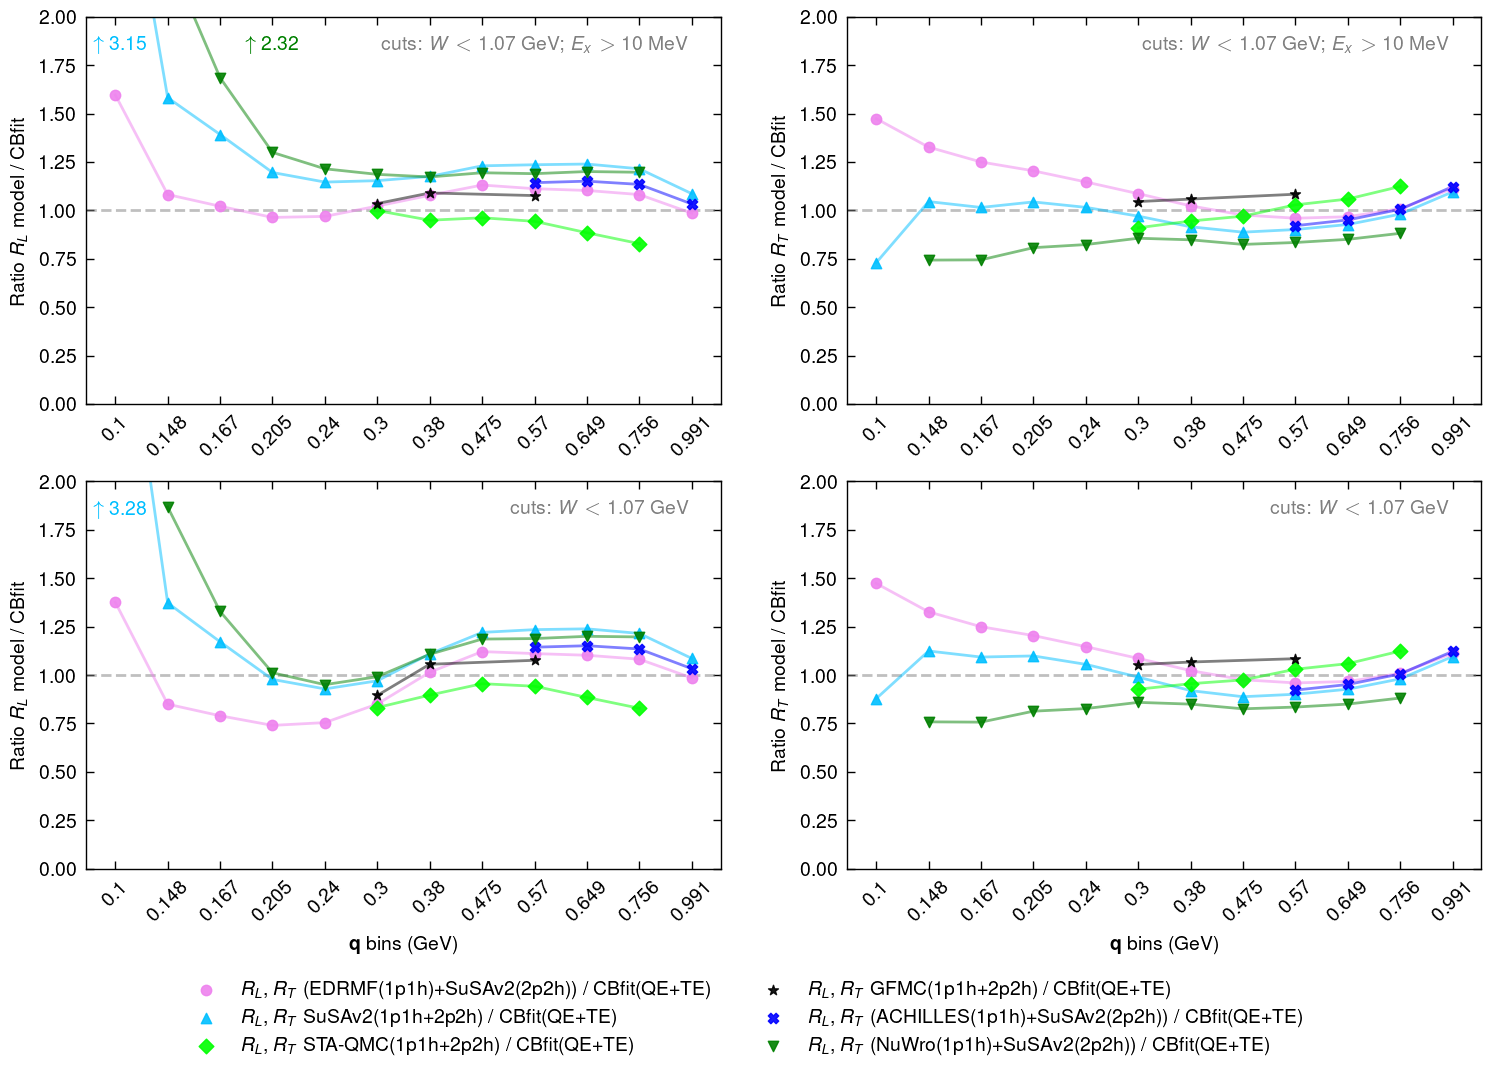

In [ ]:
# fig 40: ratio plot of models vs. CB fit
scatter_setting = {'s':14,
                #    'edgecolors':'gray',
                   'linewidth':0.5,
                   'zorder':3,'alpha':0.9}

fig, axs = plt.subplots(2, 2, figsize=(9, 6), dpi=200)

# cols = [['RL_EDRMF_ratio','RT_EDRMF_ratio','RL_SuSAv2_ratio','RT_SuSAv2_ratio','RL_NuWroSF_ratio','RT_NuWroSF_ratio','RL_ACHILLES_ratio','RT_ACHILLES_ratio'],
#         ['RL_EDRMFsusa_ratio','RT_EDRMFsusa_ratio','RL_SuSAv2_ratio','RT_SuSAv2_ratio','RL_STA_ratio','RT_STA_ratio','RL_GFMC_ratio','RT_GFMC_ratio']]

# A: 1p1h modesl        with Excut
# B: 1p1h modesl        no Excut
# C: 1p1h+2p2h modesl   with Excut
# D: 1p1h+2p2h modesl   no Excut




# sheets = ['A','B','C','D']
sheets = ['1p1h_2p2h_Excut','1p1h_2p2h_noExcut']
handles=[]
labels=[]
# for i in range(4):
for i in range(2):

    sheet = sheets[i]
    # df = pd.read_excel('Carbon/12C_plots/RLRT_PRD/RLRT_models_vs_CBfit.xlsx',sheet_name=sheets[i])
    df = pd.read_excel('Carbon/12C_plots/RLRT_PRD/RLRT_models_integrated.xlsx',sheet_name=sheets[i])
    df = df.loc[df['qvcenter']<1.0] # focus on smaller q bins
    


    df['qvcenter']=df['qvcenter'].astype(str)
    # df['qvcenter'] = df['qvcenter'].astype
    # put a line at y=1

    axs[i,0].axhline(y=1,color='gray',linestyle='--',alpha=0.5)
    axs[i,1].axhline(y=1,color='gray',linestyle='--',alpha=0.5)

    axs[i,0].scatter(df['qvcenter'], df['RL_EDRMFsusa']/df['RL_EDRMFsusa_cb'], label='$R_L, R_T$ (EDRMF(1p1h)+SuSAv2(2p2h)) / CBfit(QE+TE)', **scatter_setting,marker='o',color=susacolor)
    axs[i,0].scatter(df['qvcenter'], df['RL_SuSAv2']/df['RL_SuSAv2_cb'],label='$R_L, R_T$ SuSAv2(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='^',color='deepskyblue')
    axs[i,0].scatter(df['qvcenter'], df['RL_STA']/df['RL_STA_cb'], label='$R_L, R_T$ STA-QMC(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='D',color='lime')
    axs[i,0].scatter(df['qvcenter'], df['RL_GFMC']/df['RL_GFMC_cb'],label='$R_L, R_T$ GFMC(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='*',color='black')
    axs[i,0].scatter(df['qvcenter'], df['RL_ACHILLESsusa']/df['RL_ACHILLESsusa_cb'], label='$R_L, R_T$ (ACHILLES(1p1h)+SuSAv2(2p2h)) / CBfit(QE+TE)', **scatter_setting,marker='X',color='blue')
    axs[i,0].scatter(df['qvcenter'], df['RL_NUWROsusa']/df['RL_NUWROsusa_cb'], label='$R_L, R_T$ (NuWro(1p1h)+SuSAv2(2p2h)) / CBfit(QE+TE)', **scatter_setting,marker='v',color='green')


    df_gfmc=pd.read_excel('Carbon/12C_plots/RLRT_PRD/RLRT_models_integrated.xlsx',sheet_name=sheets[i])
    df_gfmc['qvcenter']=df_gfmc['qvcenter'].astype(str)
    df_gfmc = df_gfmc[['qvcenter','RT_GFMC','RT_GFMC_cb','RL_GFMC','RL_GFMC_cb']]
    df_gfmc = df_gfmc.dropna()
    

    axs[i,0].plot(df['qvcenter'], df['RL_EDRMFsusa']/df['RL_EDRMFsusa_cb'], color=susacolor,alpha=0.5)
    axs[i,0].plot(df['qvcenter'], df['RL_SuSAv2']/df['RL_SuSAv2_cb'],color='deepskyblue',alpha=0.5)
    axs[i,0].plot(df['qvcenter'], df['RL_STA']/df['RL_STA_cb'],color='lime',alpha=0.5)
    axs[i,0].plot(df_gfmc['qvcenter'], df_gfmc['RL_GFMC']/df_gfmc['RL_GFMC_cb'],color='black',alpha=0.5)
    axs[i,0].plot(df['qvcenter'], df['RL_ACHILLESsusa']/df['RL_ACHILLESsusa_cb'], color='blue',alpha=0.5)
    axs[i,0].plot(df['qvcenter'], df['RL_NUWROsusa']/df['RL_NUWROsusa_cb'],color='green',alpha=0.5)


    axs[i,1].scatter(df['qvcenter'], df['RT_EDRMFsusa']/df['RT_EDRMFsusa_cb'], **scatter_setting,marker='o',color=susacolor)
    axs[i,1].scatter(df['qvcenter'], df['RT_SuSAv2']/df['RT_SuSAv2_cb'],**scatter_setting,marker='^',color='deepskyblue')
    axs[i,1].scatter(df['qvcenter'], df['RT_STA']/df['RT_STA_cb'], **scatter_setting,marker='D',color='lime')
    axs[i,1].scatter(df['qvcenter'], df['RT_GFMC']/df['RT_GFMC_cb'],**scatter_setting,marker='*',color='black')
    axs[i,1].scatter(df['qvcenter'], df['RT_ACHILLESsusa']/df['RT_ACHILLESsusa_cb'], **scatter_setting,marker='X',color='blue')
    axs[i,1].scatter(df['qvcenter'], df['RT_NUWROsusa']/df['RT_NUWROsusa_cb'], **scatter_setting,marker='v',color='green')


    axs[i,1].plot(df['qvcenter'], df['RT_EDRMFsusa']/df['RT_EDRMFsusa_cb'],color=susacolor,alpha=0.5)
    axs[i,1].plot(df['qvcenter'], df['RT_SuSAv2']/df['RT_SuSAv2_cb'],color='deepskyblue',alpha=0.5)
    axs[i,1].plot(df['qvcenter'], df['RT_STA']/df['RT_STA_cb'], color='lime',alpha=0.5)
    axs[i,1].plot(df_gfmc['qvcenter'], df_gfmc['RT_GFMC']/df_gfmc['RT_GFMC_cb'],color='black',alpha=0.5)
    axs[i,1].plot(df['qvcenter'], df['RT_ACHILLESsusa']/df['RT_ACHILLESsusa_cb'], color='blue',alpha=0.5)
    axs[i,1].plot(df['qvcenter'], df['RT_NUWROsusa']/df['RT_NUWROsusa_cb'],color='green',alpha=0.5)



    # if sheet in ['A','B']:
    #     # plot ratios
    #     axs[i,0].scatter(df['qvcenter'], df['RL_EDRMF_ratio'], label='$R_L$ EDRMF(1p1h) / CBfit(QE)', **scatter_setting,marker='o', color='cornflowerblue')
    #     axs[i,0].scatter(df['qvcenter'], df['RL_SuSAv2_ratio'],label='$R_L$ SuSAv2(1p1h) / CBfit(QE)', **scatter_setting,marker='^',color=susacolor)
    #     axs[i,0].scatter(df['qvcenter'], df['RL_NuWroSF_ratio'], label='$R_L$ NuWro(1p1h) / CBfit(QE)', **scatter_setting,marker='v',color='green')
    #     axs[i,0].scatter(df['qvcenter'], df['RL_ACHILLES_ratio'],label='$R_L$ ACHILLES(1p1h) / CBfit(QE)', **scatter_setting,marker='X',color='blue')

    #     axs[i,1].scatter(df['qvcenter'], df['RT_EDRMF_ratio'], label='$R_T$ EDRMF(1p1h) / CBfit(QE)', **scatter_setting,marker='o',color='cornflowerblue')
    #     axs[i,1].scatter(df['qvcenter'], df['RT_SuSAv2_ratio'],label='$R_T$ SuSAv2(1p1h) / CBfit(QE)', **scatter_setting,marker='^',color=susacolor)
    #     axs[i,1].scatter(df['qvcenter'], df['RT_NuWroSF_ratio'], label='$R_T$ NuWro(1p1h) / CBfit(QE)', **scatter_setting,marker='v',color='green')
    #     axs[i,1].scatter(df['qvcenter'], df['RT_ACHILLES_ratio'],label='$R_T$ ACHILLES(1p1h) / CBfit(QE)', **scatter_setting,marker='X',color='blue')

    # else:
    #     axs[i,0].scatter(df['qvcenter'], df['RL_EDRMFsusa_ratio'], label='$R_L$ (EDRMF(1p1h) + SuSAv2(2p2h)) / CBfit(QE)', **scatter_setting,marker='p',color=susacolor)
    #     axs[i,0].scatter(df['qvcenter'], df['RL_SuSAv2_ratio'],label='$R_L$ SuSAv2(1p1h+2p2h) / CBfit(QE)', **scatter_setting,marker='s',color='deepskyblue')
    #     axs[i,0].scatter(df['qvcenter'], df['RL_STA_ratio'], label='$R_L$ STA-QMC(1p1h+2p2h) / CBfit(QE)', **scatter_setting,marker='D',color='lime')
    #     axs[i,0].scatter(df['qvcenter'], df['RL_GFMC_ratio'],label='$R_L$ GFMC(1p1h+2p2h) / CBfit(QE)', **scatter_setting,marker='*',color='red')

    #     axs[i,1].scatter(df['qvcenter'], df['RT_EDRMFsusa_ratio'], label='$R_T$ (EDRMF(1p1h) + SuSAv2(2p2h)) / CBfit(QE+TE)', **scatter_setting,marker='p',color=susacolor)
    #     axs[i,1].scatter(df['qvcenter'], df['RT_SuSAv2_ratio'],label='$R_T$ SuSAv2(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='s',color='deepskyblue')
    #     axs[i,1].scatter(df['qvcenter'], df['RT_STA_ratio'], label='$R_T$ STA-QMC(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='D',color='lime')
    #     axs[i,1].scatter(df['qvcenter'], df['RT_GFMC_ratio'],label='$R_T$ GFMC(1p1h+2p2h) / CBfit(QE+TE)', **scatter_setting,marker='*',color='red')




    # axs[i,0].legend(frameon=True)
    # axs[i,1].legend(frameon=True)


    axs[i,0].set_ylabel("Ratio $R_L$ model / CBfit")
    axs[i,1].set_ylabel("Ratio $R_T$ model / CBfit")

    axs[i,0].minorticks_off()
    axs[i,0].tick_params(axis="x", labelrotation=45)
    axs[i,1].minorticks_off()
    axs[i,1].tick_params(axis="x", labelrotation=45)
    axs[i,0].set_ylim(0,2)
    axs[i,1].set_ylim(0,2)
    # axs[i,0].set_ylim(-0.5,2)
    # axs[i,1].set_ylim(-0.5,2)

    if i == 0:
        axs[i,0].text(0.01, 0.95,'$\\uparrow$ 3.15',transform=axs[i,0].transAxes,ha='left',va='top',color='deepskyblue')
        axs[i,0].text(0.25, 0.95,'$\\uparrow$ 2.32',transform=axs[i,0].transAxes,ha='left',va='top',color='green')
        # top right generic text
        axs[i,0].text(0.95, 0.95,'cuts: $W<$ 1.07 GeV; $E_x>$ 10 MeV',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,'cuts: $W<$ 1.07 GeV; $E_x>$ 10 MeV',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')
    elif i == 1:
        axs[i,0].text(0.01, 0.95,'$\\uparrow$ 3.28',transform=axs[i,0].transAxes,ha='left',va='top',color='deepskyblue')
        # top right generic text
        axs[i,0].text(0.95, 0.95,'cuts: $W<$ 1.07 GeV',transform=axs[i,0].transAxes,ha='right',va='top',color='gray')
        axs[i,1].text(0.95, 0.95,'cuts: $W<$ 1.07 GeV',transform=axs[i,1].transAxes,ha='right',va='top',color='gray')



    # collect handles and labels:
    h, l = axs[i,0].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    h, l = axs[i,1].get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)

unique_handles = []
unique_labels = []
for label in labels:
    if label == '$R_T$(total) Christy-Bodek-2024 ($Q^2$ = 0.001 GeV$^2$)':
        continue
    if label not in unique_labels:
        unique_labels.append(label)
        unique_handles.append(handles[labels.index(label)])



plt.subplots_adjust(bottom=0.17)

fig.legend(unique_handles, unique_labels, loc='lower center', ncol=2,frameon=False)


axs[1,0].set_xlabel('$\mathbf{q}$ bins (GeV)')
axs[1,1].set_xlabel('$\mathbf{q}$ bins (GeV)')


# plt.tight_layout()
plt.show()

with PdfPages('Carbon/12C_plots/RLRT_PRD/fig40.pdf') as pdf:
    pdf.savefig(fig)




In [81]:
# # plot Low Q2
# Q2center=0.01

# # with QD column
# ChristyBodekFit = pd.read_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2center}_withQD.csv',index_col = False)
# ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS','QD']

# # # with no QD column
# # ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/fine_resolution/Q2edges/'+f'Q2edge_{Q2center}.csv',index_col = False)
# # ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
# # ChristyBodekFit['QD'] = RT_quasi_deuteron(nus=ChristyBodekFit['nu'],q2s=ChristyBodekFit['q2'],exs=ChristyBodekFit['ex'])
# # ChristyBodekFit['RT'] = ChristyBodekFit['RT'] + ChristyBodekFit['QD'] # add quasi-deuteron contribution to RT
# for key in ['RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS','QD']:
#     ChristyBodekFit[key] = ChristyBodekFit[key]*1e3  # convert to GeV^-1
# # ChristyBodekFit['RL'] = ChristyBodekFit['RL'] - ChristyBodekFit['RLIE'] # remove the inelastic part
# # ChristyBodekFit['RT'] = ChristyBodekFit['RT'] - ChristyBodekFit['RTIE'] # remove the inelastic part

# plt.figure(figsize=(6,4),dpi=200)
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['RT'],label='RT total',alpha=0.5)
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['RTE'],label='RTE')
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['RTQE'],label='RTQE')
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['RTIE'],label='RTIE',linestyle='dotted')
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['RTNS'],label='RTNS',linestyle='-.')
# plt.plot(ChristyBodekFit['nu'],ChristyBodekFit['QD'],label='QD',linestyle='--')

# Photon_plotting = pd.read_excel("Carbon/12C_other_extractions/photo-production/Photon_plotting.xlsx")
# Photon_plotting = Photon_plotting.sort_values(by=['nu'])
# Photon_plotting = Photon_plotting.reset_index(drop=True)
# Photon_plotting['RT'] = Photon_plotting['RT']*1e3

# # axs[i,1].plot(Photon_plotting['nu'],Photon_plotting["RT"],color='gray',lw=1, zorder=-2)
# plt.scatter(Photon_plotting['nu'],Photon_plotting["RT"],label="$R_T$ Photo-production ($Q^2$ = 0 GeV$^2$)",
#                     s=10,color='lime',marker='^',edgecolors='gray',linewidth=0.5,zorder=1)




# W_peak=1.14
# nu_W = 0.025 + (W_peak**2+Q2center-mass_nucleon**2)/(2*mass_nucleon)
# plt.axvline(x=nu_W,linestyle='-.',label=f'W={W_peak}')
# # np.sqrt(qvcenter**2 + 1.07**2) - mass_nucleon
# # W2 = M2 + 2*M*nu - Q2
# # nu = (W2 - M2 + Q2) / (2 * M)
# plt.legend()
# plt.xlim(0,0.42)
# plt.ylim(0,40)
# plt.xlabel('$\\nu$ (GeV)')
# plt.ylabel('$R_T$ (GeV$^{-1}$)')
# plt.show()

In [32]:
# collect RLRT extracted values into spreadsheets
df_fits = []
for qvcenter in qvcenters:
    df_fits.append(pd.read_csv(f'Carbon/12C_plots/extracted_values/RLRT_q_{qvcenter}.csv'))
df_fits = pd.concat(df_fits, ignore_index=True)
df_fits.to_csv('Carbon/12C_plots/extracted_values/RLRT_q_bins.csv',index=False)

df_fits = []
for Q2center in Q2centers:
    df_fits.append(pd.read_csv(f'Carbon/12C_plots/extracted_values/RLRT_Q2_{Q2center}.csv'))
df_fits = pd.concat(df_fits, ignore_index=True)
df_fits.to_csv('Carbon/12C_plots/extracted_values/RLRT_Q2_bins.csv',index=False)


In [ ]:
# # (uncomment when use) collect RLRT CB fit values into spreadsheets

# df_fits = []
# for Q2center in Q2centers:
#     ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Q2edges/'+f'Q2edge_{Q2center}.csv',index_col = False)
#     # ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
#     ChristyBodekFit.columns = ['q (GeV)','Q^2 (GeV^2)','Ex (GeV)','nu (GeV)','RT (GeV^-1)','RL (GeV^-1)','RTQE (GeV^-1)','RLQE (GeV^-1)',
#                                'RTIE (GeV^-1)','RLIE (GeV^-1)','RTE (GeV^-1)','RLE (GeV^-1)','RTNS (GeV^-1)','RLNS (GeV^-1)']
#     for key in ['RT (GeV^-1)','RL (GeV^-1)','RTQE (GeV^-1)','RLQE (GeV^-1)',
#             'RTIE (GeV^-1)','RLIE (GeV^-1)','RTE (GeV^-1)','RLE (GeV^-1)','RTNS (GeV^-1)','RLNS (GeV^-1)']:
#         ChristyBodekFit[key] = ChristyBodekFit[key] * 1e3
#     df_fits.append(ChristyBodekFit)
# df_fits = pd.concat(df_fits, ignore_index=True)
# df_fits.to_csv('Carbon/12C_plots/extracted_values/RLRT_Christy-Bodek-2024_Q2_bins.csv',index=False,float_format='%.5g')


# df_fits = []
# for qvcenter in qvcenters:
#     ChristyBodekFit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/'+f'Qvedge_{qvcenter}.csv',index_col = False)
#     # ChristyBodekFit.columns = ['qv','q2','ex','nu','RT','RL','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
#     ChristyBodekFit.columns = ['q (GeV)','Q^2 (GeV^2)','Ex (GeV)','nu (GeV)','RT (GeV^-1)','RL (GeV^-1)','RTQE (GeV^-1)','RLQE (GeV^-1)',
#                                'RTIE (GeV^-1)','RLIE (GeV^-1)','RTE (GeV^-1)','RLE (GeV^-1)','RTNS (GeV^-1)','RLNS (GeV^-1)']
#     for key in ['RT (GeV^-1)','RL (GeV^-1)','RTQE (GeV^-1)','RLQE (GeV^-1)',
#             'RTIE (GeV^-1)','RLIE (GeV^-1)','RTE (GeV^-1)','RLE (GeV^-1)','RTNS (GeV^-1)','RLNS (GeV^-1)']:
#         ChristyBodekFit[key] = ChristyBodekFit[key] * 1e3
#     df_fits.append(ChristyBodekFit)
# df_fits = pd.concat(df_fits, ignore_index=True)
# df_fits.to_csv('Carbon/12C_plots/extracted_values/RLRT_Christy-Bodek-2024_q_bins.csv',index=False,float_format='%.5g')


In [ ]:
# plot XSec, compare with datasets, CBfit, SuSAv2 / GENIE
# title: Suppl materials Comparison of Carbon 
# Ryan fix Ex
# RLRT points
# spreadsheet 
# prepare df, df sigtot:
# df = pd.read_csv('Carbon/12C_data_raw/12C-25July6.csv')
# df = pd.read_csv('Carbon/12C_data_raw/12C-25July25-plotting.csv')
df = pd.read_csv('Carbon/12C_data_raw/12C-25Aug7-plotting-Ricco-Zeller.csv')
# df = df.loc[df['dataSet']!=6] # drop Dai
# df = df.loc[df['dataSet']!=25] # drop e4nu 
df = prepare_df(df_data=df)
df['E0']=df['E0original']

print(len(df))

# E0, Theta fortran inputs
inputs = []
for dataSet in np.sort(df['dataSet'].unique()):
    df_author = df.loc[df['dataSet'] == dataSet]
    # df_author = df_author.loc[df_author['Ex'] > 0.03]
    for E0 in np.sort(df_author['E0'].unique()):
        df_E0 = df_author.loc[df_author['E0'] == E0]
        for ThetaDeg in np.sort(df_E0['ThetaDeg'].unique()):
            inputs.append((dataSet, E0, ThetaDeg))
print(len(inputs))





# plotting:_____________________________________________________________________________________

# df_susa = pd.read_csv('Carbon/12C_theory_predictions/SuSAv2/12C_susa_25July25_plotting.csv')
df_susa = pd.read_csv('Carbon/12C_theory_predictions/SuSAv2/12C_susa.csv')

df_susa = df_susa[['A','Z','E0','nu','ThetaDeg','cross']]
df_genie=pd.read_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv')
qemodplot_columns = ['e','nu','ep','theta','nu-nuel','w2','q2','sigtot','sigqe','sigie','sigmec','nuccstot','signonuc']


# which version of fit?
# fit_folder = 'Carbon/Eric/response-25July28/'
fit_folder = 'Carbon/Eric/cscompqe-25June10/'


count=0
# with PdfPages('C12paper_figures/data_vs_fit_Xsec.pdf') as pdf:
with PdfPages('Carbon/12C_plots/SuSAv2_XSec_12C_oldfit.pdf') as pdf:
# with PdfPages('Carbon/12C_plots/SuSAv2_XSec_12C_25July28_newfit.pdf') as pdf:

    for i in range(15): # 修改这个数，取决画多少页
        fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(12, 12), dpi=200) 
        if i == 0:
            fig.suptitle('Supplementary Materials: Comparison of Carbon cross-section data with Christy-Bodek-2024 fit and SuSAv2',fontsize=14,y=1.0)
        for j, ax in enumerate(axs.flat):
            if i*12+j >= len(inputs): #每页画12个图
                # ax.set_visible(False)
                # break
                continue
            dataSet, E0, ThetaDeg, = inputs[i*12+j]
            if dataSet in [16,27]:
                qemod_program = f'{fit_folder}qemodplot_yam_res' # smwidth=0.00048
            elif dataSet == 1:
                # if E0 <=  0.1597:
                #     qemod_program = f'{fit_folder}qemodplot_norm' # smwidth=0.001
                # else:
                qemod_program = f'{fit_folder}qemodplot_bar_res' # smwidth=0.02
            else:
                # qemod_program = 'Carbon/Eric/cscompqe-25June10/qemodplot_norm'
                qemod_program = f'{fit_folder}qemodplot_norm' # smwidth=0.001


            # # plot against nu



            # datasets
            df_theta = df.loc[(df['dataSet']==dataSet)&(df['E0'] == E0)&(df['ThetaDeg'] == ThetaDeg)].copy()
            # df_theta = df_theta.loc[df_theta['Ex'] > 0.03]
            df_theta = df_theta.sort_values(by='nu')
            if dataSet in [6,25,27,28]:
                dataSet_label = f'{dataSet_to_name[dataSet]}\n($\\times${dataSet_to_normalization[dataSet]}; not used)'
            else:
                dataSet_label = f'{dataSet_to_name[dataSet]}\n($\\times${dataSet_to_normalization[dataSet]})'

            ax.errorbar(df_theta['nu'], df_theta['normCross'], yerr=df_theta['normCrossError'], fmt='.', markersize=3, 
                        # label=f'$E_0=${E0}$GeV$\n$\\theta=${ThetaDeg}°', 
                        # label = f'{dataSet_to_name[dataSet]}\n($\\times${dataSet_to_normalization[dataSet]})',
                        label = dataSet_label,
                        color='blue',alpha=0.5)


            # SuSA
            # ax.errorbar(df_susa['nu'], df_susa['normCross'], yerr=df_theta['normCrossError'], fmt='.', label=f'$E_0=${E0}$GeV$\n$\\theta=${ThetaDeg}°', color='blue',zorder=-1)
            df_susa_theta = df_susa.loc[(df_susa['E0'] == E0)&(df_susa['ThetaDeg'] == ThetaDeg)].copy()
            df_susa_theta = df_susa_theta.sort_values(by='nu')
            if len(df_susa_theta) > 0:
                ax.errorbar(df_susa_theta['nu'], df_susa_theta['cross'],  fmt='.', markersize=3, label=f'SuSAv2', color='limegreen',zorder=-1,alpha=0.5)
                ax.plot(df_susa_theta['nu'], df_susa_theta['cross'], color='green',zorder=-1,alpha=0.5)
            
            # GENIE
            df_genie_theta = df_genie.loc[(df_genie['E0'] == E0)&(df_genie['ThetaDeg'] == ThetaDeg)].copy()
            df_genie_theta = df_genie_theta.sort_values(by='nu')
            if len(df_genie_theta) > 0:
                ax.errorbar(df_genie_theta['nu'], df_genie_theta['cross']/1000,  fmt='.', markersize=3, label=f'GENIE', color='purple',zorder=-1)
                ax.plot(df_genie_theta['nu'], df_genie_theta['cross']/1000, color='purple',zorder=-1,alpha=0.5)


            # CB fit, full nu range
            if not df_genie_theta.empty:
                nu_max = max(df_genie_theta['nu'].max(),df_theta['nu'].max())
            else:
                nu_max = df_theta['nu'].max()
            
            nurange = nu_max-df_theta['nu'].min()
            # df_CB_fullrange = pd.DataFrame({'nu':np.linspace(df_theta['nu'].min(),df_theta['nu'].max(),200)})
            # df_CB_fullrange = pd.DataFrame({'nu':np.linspace(df_theta['nu'].min()-0.05*nurange,df_theta['nu'].max()+0.05*nurange,200)})
            df_CB_fullrange = pd.DataFrame({'nu':np.linspace(max(df_theta['nu'].min()-0.01, 0.0),nu_max+0.05*nurange,200)})

            
            df_CB_fullrange['E0']=E0
            df_CB_fullrange['ThetaDeg']=ThetaDeg
            df_CB_fullrange[['E0','ThetaDeg','nu']].to_csv('Carbon/input.txt',index=False,header=False,sep=' ')
            with open('Carbon/output.txt', 'w') as output_file:
                subprocess.run([qemod_program, 'Carbon/input.txt'], stdout=output_file)
            subprocess.run(['sleep', '0.1'])
            df_CB_fullrange = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=qemodplot_columns)
            df_CB_fullrange = df_CB_fullrange.loc[df_CB_fullrange['nu']>=0]
            # 'sigtot','sigqe','sigie','sigmec','nuccstot','signonuc'
            ax.plot(df_CB_fullrange['nu'], df_CB_fullrange['sigtot']*12*1e3, color='red', alpha=0.8,zorder=-1,label=f'CB-2024 total')
            ax.plot(df_CB_fullrange['nu'], df_CB_fullrange['sigqe']*12*1e3, color='gold', alpha=0.8,zorder=-1,label=f'CB-2024 QE')
            ax.plot(df_CB_fullrange['nu'], df_CB_fullrange['sigie']*12*1e3, color='cornflowerblue', alpha=0.8,zorder=-1,label=f'CB-2024 inelastic')
            ax.plot(df_CB_fullrange['nu'], df_CB_fullrange['sigmec']*12*1e3, color='aqua', alpha=0.8,zorder=-1,label=f'CB-2024 MEC')
            ax.plot(df_CB_fullrange['nu'], df_CB_fullrange['nuccstot']*12*1e3, color='violet', alpha=0.8,zorder=-1,label=f'CB-2024 states')



            # # compute df sigtot at nu
            # df_theta[['E0','ThetaDeg','nu']].to_csv('Carbon/input.txt',index=False,header=False,sep=' ')
            # with open('Carbon/output.txt', 'w') as output_file:
            #     subprocess.run([qemod_program, 'Carbon/input.txt'], stdout=output_file) 
            # subprocess.run(['sleep', '0.1'])
            # df_CB = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=qemodplot_columns)
            # df_CB=df_CB.sort_values(by='nu')
            # ax.errorbar(df_CB['nu'], df_CB['sigtot']*12*1e3,  fmt='.', markersize=3, color='red',alpha=0.5,zorder=-1)

            


            ax.set_xlabel('$\\nu \ (GeV)$')    
            # ax.set_xlim(0,None)
            ax.set_ylabel('$\\frac{d^2 \sigma}{d\Omega d\\nu} (nb/sr/GeV)$')
            ax.set_ylim(0,None)
            # ax.set_title(f'{dataSet}: {dataSet_to_name[dataSet]} ($\\times${dataSet_to_normalization[dataSet]})')
            ax.set_title(f'$E_0$ = {E0} $GeV$, $\\theta$ = {ThetaDeg}°, Carbon')
 


            formatter = ScalarFormatter(useMathText=True)
            formatter.set_scientific(True)
            formatter.set_powerlimits((0,0))
            ax.yaxis.set_major_formatter(formatter)
            ax.legend(frameon=True,fontsize=6)
        # plt.show()

        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)


In [ ]:
# # (uncomment when use) generate df_CB 12C fake data

# qemodplot_columns = ['e','nu','ep','theta','nu-nuel','w2','q2','sigtot','sigqe','sigie','sigmec','nuccstot','signonuc']
# # df.loc[df['Ex']>0.05]
# pd.read_csv('Carbon/12C_data_raw/12C-25June11.csv')[['E0','ThetaDeg','nu']].to_csv('Carbon/input.txt',index=False,header=False,sep=' ')
# with open('Carbon/output.txt', 'w') as output_file:
#     subprocess.run(['Carbon/Eric/cscompqe-25June10/qemodplot_norm', 'Carbon/input.txt'], stdout=output_file) 
# subprocess.run(['sleep', '0.5'])
# df_CB = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=qemodplot_columns)
# df_CB['cross']=df_CB['sigtot']*12*1e3
# df_CB['E0']=df_CB['e']
# df_CB['ThetaDeg']=df_CB['theta']
# df_CB['A']=12
# df_CB['Z']=6
# df_CB=df_CB[['A','Z','E0','nu','ThetaDeg','cross']]
# df_CB = prepare_df(df_data=df_CB,coulomb=0.0)
# df_CB = calculate_bc(df_CB)
# df_CB

In [ ]:
# # (uncomment when use) plot Q2bins, qvbins: df_CB

# with PdfPages('Carbon/12C_plots/CBfit_Q2bin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_Q2bin(df=df_CB,bin_indices=bin_indices,absolute_sigma=False,bc=True)
#         pdf.savefig(fig)

# with PdfPages('Carbon/12C_plots/CBfit_qvbin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_qvbin(df=df_CB,bin_indices=bin_indices,absolute_sigma=False,bc=True)
#         pdf.savefig(fig)



In [ ]:
# # (uncomment when use) RLRT df_susa 12C
# df_susa = pd.read_csv('Carbon/12C_theory_predictions/SuSAv2/12C_susa.csv')
# df_susa = df_susa[['A','Z','E0','nu','ThetaDeg','cross']]
# df_susa = prepare_df(df_data=df_susa,coulomb=0.0)
# df_susa = calculate_bc(df_susa)
# df_susa=df_susa.dropna()
# df_susa


# # plot Q2bins, qvbins: df_susa

# with PdfPages('Carbon/12C_plots/SuSAv2_Q2bin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_Q2bin(df=df,df_susa=df_susa,bin_indices=bin_indices,absolute_sigma=False,bc=True,Yamaguchi_plot=False,SuSAv2_plot=True)
#         pdf.savefig(fig)

# with PdfPages('Carbon/12C_plots/SuSAv2_qvbin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_qvbin(df=df,df_susa=df_susa,bin_indices=bin_indices,absolute_sigma=False,bc=True,Yamaguchi_plot=False,SuSAv2_plot=True)
#         pdf.savefig(fig)



In [ ]:
# # (uncomment when use) RLRT df_genie 12C
# df_genie = pd.read_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv')
# df_genie = df_genie[['A','Z','E0','nu','ThetaDeg','cross','error']]
# df_genie = prepare_df(df_data=df_genie,coulomb=0.0)
# df_genie = calculate_bc(df_genie)
# df_genie=df_genie.dropna()
# df_genie
# df_genie[['E0','ThetaDeg','nu']].to_csv('Carbon/input.txt',index=False,header=False,sep=' ')
# with open('Carbon/output.txt', 'w') as output_file:
#     subprocess.run(['Carbon/Eric/cscompqe-25June10/qemodplot_norm', 'Carbon/input.txt'], stdout=output_file) 
# subprocess.run(['sleep', '0.5'])
# df_CB = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=qemodplot_columns)
# print('len df_CB df_genie:',len(df_CB),len(df_genie))
# df_genie['sigtot']=df_CB['sigtot']*12*1e3

# # plot Q2bins, qvbins: df_genie

# with PdfPages('Carbon/12C_plots/GENIE_Q2bin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_Q2bin(df=df_genie,bin_indices=bin_indices,absolute_sigma=True,bc=True)
#         pdf.savefig(fig)

# with PdfPages('Carbon/12C_plots/GENIE_qvbin.pdf') as pdf:
#     plot_indeices = [[0,1,2,3,4],[5,6,7,8,9],[10,11,12,13,14],[15,16,17]]
#     for bin_indices in plot_indeices:
#         fig=RLRT_plot_qvbin(df=df_genie,bin_indices=bin_indices,absolute_sigma=True,bc=True)
#         pdf.savefig(fig)



In [ ]:
# # (uncommment when use) plot Xsec at specific energy
# qemod_program = f'{fit_folder}qemodplot_yam_res' # smwidth=0.00048

# for ThetaDeg, E0 in [(60,0.1025),(155,0.06),(155,0.071),(155,0.082),(155,0.1)]:
#     df_CB_fullrange = pd.DataFrame({'nu':np.linspace(0.02,0.04,200)})
#     plt.figure(figsize=(4,3),dpi=200)
#     df_CB_fullrange['E0']=E0
#     df_CB_fullrange['ThetaDeg']=ThetaDeg
#     df_CB_fullrange[['E0','ThetaDeg','nu']].to_csv('Carbon/input.txt',index=False,header=False,sep=' ')
#     with open('Carbon/output.txt', 'w') as output_file:
#         subprocess.run([qemod_program, 'Carbon/input.txt'], stdout=output_file)
#     subprocess.run(['sleep', '0.1'])
#     df_CB_fullrange = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=qemodplot_columns)
#     df_CB_fullrange = df_CB_fullrange.loc[df_CB_fullrange['nu']>=0]
#     # 'sigtot','sigqe','sigie','sigmec','nuccstot','signonuc'
#     plt.plot(df_CB_fullrange['nu-nuel'], df_CB_fullrange['sigtot']*12*1e3*1e-36, color='red', alpha=0.8,zorder=-1,label=f'CB-2024 total')
#     plt.plot(df_CB_fullrange['nu-nuel'], df_CB_fullrange['sigqe']*12*1e3*1e-36, color='gold', alpha=0.8,zorder=-1,label=f'CB-2024 QE')
#     plt.plot(df_CB_fullrange['nu-nuel'], df_CB_fullrange['sigie']*12*1e3*1e-36, color='cornflowerblue', alpha=0.8,zorder=-1,label=f'CB-2024 inelastic')
#     plt.plot(df_CB_fullrange['nu-nuel'], df_CB_fullrange['sigmec']*12*1e3*1e-36, color='aqua', alpha=0.8,zorder=-1,label=f'CB-2024 MEC')
#     plt.plot(df_CB_fullrange['nu-nuel'], df_CB_fullrange['nuccstot']*12*1e3*1e-36, color='violet', alpha=0.8,zorder=-1,label=f'CB-2024 states')
#     plt.legend()
#     plt.xlabel('Ex(GeV)')
#     plt.ylabel('cross-section')
#     plt.title(f'theta={ThetaDeg} E0={E0}')
#     plt.show()
# # 1 nb = 10^-33 cm^2
# # nb/sr/GeV = 10^-33 cm^2 /sr /(1000 MeV) = 10^-36 cm^2/sr/MeV


In [ ]:
# # (uncomment when use ) plot XSec, comparison with datasets, CBfit, GENIE

# df_genie=pd.read_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv')

# count=0
# # with PdfPages('C12paper_figures/data_vs_fit_Xsec.pdf') as pdf:
# with PdfPages('Carbon/12C_plots/GENIE_SuSA_12C_Xsec.pdf') as pdf:

#     for i in range(17): # 修改这个数，取决画多少页
#         fig, axs = plt.subplots(ncols=3, nrows=4, figsize=(20, 20), dpi=200) 
#         for j, ax in enumerate(axs.flat):
#             if i*12+j >= len(inputs): #每页画12个图
#                 break
#             dataSet, E0, ThetaDeg, = inputs[i*12+j]
#             df_theta = df.loc[(df['dataSet']==dataSet)&(df['E0'] == E0)&(df['ThetaDeg'] == ThetaDeg)]
#             # df_theta = df_theta.loc[df_theta['Ex'] > 0.03]
#             df_theta = df_theta.sort_values(by='nu')

#             # # plot against nu
#             ax.errorbar(df_theta['nu'], df_theta['normCross'], yerr=df_theta['normCrossError'], fmt='.', markersize=5, label=f'$E_0=${E0}$GeV$\n$\\theta=${ThetaDeg}°', color='blue',zorder=-1)
#             ax.scatter(df_theta['nu'], df_theta['sigtot'], label='Christy-Bodek Fit', color='red',marker='.',s=5)
#             ax.plot(df_theta['nu'], df_theta['sigtot'], color='red', alpha=0.5)


#             # ax.errorbar(df_susa['nu'], df_susa['normCross'], yerr=df_theta['normCrossError'], fmt='.', label=f'$E_0=${E0}$GeV$\n$\\theta=${ThetaDeg}°', color='blue',zorder=-1)
#             df_susa_theta = df_susa.loc[(df_susa['E0'] == E0)&(df_susa['ThetaDeg'] == ThetaDeg)]
#             ax.errorbar(df_susa_theta['nu'], df_susa_theta['cross'],  fmt='.', markersize=5, label=f'SuSAv2', color='limegreen',zorder=-1)
#             ax.plot(df_susa_theta['nu'], df_susa_theta['cross'], color='limegreen',zorder=-1,alpha=0.5)
            

#             df_genie_theta = df_genie.loc[(df_genie['E0'] == E0)&(df_genie['ThetaDeg'] == ThetaDeg)]
#             ax.errorbar(df_genie_theta['nu'], df_genie_theta['cross']/1000,  fmt='.', markersize=5, label=f'GENIE', color='purple',zorder=-1)
#             ax.plot(df_genie_theta['nu'], df_genie_theta['cross']/1000, color='purple',zorder=-1,alpha=0.5)

#             ax.set_xlabel('$\\nu \ (GeV)$')    
#             ax.set_ylabel('$\\frac{d^2 \sigma}{d\Omega d\\nu} (nb/sr/GeV)$')
#             ax.set_ylim(0,None)
#             ax.set_title(f'{dataSet}: {dataSet_to_name[dataSet]} ($\\times${dataSet_to_normalization[dataSet]})')

#             formatter = ScalarFormatter(useMathText=True)
#             formatter.set_scientific(True)
#             formatter.set_powerlimits((0,0))
#             ax.yaxis.set_major_formatter(formatter)
#             ax.legend()
#         # plt.show()
#         plt.tight_layout()
#         pdf.savefig(fig)
#         plt.close(fig)


In [ ]:
# # (uncomment when use) calculate CB Q2edges, Qvedges; make sure you have the correct smwidth!
# # 25 Sep 22: make sure to add QD contribution!
def calculate_CB_Q2edges(Q2):
    # df = pd.DataFrame({'nu':np.arange(0.0,3.5,0.001)})
    df = pd.DataFrame({'nu':np.arange(0.0,0.65,0.0005)
                    #    np.append(np.arange(0.0,0.0299,0.0001),np.arange(0.030,0.6,0.001))
                       })
    df['q2']=Q2
    response_columns = ['qv','q2','ex','nu','RTTOT','RLTOT','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
    df[['q2','nu']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
    with open('Carbon/output.txt', 'w') as output_file:
        # subprocess.run(['Carbon/Eric/response-25Sept24/response_Q2edges', 'Carbon/input.txt'], stdout=output_file) 
        subprocess.run(['Carbon/Eric/response-25June10/response_Q2edges', 'Carbon/input.txt'], stdout=output_file) 
    subprocess.run(['sleep', '0.5'])
    df = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)

    # 25 Sep 22: add quasi deuteron contribution
    df['QD']=RT_quasi_deuteron(nus=df['nu'], q2s = df['q2'], exs = df['ex']) 
    df['RTTOT'] = df['RTTOT'] + df['QD']

    df=df.dropna()
    return df

# def calculate_CB_Qvedges(qv):
#     # df = pd.DataFrame({'nu':np.arange(0.0,qv,0.001)})
#     df = pd.DataFrame({'nu':np.append(np.arange(0.0,0.0299,0.0001),np.arange(0.030,qv,0.001))})
#     df['qv']=qv
#     response_columns = ['qv','q2','ex','nu','RTTOT','RLTOT','RTQE','RLQE','RTIE','RLIE','RTE','RLE','RTNS','RLNS']
#     df[['qv','nu']].to_csv('Carbon/input.txt',index=True,header=False,sep=' ')
#     with open('Carbon/output.txt', 'w') as output_file:
#         subprocess.run(['Carbon/Eric/response-25June10/response_Qvedges', 'Carbon/input.txt'], stdout=output_file) 
#     subprocess.run(['sleep', '0.5'])
#     df = pd.read_csv('Carbon/output.txt', sep='\s+', header=None, names=response_columns)
#     df=df.dropna()
#     return df

# # for all bins
# for Q2 in Q2centers:
#     df_edges=calculate_CB_Q2edges(Q2)
#     df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2}.csv',index=False)
# for Q2 in Q2bins:
#     df_edges=calculate_CB_Q2edges(Q2)
#     df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2}.csv',index=False)

# for qv in qvcenters:
#     df_edges=calculate_CB_Qvedges(qv)
#     df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qv}.csv',index=False)

# for qv in qvbins:
#     df_edges=calculate_CB_Qvedges(qv)
#     df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qv}.csv',index=False)


# # for q<=0.3, Q2 <= 0.1: use finer smwidth 
# for Q2 in Q2centers:
#     if Q2 <= 0.1:
#         df_edges=calculate_CB_Q2edges(Q2)
#         df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2}.csv',index=False)
# for Q2 in Q2bins:
#     if Q2 <= 0.1:
#         df_edges=calculate_CB_Q2edges(Q2)
#         df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2}.csv',index=False)
# for qv in qvcenters:
#     if qv <= 0.3:
#         df_edges=calculate_CB_Qvedges(qv)
#         df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qv}.csv',index=False)
# for qv in qvbins:
#     if qv <= 0.3:
#         df_edges=calculate_CB_Qvedges(qv)
#         df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qv}.csv',index=False)


# a special line at Q2=0.001, 0.0001
for Q2 in [0.01, 0.001,0.0001, 0.005]:
    df_edges=calculate_CB_Q2edges(Q2)
    df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Q2edges/Q2edge_{Q2}_withQD.csv',index=False)


In [ ]:
# # (uncomment when use) (test responseq plot)
# qvcenter = 0.167
# for qv in [qvcenter]:
#     df_edges=calculate_CB_Qvedges(qv)
#     df_edges.to_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qv}.csv',index=False)
# CBfit = pd.read_csv(f'Carbon/Eric/ChristyBodekFit/Fine_resolution/Qvedges/Qvedge_{qvcenter}.csv')
# plt.plot(CBfit['nu'],CBfit['RLTOT'])
# CBfit = pd.read_csv(f'Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_{qvcenter}.csv')
# plt.plot(CBfit['nu'],CBfit['RLTOT'])


In [ ]:
# # (uncomment when use) save extracted RLRT to file
# df_ours = pd.DataFrame()
# for i in range(len(qvcenters)):

#     qvcenter = qvcenters[i]
#     fit = pd.concat([RLRT_extract_q2_ex(df,bin_index=i,bc=True,absolute_sigma=True),
#                         RLRT_extract_q2_w2(df,bin_index=i,bc=True,absolute_sigma=True)])

#     if i in [1,2,3,4,5]:
#         # for Yama_qvcenter in [0.148,0.167,0.205,0.24,0.3]:
#         Yama_qvcenter  = qvcenters[i]
#         # Yamaguchi RL
#         Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))                  
#         fit = fit.loc[fit['nu']>Yam_data['nu_RL'].max()+0.002]

#     # append to DataFrame
#     df_ours = pd.concat([df_ours, fit], ignore_index=True)
# df_ours.to_csv('Carbon/12C_plots/Q2bin_our_extraction.csv',index=False)


# df_ours = pd.DataFrame()
# for i in range(len(qvcenters)):

#     qvcenter = qvcenters[i]
#     fit = pd.concat([RLRT_extract_qv_ex(df,bin_index=i,bc=True,absolute_sigma=True),
#                         RLRT_extract_qv_w2(df,bin_index=i,bc=True,absolute_sigma=True)])

#     if i in [1,2,3,4,5]:
#         # for Yama_qvcenter in [0.148,0.167,0.205,0.24,0.3]:
#         Yama_qvcenter  = qvcenters[i]
#         # Yamaguchi RL
#         Yam_data = pd.read_excel('Carbon/12C_other_extractions/Yamaguchi/Yamaguchi_plotting.xlsx',sheet_name='qv_'+str(Yama_qvcenter))                  
#         fit = fit.loc[fit['nu']>Yam_data['nu_RL'].max()+0.002]

#     # append to DataFrame
#     df_ours = pd.concat([df_ours, fit], ignore_index=True)
# df_ours.to_csv('Carbon/12C_plots/Qvbin_our_extraction.csv',index=False)



In [ ]:
# # (uncomment when use) check Rosenbluth plot
# # test q=0.756
# fit=RLRT_extract_qv_w2(df=df,bin_index=10,Rosenbluth_plot=True)

# fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# ax[0].scatter(fit['nu'],fit['RL'],**our_scatter_setting)
# ax[0].errorbar(fit['nu'],fit['RL'],yerr=fit['RLerr'],**errorbar_setting)
# ax[1].scatter(fit['nu'],fit['RT'],**our_scatter_setting)
# ax[1].errorbar(fit['nu'],fit['RT'],yerr=fit['RTerr'],**errorbar_setting)

# CBfit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_0.756.csv')
# CBfit = CBfit.loc[CBfit['nu']<=0.6]
# ax[0].plot(CBfit['nu'],CBfit['RLTOT'])
# ax[1].plot(CBfit['nu'],CBfit['RTTOT'])

# # test q=0.1
# fit=RLRT_extract_qv_ex(df=df,bin_index=0,Rosenbluth_plot=True,bc=True)
# fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(12,5))
# ax[0].scatter(fit['nu'],fit['RL'],**our_scatter_setting)
# ax[0].errorbar(fit['nu'],fit['RL'],yerr=fit['RLerr'],**errorbar_setting)
# ax[1].scatter(fit['nu'],fit['RT'],**our_scatter_setting)
# ax[1].errorbar(fit['nu'],fit['RT'],yerr=fit['RTerr'],**errorbar_setting)

# CBfit = pd.read_csv('Carbon/Eric/ChristyBodekFit/Qvedges/Qvedge_0.1.csv')
# ax[0].plot(CBfit['nu'],CBfit['RLTOT'])
# ax[1].plot(CBfit['nu'],CBfit['RTTOT'])


In [ ]:
# # (uncomment when use) pre-process genie
# # prepare data from the GENIE folder
# filtered_lines = []
# for file_name in os.listdir('Carbon/12C_MC_predictions/GENIE/CrossSections'):
#     if not file_name.endswith('.txt'):
#         continue
#     if (file_name.endswith('DIS.txt') or file_name.endswith('MEC.txt') or file_name.endswith('NRB.txt') 
#         or file_name.endswith('QEL.txt') or file_name.endswith('RES.txt')):
#         continue
#     print(file_name)
#     with open(f'Carbon/12C_MC_predictions/GENIE/CrossSections/{file_name}', 'r') as file:
#         for line in file:
#             stripped_line = line.strip()
#             if stripped_line and stripped_line[0].isdigit():
#                 filtered_lines.append(stripped_line.split())

# df = pd.DataFrame(filtered_lines, columns=['Z','A','E0','ThetaDeg','nu','cross','error'])
# # df['dataSet']=27
# # csv_name = 'G18_10a_Nov11.csv'
# df.to_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv',  index=False)
# df = pd.read_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv')
# df = df.dropna()
# df = df.loc[df['error'] != 0]
# df['cross']=df['cross']*1e3
# df['error']=df['error']*1e3
# df.to_csv('Carbon/12C_MC_predictions/GENIE/12C-GENIE-25May15.csv',  index=False)

In [ ]:
# # (uncomment when use) normalize SuSAv2 to EDRMF, Q2 bins
# with PdfPages('Carbon/12C_plots/SuSAv2_scale/SuSAv2_scale_EDRMF_Q2.pdf') as pdf:
#     scales = []
#     for Q2center in Q2centers:
#         if Q2center not in [0.01,0.02,0.026,0.04,0.056,0.093,0.12,0.16,0.265,0.38,0.5,0.8,1.25]:
#             continue
#         df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
#         df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
#         df_Tania['nu'] = df_Tania['nu']*1e-3
#         df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
#         df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

#         susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
#         susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
#         susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

#         area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
#         area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
        
#         area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
#         area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
        

#         fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
#         axs[0].plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$ SuSAv2 (QE), area={area_susaRL:.4f}')
#         axs[0].plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$ EDRMF (QE), area={area_edrmfRL:.4f}')
#         scaleRL = area_edrmfRL/area_susaRL
#         axs[0].plot(susaq['omega'],susaq['RLQE']*scaleRL,linestyle='--',
#             label=f'$R_L$ SuSAv2 scaled, area={np.trapezoid(susaq["RLQE"]*scaleRL, susaq["omega"]):.4f}\nscale={scaleRL:.4f}')
#         axs[0].set_xlim(0,None)
#         axs[0].set_ylim(0,None)
#         axs[0].set_xlabel('$\\nu$ (GeV)')
#         axs[0].set_ylabel('$R_L$ (GeV$^{-1}$)')
#         axs[0].legend()

#         axs[1].plot(susaq['omega'],susaq['RTQE'],label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}')
#         axs[1].plot(df_Tania['nu'],df_Tania['RT_1b2b'],label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}')
#         scaleRT = area_edrmfRT/area_susaRT
#         axs[1].plot(susaq['omega'],susaq['RTQE']*scaleRT,linestyle='--',
#             label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}')
#         axs[1].set_xlim(0,None)
#         axs[1].set_ylim(0,None)
#         axs[1].set_xlabel('$\\nu$ (GeV)')
#         axs[1].set_ylabel('$R_T$ (GeV$^{-1}$)')
#         axs[1].legend()
#         plt.suptitle(f'$Q^2$ = {Q2center} GeV$^2$')
#         plt.tight_layout()
#         plt.show()

#         pdf.savefig(fig)
#         plt.close(fig)
#         scales.append((Q2center,scaleRL,scaleRT))

# scales_df = pd.DataFrame(scales, columns=['Q2','scaleRL','scaleRT'])
# scales_df.to_csv('Carbon/12C_plots/SuSAv2_scale/SuSAv2_scale_EDRMF_Q2.csv',index=False)        

In [ ]:
# # (uncomment when use) normalize SuSAv2 to EDRMF, q3 bins
# with PdfPages('Carbon/12C_plots/SuSAv2_scale/SuSAv2_scale_EDRMF_q3.pdf') as pdf:
#     scales = []
#     for qvcenter in qvcenters:
#         if qvcenter not in [0.1,0.148,0.167,0.205,0.240,0.3,0.38,0.475,0.57,0.649,0.756,0.991]:
#             continue
#         # df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_Q2_{int(Q2center*1e6)}.out', sep='\s+', header = None)
#         df_Tania = pd.read_csv(f'Carbon/12C_theory_predictions/EDRMF_Tania/w_RL_RT_q{int(qvcenter*1e3)}.out', sep='\s+', header = None)
#         df_Tania.columns = ['nu', 'RL_1b', 'RT_1b', 'RL_1b2b',  'RT_1b2b']
#         df_Tania['nu'] = df_Tania['nu']*1e-3
#         df_Tania['RL_1b2b'] = df_Tania['RL_1b2b']*1e3
#         df_Tania['RT_1b2b'] = df_Tania['RT_1b2b']*1e3

#         # susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusQ2/Q2_{int(Q2center*1e3)}.dat',sep='\s+',header=None)
#         susaq = pd.read_csv(f'Carbon/12C_theory_predictions/SuSAv2/Susa_C12_RL_RT_versusq/q{int(qvcenter*1e3)}.dat',sep='\s+',header=None)
#         susaq.columns = ['omega', 'RLQE', 'RTQE', 'RL2p2h', 'RT2p2h', 'RLinelastic', 'RTinelastic']
#         susaq = susaq.loc[susaq['omega']<= df_Tania['nu'].max()]

#         area_susaRL = np.trapezoid(susaq['RLQE'], susaq['omega'])
#         area_susaRT = np.trapezoid(susaq['RTQE'], susaq['omega'])
        
#         area_edrmfRL = np.trapezoid(df_Tania['RL_1b2b'], df_Tania['nu'])
#         area_edrmfRT = np.trapezoid(df_Tania['RT_1b2b'], df_Tania['nu'])
        

#         fig, axs = plt.subplots(figsize=(8,3),dpi=200,nrows=1,ncols=2)
#         axs[0].plot(susaq['omega'],susaq['RLQE'],label=f'$R_L$ SuSAv2 (QE), area={area_susaRL:.4f}')
#         axs[0].plot(df_Tania['nu'],df_Tania['RL_1b2b'],label=f'$R_L$ EDRMF (QE), area={area_edrmfRL:.4f}')
#         scaleRL = area_edrmfRL/area_susaRL
#         axs[0].plot(susaq['omega'],susaq['RLQE']*scaleRL,linestyle='--',
#             label=f'$R_L$ SuSAv2 scaled, area={np.trapezoid(susaq["RLQE"]*scaleRL, susaq["omega"]):.4f}\nscale={scaleRL:.4f}')
#         axs[0].set_xlim(0,None)
#         axs[0].set_ylim(0,None)
#         axs[0].set_xlabel('$\\nu$ (GeV)')
#         axs[0].set_ylabel('$R_L$ (GeV$^{-1}$)')
#         axs[0].legend()

#         axs[1].plot(susaq['omega'],susaq['RTQE'],label=f'$R_T$ SuSAv2 (QE), area={area_susaRT:.4f}')
#         axs[1].plot(df_Tania['nu'],df_Tania['RT_1b2b'],label=f'$R_T$ EDRMF (QE), area={area_edrmfRT:.4f}')
#         scaleRT = area_edrmfRT/area_susaRT
#         axs[1].plot(susaq['omega'],susaq['RTQE']*scaleRT,linestyle='--',
#             label=f'$R_T$ SuSAv2 scaled, area={np.trapezoid(susaq["RTQE"]*scaleRT, susaq["omega"]):.4f}\nscale={scaleRT:.4f}')
#         axs[1].set_xlim(0,None)
#         axs[1].set_ylim(0,None)
#         axs[1].set_xlabel('$\\nu$ (GeV)')
#         axs[1].set_ylabel('$R_T$ (GeV$^{-1}$)')
#         axs[1].legend()
#         plt.suptitle(f'q = {qvcenter} GeV')
#         plt.tight_layout()
#         plt.show()

#         pdf.savefig(fig)
#         plt.close(fig)
#         scales.append((qvcenter,scaleRL,scaleRT))

# scales_df = pd.DataFrame(scales, columns=['q','scaleRL','scaleRT'])
# scales_df.to_csv('Carbon/12C_plots/SuSAv2_scale/SuSAv2_scale_EDRMF_q3.csv',index=False)        





In [ ]:
os.system('say done')